In [1]:
import pandas as pd
import numpy as np
import requests
import time
import random
import re
import os
import json
import warnings

from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
import os

print(os.getcwd())
print(os.listdir())


C:\Users\hp\AppData\Local\Programs\anaconda-desktop
['.git', '.ipynb_checkpoints', 'Anaconda Desktop.exe', 'Chain ladder', 'chain_ladder_results_v2.csv', 'chrome_100_percent.pak', 'chrome_200_percent.pak', 'd3dcompiler_47.dll', 'data.xlsx', 'dxcompiler.dll', 'dxil.dll', 'ffmpeg.dll', 'harare_listings_cleaned.csv', 'harare_listings_CLEAN_FINAL.csv', 'harare_listings_final.csv', 'harare_listings_final_v2.csv', 'icudtl.dat', 'libEGL.dll', 'libGLESv2.dll', 'LICENSE.electron.txt', 'LICENSES.chromium.html', 'listings_batch.csv', 'listings_batch_v2.csv', 'listings_test.csv', 'locales', 'MSAC512_House_Price_ML-main.zip', 'resources', 'resources.pak', 'snapshot_blob.bin', 'Uninstall Anaconda Desktop.exe', 'Untitled.ipynb', 'untitled.py', 'Untitled1.ipynb', 'untitled1.py', 'Untitled2.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'Untitled5.ipynb', 'Untitled6.ipynb', 'Untitled7.ipynb', 'Untitled8.ipynb', 'v8_context_snapshot.bin', 'vk_swiftshader.dll', 'vk_swiftshader_icd.json', 'vulkan-1.dll']


In [3]:
print("house_listings" in globals())

False


house_listings.csv

import os

print(os.getcwd())
print(os.listdir())

import pandas as pd
import os

files = [
    "harare_listings_cleaned.csv",
    "harare_listings_CLEAN_FINAL.csv",
    "harare_listings_final.csv",
    "harare_listings_final_v2.csv",
    "listings_batch.csv",
    "listings_batch_v2.csv",
    "listings_test.csv"
]

for file in files:
    try:
        df = pd.read_csv(file)
        print(f"\n{'='*60}")
        print(f"FILE: {file}")
        print(f"ROWS: {len(df)}")
        print(f"COLUMNS: {len(df.columns)}")
        print("COLUMNS:")
        print(list(df.columns))
    except Exception as e:
        print(f"\nCould not read {file}: {e}")

In [7]:
import pandas as pd
import numpy as np

house_listings = pd.read_csv("listings_batch_v2.csv")

print("Rows:", len(house_listings))
print("Columns:", len(house_listings.columns))
print("\nColumns:")
print(house_listings.columns.tolist())

Rows: 524
Columns: 16

Columns:
['url', 'identifier', 'date_posted', 'price', 'currency', 'agency', 'bedrooms', 'bathrooms', 'floor_size_m2', 'stand_size_m2', 'suburb', 'area', 'description', 'n_images', 'image_urls', 'amenities']


In [8]:
print("house_listings" in globals())

True


In [9]:
print("Number of unique suburbs:", house_listings["suburb"].nunique())
print("\nSuburbs:")
print(house_listings["suburb"].value_counts())

print("\nNumber of areas:", house_listings["area"].nunique())
print("\nAreas:")
print(house_listings["area"].value_counts())

Number of unique suburbs: 168

Suburbs:
suburb
Burnside          15
Hatfield          14
Glen Lorne        13
Hillside          12
Crowhill Views    12
                  ..
Ridgemont          1
Kadoma             1
Sunningdale        1
Queensdale         1
Chivhu             1
Name: count, Length: 168, dtype: int64

Number of areas: 35

Areas:
area
Harare North             156
Harare West               95
Harare South              50
Bulawayo East             43
Harare East               29
Harare High Density       22
Chitungwiza               16
Norton                    16
Ruwa                      15
Bulawayo North            13
Bulawayo South            10
Mutare                     8
Gweru                      7
Bulawayo High-Density      7
Kariba                     4
Victoria Falls             4
Beitbridge                 3
Kwekwe                     3
Chiredzi                   3
Nyanga                     2
Chinhoyi                   2
Masvingo                   2
Lake Chiver

In [10]:
print("Madokero listings:",
      house_listings["suburb"].astype(str).str.contains(
          "Madokero", case=False, na=False
      ).sum())

print("Mabvazuva listings:",
      house_listings["suburb"].astype(str).str.contains(
          "Mabvazuva", case=False, na=False
      ).sum())

Madokero listings: 2
Mabvazuva listings: 7


In [11]:
print(house_listings["currency"].value_counts(dropna=False))

currency
USD    521
NaN      3
Name: count, dtype: int64


In [12]:
print(
    house_listings.groupby("currency")["price"]
    .agg(["count", "min", "median", "max"])
)

          count     min    median        max
currency                                    
USD         521  5500.0  199000.0  3000000.0


In [13]:
missing = pd.DataFrame({
    "missing_count": house_listings.isna().sum(),
    "missing_percent": house_listings.isna().mean() * 100
})

print(missing.sort_values("missing_percent", ascending=False))

               missing_count  missing_percent
amenities                128        24.427481
floor_size_m2             75        14.312977
bathrooms                 66        12.595420
image_urls                 7         1.335878
stand_size_m2              7         1.335878
price                      3         0.572519
currency                   3         0.572519
agency                     3         0.572519
bedrooms                   0         0.000000
url                        0         0.000000
identifier                 0         0.000000
date_posted                0         0.000000
area                       0         0.000000
suburb                     0         0.000000
n_images                   0         0.000000
description                0         0.000000


In [14]:
house_listings.dropna()

,url,identifier,date_posted,price,currency,agency,bedrooms,bathrooms,floor_size_m2,stand_size_m2,suburb,area,description,n_images,image_urls,amenities
1,https://www.property.co.zw/for-sale/houses-lvp...,LVP174713,2023-09-21,320000.0,USD,Lightvale Properties,3,1.0,200.0,2132.0,Eastlea,Harare East,On offer is this golden oldie located in the h...,15,https://www.property.co.zw/uploadedfiles/00/cc...,Borehole|Entertainment Area|Fireplace|Fitted K...
3,https://www.property.co.zw/for-sale/houses-pgp...,PGP178895,2023-11-27,220000.0,USD,Pam Golding Properties,5,3.0,1.0,2.0,Glengarry,Bulawayo North,This generous 2-acre property offers a lifesty...,18,https://www.property.co.zw/uploadedfiles/5d/34...,Entertainment Area|Fireplace|Fitted Kitchen|Ga...
4,https://www.property.co.zw/for-sale/houses-rvl...,RVL179549,2023-12-08,475000.0,USD,Realtor Ville,5,4.0,750.0,2159.0,Hogerty Hill,Harare North,Realtor Ville Real Estate is proud to present ...,24,https://www.property.co.zw/uploadedfiles/2a/61...,Borehole|Double Storey|Electric Gate|Fitted Ki...
7,https://www.property.co.zw/for-sale/houses-ptd...,PTD242377,2026-03-11,140000.0,USD,Property Dreams,2,1.0,190.0,825.0,Westgate,Harare West,Looking for a property with land value and pot...,7,https://www.property.co.zw/uploadedfiles/bc/f9...,Carport|Fitted Kitchen|Garage|Garden|Good ZESA...
8,https://www.property.co.zw/for-sale/houses-clr...,CLRP182676,2024-01-30,395000.0,USD,Clark Properties,3,3.0,180.0,4.0,Kariba,Kariba,Escape to the serene beauty of Kariba with thi...,20,https://www.property.co.zw/uploadedfiles/9d/86...,Swimming Pool|Carport|Double Storey|Entertainm...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,https://www.property.co.zw/for-sale/houses-rrt...,RRT247859,2026-05-26,310000.0,USD,Robert Root,7,5.0,250.0,8094.0,Lake Chivero,Lake Chivero,Escape to this massive 7-bedroom double-store...,17,https://www.property.co.zw/uploadedfiles/09/a6...,Borehole|Garage|Garden|Main En Suite|Tiled
518,https://www.property.co.zw/for-sale/houses-rrt...,RRT247860,2026-05-26,90000.0,USD,Robert Root,3,2.0,180.0,2000.0,Crowhill Views,Harare North,"Unique smallholding Property,well positioned c...",12,https://www.property.co.zw/uploadedfiles/7c/bc...,Borehole
520,https://www.property.co.zw/for-sale/houses-plz...,PLZP247918,2026-05-26,690000.0,USD,Plaza Properties,3,2.0,800.0,9185.0,Greystone Park,Harare North,"A spacious split level home on a generous 9,18...",12,https://www.property.co.zw/uploadedfiles/9b/7e...,Borehole|Swimming Pool
521,https://www.property.co.zw/for-sale/houses-rdr...,RDR247930,2026-05-27,95000.0,USD,Rodor Properties,3,2.0,1.0,1.0,Willsgrove,Bulawayo East,*RODOR* Grow Your Own Success! 2-acre fenced &...,35,https://www.property.co.zw/uploadedfiles/85/f5...,Borehole|Flatlet/Cottage|Garden|Main En Suite|...


In [15]:
print("Total rows:", len(house_listings))
print("Duplicate URLs:", house_listings["url"].duplicated().sum())
print("Duplicate identifiers:", house_listings["identifier"].duplicated().sum())

Total rows: 524
Duplicate URLs: 0
Duplicate identifiers: 0


In [16]:
duplicates = house_listings[
    house_listings["identifier"].duplicated(keep=False)
].sort_values("identifier")

print(duplicates[[
    "identifier",
    "url",
    "price",
    "suburb",
    "bedrooms",
    "bathrooms"
]].head(30))

Empty DataFrame
Columns: [identifier, url, price, suburb, bedrooms, bathrooms]
Index: []


In [17]:
pd.set_option("display.max_columns", None)

house_listings.head(5)

,url,identifier,date_posted,price,currency,agency,bedrooms,bathrooms,floor_size_m2,stand_size_m2,suburb,area,description,n_images,image_urls,amenities
0,https://www.property.co.zw/for-sale/houses-mre...,MRE173482,2023-09-02,200000.0,USD,Marian Real Estate Consultancy,5,NaN,NaN,NaN,Selbourne Park,Bulawayo East,This is an incomplete five bedrooms home with ...,16,https://www.property.co.zw/uploadedfiles/b1/04...,NaN
1,https://www.property.co.zw/for-sale/houses-lvp...,LVP174713,2023-09-21,320000.0,USD,Lightvale Properties,3,1.0,200.0,2132.0,Eastlea,Harare East,On offer is this golden oldie located in the h...,15,https://www.property.co.zw/uploadedfiles/00/cc...,Borehole|Entertainment Area|Fireplace|Fitted K...
2,https://www.property.co.zw/for-sale/houses-knp...,KNP177539,2023-11-07,800000.0,USD,Kennan Properties,7,6.0,NaN,4674.0,Pomona,Harare North,A well looked after and functional property. L...,18,https://www.property.co.zw/uploadedfiles/5b/07...,Borehole|Swimming Pool|Double Storey|Electric ...
3,https://www.property.co.zw/for-sale/houses-pgp...,PGP178895,2023-11-27,220000.0,USD,Pam Golding Properties,5,3.0,1.0,2.0,Glengarry,Bulawayo North,This generous 2-acre property offers a lifesty...,18,https://www.property.co.zw/uploadedfiles/5d/34...,Entertainment Area|Fireplace|Fitted Kitchen|Ga...
4,https://www.property.co.zw/for-sale/houses-rvl...,RVL179549,2023-12-08,475000.0,USD,Realtor Ville,5,4.0,750.0,2159.0,Hogerty Hill,Harare North,Realtor Ville Real Estate is proud to present ...,24,https://www.property.co.zw/uploadedfiles/2a/61...,Borehole|Double Storey|Electric Gate|Fitted Ki...


In [18]:
house_listings[[
    "price",
    "currency",
    "suburb",
    "area",
    "bedrooms",
    "bathrooms",
    "floor_size_m2",
    "stand_size_m2",
    "n_images"
]].describe(include="all")

,price,currency,suburb,area,bedrooms,bathrooms,floor_size_m2,stand_size_m2,n_images
count,5.210000e+02,521,524,524,524.000000,458.000000,449.000000,517.000000,524.000000
unique,NaN,1,168,35,NaN,NaN,NaN,NaN,NaN
top,NaN,USD,Burnside,Harare North,NaN,NaN,NaN,NaN,NaN
freq,NaN,521,15,156,NaN,NaN,NaN,NaN,NaN
mean,3.153607e+05,NaN,NaN,NaN,4.240458,2.707424,559.288575,2411.788781,15.662214
std,3.469326e+05,NaN,NaN,NaN,1.476199,1.533574,1122.504088,5124.923847,12.735822
min,5.500000e+03,NaN,NaN,NaN,1.000000,1.000000,0.010000,0.000000,0.000000
25%,1.080000e+05,NaN,NaN,NaN,3.000000,2.000000,200.000000,570.000000,10.000000
50%,1.990000e+05,NaN,NaN,NaN,4.000000,2.000000,300.000000,1775.000000,14.000000
75%,4.200000e+05,NaN,NaN,NaN,5.000000,3.000000,500.000000,3600.000000,19.000000


In [19]:
# Make a copy so the original scraped dataset remains untouched

raw_df = house_listings.copy()

print("Raw dataset shape:", raw_df.shape)
print("Raw dataset preserved.")

Raw dataset shape: (524, 16)
Raw dataset preserved.


In [20]:
numeric_columns = [
    "price",
    "bedrooms",
    "bathrooms",
    "floor_size_m2",
    "stand_size_m2",
    "n_images"
]

for col in numeric_columns:
    house_listings[col] = pd.to_numeric(
        house_listings[col],
        errors="coerce"
    )

print(house_listings[numeric_columns].dtypes)

price            float64
bedrooms           int64
bathrooms        float64
floor_size_m2    float64
stand_size_m2    float64
n_images           int64
dtype: object


In [21]:
text_columns = [
    "url",
    "identifier",
    "currency",
    "agency",
    "suburb",
    "area",
    "description",
    "image_urls",
    "amenities"
]

for col in text_columns:
    house_listings[col] = house_listings[col].fillna("").astype(str).str.strip()

print("Text fields standardised.")

Text fields standardised.


In [22]:
missing_price = house_listings[
    (house_listings["price"].isna()) |
    (house_listings["currency"] == "")
]

print("Records with missing price or currency:", len(missing_price))

print(
    missing_price[
        ["identifier", "url", "price", "currency", "suburb",
         "bedrooms", "bathrooms", "description"]
    ].to_string(index=False)
)

Records with missing price or currency: 3
identifier                                                   url  price currency          suburb  bedrooms  bathrooms                                                                                                                                                        description
 PSP241040  https://www.property.co.zw/for-sale/houses-psp241040    NaN          Ballantyne Park         4        3.0 Sitting on just under an acre is this timeless, charming Spanish feel home with a beautiful terracotta  coloured exterior and wonderful interior archways, located
BNJR242408 https://www.property.co.zw/for-sale/houses-bnjr242408    NaN           Crowhill Views         4        3.0      Set on a spacious 1000sqm stand, this beautifully designed 342sqm home offers comfort, space, and modern living, The property features 4 well-sized bedrooms,
 RWS244194  https://www.property.co.zw/for-sale/houses-rws244194    NaN           Greystone Park         3        2

In [23]:
# Check suspicious floor sizes
print("FLOOR SIZE <= 10 m²")
print(
    house_listings[
        house_listings["floor_size_m2"].notna() &
        (house_listings["floor_size_m2"] <= 10)
    ][
        ["identifier", "price", "currency", "suburb",
         "floor_size_m2", "stand_size_m2", "description"]
    ].to_string(index=False)
)

# Check suspicious stand sizes
print("\nSTAND SIZE <= 10 m²")
print(
    house_listings[
        house_listings["stand_size_m2"].notna() &
        (house_listings["stand_size_m2"] <= 10)
    ][
        ["identifier", "price", "currency", "suburb",
         "floor_size_m2", "stand_size_m2", "description"]
    ].to_string(index=False)
)

FLOOR SIZE <= 10 m²
identifier    price currency          suburb  floor_size_m2  stand_size_m2                                                                                                                                                                  description
 PGP178895 220000.0      USD       Glengarry           1.00            2.0                 This generous 2-acre property offers a lifestyle of endless possibilities that is secure and walled on three sides along with a sliding gate, this expansive
 BRE183834  30000.0      USD      Beitbridge           1.00          800.0                                                                                             Newly built 2 beds core house for sale in Beitbridge ZNA side, council cession..
 PGP239755 185000.0      USD        Burnside           1.00         4338.0                     Set on over an acre of prime Burnside land, this substantial incomplete double-storey residence offers a rare combination of established char

In [24]:
# Make sure we are working from the cleaned working copy
clean_df = house_listings.copy()

# Remove listings with no usable advertised price
clean_df = clean_df[
    clean_df["price"].notna() &
    (clean_df["price"] > 0) &
    (clean_df["currency"] != "")
].copy()

# Treat clearly impossible extracted sizes as missing
clean_df.loc[
    clean_df["floor_size_m2"] <= 10,
    "floor_size_m2"
] = np.nan

clean_df.loc[
    clean_df["stand_size_m2"] <= 10,
    "stand_size_m2"
] = np.nan

print("Rows after removing missing-price listings:", len(clean_df))

print("\nMissing floor size:", clean_df["floor_size_m2"].isna().sum())
print("Missing stand size:", clean_df["stand_size_m2"].isna().sum())

print("\nCorrected size summary:")
print(
    clean_df[
        ["floor_size_m2", "stand_size_m2"]
    ].describe()
)

Rows after removing missing-price listings: 521

Missing floor size: 106
Missing stand size: 31

Corrected size summary:
       floor_size_m2  stand_size_m2
count     415.000000     490.000000
mean      602.300000    2523.782857
std      1156.734319    5233.762767
min        50.000000      10.600000
25%       200.000000     620.000000
50%       350.000000    1852.000000
75%       600.000000    3713.750000
max     16000.000000  106117.000000


In [25]:
duplicate_ids = clean_df[
    clean_df["identifier"].duplicated(keep=False)
].sort_values("identifier")

print("Duplicate identifiers:", len(duplicate_ids))

if len(duplicate_ids) > 0:
    print(
        duplicate_ids[
            ["identifier", "url", "price", "suburb", "date_posted"]
        ].to_string(index=False)
    )

print("\nDuplicate URLs:", clean_df["url"].duplicated().sum())

Duplicate identifiers: 0

Duplicate URLs: 0


In [26]:
print("Duplicate URLs:", clean_df["url"].duplicated().sum())

print("\nVERY LARGE FLOOR SIZES (> 2000 m²)")
print(
    clean_df[
        clean_df["floor_size_m2"] > 2000
    ][
        ["identifier", "price", "suburb",
         "floor_size_m2", "stand_size_m2", "description"]
    ].to_string(index=False)
)

print("\nVERY LARGE STAND SIZES (> 20000 m²)")
print(
    clean_df[
        clean_df["stand_size_m2"] > 20000
    ][
        ["identifier", "price", "suburb",
         "floor_size_m2", "stand_size_m2", "description"]
    ].to_string(index=False)
)

Duplicate URLs: 0

VERY LARGE FLOOR SIZES (> 2000 m²)
identifier     price            suburb  floor_size_m2  stand_size_m2                                                                                                                                                                       description
 CAC237704 1800000.0 Borrowdale Brooke        16000.0          600.0 New  listing\r\n BORROWDALE BROOKE \r\nNOW SELLING\r\n\r\nA Gated complex of luxury 5 bedrooms duplex units\r\n\r\nGround Floor\r\n- Spacious lounge  and dining rooms \r\n- Open
VENT238528  850000.0    Mount Pleasant         4093.0            NaN                   This is a 6-bedroom double-storey house with two of the bedrooms ensuite, main bedroom has its own balcony and a built in walk in closet area that leads to the
PRCL238959 1400000.0      Gletwin Park         2500.0         4046.0                 Set on over an acre of beautifully landscaped grounds, this stunning double-storey home in Gletwin offers the perfect bl

In [27]:
greater_harare_areas = [
    "Harare North",
    "Harare West",
    "Harare East",
    "Harare South",
    "Ruwa",
    "Chitungwiza",
    "Norton",
    "Damofalls",
    "Seke"
]

greater_harare_df = clean_df[
    clean_df["area"].isin(greater_harare_areas)
].copy()

print("Greater Harare / commuter-town listings:",
      len(greater_harare_df))

print("\nAreas:")
print(greater_harare_df["area"].value_counts())

print("\nUnique suburbs:",
      greater_harare_df["suburb"].nunique())

print("\nSuburbs:")
print(
    greater_harare_df["suburb"]
    .value_counts()
    .head(30)
)

Greater Harare / commuter-town listings: 376

Areas:
area
Harare North    153
Harare West      95
Harare South     50
Harare East      29
Chitungwiza      16
Norton           16
Ruwa             15
Seke              1
Damofalls         1
Name: count, dtype: int64

Unique suburbs: 96

Suburbs:
suburb
Hatfield               14
Glen Lorne             13
Sandton Park           12
Borrowdale             12
Crowhill Views         11
Chitungwiza            10
Gletwin Park           10
Zimre Park             10
Waterfalls             10
Pomona                  9
Norton                  9
Mount Pleasant          9
Sunridge                7
Borrowdale Brooke       7
Alexandra Park          7
Greystone Park          7
Mt Pleasant Heights     7
Highlands               7
Mabvazuva               7
Eastlea                 6
Westgate                6
Helensvale              6
Carrick Creagh          6
Mainway Meadows         6
Chisipite               5
Shawasha Hills          5
Glaudina               

In [28]:
print("MADOKERO")
print(
    greater_harare_df[
        greater_harare_df["suburb"].str.contains(
            "Madokero", case=False, na=False
        )
    ][
        ["identifier", "price", "bedrooms", "bathrooms",
         "floor_size_m2", "stand_size_m2", "description"]
    ].to_string(index=False)
)

print("\nMABVAZUVA")
print(
    greater_harare_df[
        greater_harare_df["suburb"].str.contains(
            "Mabvazuva", case=False, na=False
        )
    ][
        ["identifier", "price", "bedrooms", "bathrooms",
         "floor_size_m2", "stand_size_m2", "description"]
    ].to_string(index=False)
)

MADOKERO
identifier    price  bedrooms  bathrooms  floor_size_m2  stand_size_m2                                                                                                                                                    description
 ARE242397 155000.0         4        NaN          225.0          425.0                                                                                 4bedrooms house, open plan dining, lounge and kitchen, study, walled and gated
GLRE245856 160000.0         4        2.0          350.0          400.0 Modern, secure family home in Madokero, Harare West — 4 bedrooms, 2 bathrooms on a generous 400 m² stand with 350 m² of finished living space. As shown in the

MABVAZUVA
identifier    price  bedrooms  bathrooms  floor_size_m2  stand_size_m2                                                                                                                                                              description
IACH242080 130000.0         4        NaN          

In [29]:
# Create the final Greater Harare analysis dataset
analysis_df = greater_harare_df.copy()

print("Final analysis dataset")
print("----------------------")
print("Rows:", len(analysis_df))
print("Columns:", len(analysis_df.columns))
print("Suburbs:", analysis_df["suburb"].nunique())
print("Areas:", analysis_df["area"].nunique())

print("\nCurrency:")
print(analysis_df["currency"].value_counts())

print("\nMissing values:")
print(
    analysis_df[
        [
            "price",
            "bedrooms",
            "bathrooms",
            "floor_size_m2",
            "stand_size_m2",
            "description",
            "image_urls",
            "amenities"
        ]
    ].isna().sum()
)

Final analysis dataset
----------------------
Rows: 376
Columns: 16
Suburbs: 96
Areas: 9

Currency:
currency
USD    376
Name: count, dtype: int64

Missing values:
price             0
bedrooms          0
bathrooms        42
floor_size_m2    39
stand_size_m2     9
description       0
image_urls        0
amenities         0
dtype: int64


In [30]:
# Save cleaned nationwide dataset
clean_df.to_csv(
    "house_prices_cleaned.csv",
    index=False
)

# Save final Greater Harare analysis dataset
analysis_df.to_csv(
    "house_prices_greater_harare.csv",
    index=False
)

print("Files saved successfully:")
print("1. house_prices_cleaned.csv")
print("2. house_prices_greater_harare.csv")

print("\nFinal analysis dataset shape:",
      analysis_df.shape)

Files saved successfully:
1. house_prices_cleaned.csv
2. house_prices_greater_harare.csv

Final analysis dataset shape: (376, 16)


In [31]:
# Price per square metre
analysis_df["price_per_m2"] = np.where(
    (analysis_df["floor_size_m2"] > 0) &
    (analysis_df["price"] > 0),
    analysis_df["price"] / analysis_df["floor_size_m2"],
    np.nan
)

# Price per bedroom
analysis_df["price_per_bedroom"] = np.where(
    (analysis_df["bedrooms"] > 0) &
    (analysis_df["price"] > 0),
    analysis_df["price"] / analysis_df["bedrooms"],
    np.nan
)

# Natural logarithm of price
analysis_df["log_price"] = np.log(
    analysis_df["price"]
)

print(
    analysis_df[
        [
            "price",
            "bedrooms",
            "floor_size_m2",
            "price_per_m2",
            "price_per_bedroom",
            "log_price"
        ]
    ].describe()
)

              price    bedrooms  floor_size_m2  price_per_m2  \
count  3.760000e+02  376.000000     337.000000    337.000000   
mean   3.629519e+05    4.361702     571.339763    840.896130   
std    3.802874e+05    1.483068    1056.212620    864.854827   
min    5.500000e+03    1.000000      50.000000     42.006425   
25%    1.300000e+05    3.000000     250.000000    350.000000   
50%    2.400000e+05    4.000000     350.000000    600.000000   
75%    4.962500e+05    5.000000     555.000000   1081.081081   
max    3.000000e+06   13.000000   16000.000000  10000.000000   

       price_per_bedroom   log_price  
count         376.000000  376.000000  
mean        81700.131355   12.362000  
std         78072.206354    0.981712  
min           916.666667    8.612503  
25%         32500.000000   11.775290  
50%         61250.000000   12.388394  
75%        101000.000000   13.114826  
max        625000.000000   14.914123  


In [32]:
coverage_table = (
    analysis_df
    .groupby("area")
    .agg(
        listings=("identifier", "count"),
        suburbs=("suburb", "nunique"),
        median_price=("price", "median")
    )
    .sort_values("listings", ascending=False)
)

print(coverage_table)

              listings  suburbs  median_price
area                                         
Harare North       153       31      540000.0
Harare West         95       31      170000.0
Harare South        50       11      172500.0
Harare East         29        9      165000.0
Chitungwiza         16        3       38000.0
Norton              16        4      105000.0
Ruwa                15        6      115000.0
Damofalls            1        1       25000.0
Seke                 1        1       15000.0


In [33]:
print("\nRequired suburbs:")

for suburb in ["Madokero", "Mabvazuva"]:
    subset = analysis_df[
        analysis_df["suburb"].str.contains(
            suburb,
            case=False,
            na=False
        )
    ]

    print(
        f"{suburb}: {len(subset)} listings"
    )


Required suburbs:
Madokero: 2 listings
Mabvazuva: 7 listings


In [34]:
# Display a sample of actual property descriptions

pd.set_option("display.max_colwidth", 500)

sample_descriptions = (
    analysis_df[
        ["identifier", "suburb", "price", "description"]
    ]
    .sample(20, random_state=42)
)

print(sample_descriptions.to_string(index=False))

identifier               suburb     price                                                                                                                                                                        description
NPRE246097        Dawnview Park  130000.0                   474m² of manicured  bliss, gated & secure! \r\n\r\n- 4-Bedrooms modern home with sleek finishes\r\n- 3 Bedrooms with Built in cupboards, Main En-suite + Walk-in
 KNP247672    Borrowdale Brooke 1800000.0              Unique family home in Borrowdale Brooke Golf estate. This property has direct access, and beautiful outlook over \r\nthe dam and the 3rd Green  of the golf course. 3
 SBY245376                 Ruwa   70000.0                  Main house features granolithic floors, board ceiling, and 4 bedrooms (granolithic) with BICs. In-suite main bedroom. Spacious lounge with granolithic and french
 RRT242811             Hatfield  250000.0                     This versatile property offers a 3 bedroom main house 

In [35]:
keywords = [
    "paint",
    "pav",
    "wall",
    "fence",
    "gate",
    "ceiling",
    "kitchen",
    "borehole",
    "water tank",
    "solar",
    "ensuite",
    "en-suite",
    "incomplete",
    "unfinished",
    "shell",
    "wall plate",
    "tiled",
    "tile",
    "screed",
    "cement",
    "built in",
    "fitted"
]

for keyword in keywords:
    count = analysis_df["description"].str.contains(
        keyword,
        case=False,
        na=False,
        regex=False
    ).sum()

    print(f"{keyword:15s}: {count}")

paint          : 0
pav            : 1
wall           : 22
fence          : 1
gate           : 37
ceiling        : 5
kitchen        : 72
borehole       : 13
water tank     : 2
solar          : 12
ensuite        : 43
en-suite       : 12
incomplete     : 22
unfinished     : 3
shell          : 6
wall plate     : 1
tiled          : 3
tile           : 8
screed         : 0
cement         : 0
built in       : 4
fitted         : 37


In [36]:
# ============================================================
# SECTION B: HAND-BUILT TEXT FEATURES
# ============================================================

text = (
    analysis_df["description"]
    .fillna("")
    .astype(str)
    .str.lower()
)

# ------------------------------------------------------------
# 1. Paint / external and internal finish
# ------------------------------------------------------------
analysis_df["paint_flag"] = text.str.contains(
    r"\bpainted\b|\bpainting\b|\bpaintwork\b|\bpainted\s+walls?\b|\bpainted\s+inside\b|\bpainted\s+outside\b",
    regex=True,
    na=False
).astype(int)

# Explicit evidence that painting/painting work is still required
analysis_df["unpainted_flag"] = text.str.contains(
    r"\bunpainted\b|\bnot\s+painted\b|\bneeds?\s+paint\b|\bneeds?\s+painting\b|\bpaint\s+required\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 2. Paving / driveway
# ------------------------------------------------------------
analysis_df["paving_flag"] = text.str.contains(
    r"\bpav(e|ed|ing)\b|\bpavers?\b|\bpaved\s+(driveway|yard|area)\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 3. Security: walls, fencing and gates
# ------------------------------------------------------------
analysis_df["walling_security_flag"] = text.str.contains(
    r"\bwalled\b|\bwalled\s+and\s+gated\b|\bsecurely\s+walled\b|\bperimeter\s+wall\b|\bboundary\s+wall\b|\bfenced\b|\bfencing\b|\bfence\b|\bgated\b|\bgate\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 4. Ceilings
# ------------------------------------------------------------
analysis_df["ceiling_flag"] = text.str.contains(
    r"\bceiling\b|\bceilings\b|\bsuspended\s+ceiling\b|\bceiling\s+boards?\b",
    regex=True,
    na=False
).astype(int)

analysis_df["no_ceiling_flag"] = text.str.contains(
    r"\bno\s+ceiling\b|\bwithout\s+ceiling\b|\bno\s+ceilings\b|\bneeds?\s+ceiling\b|\bceiling\s+not\s+done\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 5. Kitchen
# ------------------------------------------------------------
analysis_df["kitchen_fitted_flag"] = text.str.contains(
    r"\bfitted\s+kitchen\b|\bmodern\s+kitchen\b|\bfully\s+fitted\s+kitchen\b|\bfitted\s+kitchen\s+units?\b",
    regex=True,
    na=False
).astype(int)

analysis_df["kitchen_unfitted_flag"] = text.str.contains(
    r"\bunfitted\s+kitchen\b|\bkitchen\s+not\s+fitted\b|\bnot\s+fitted\s+kitchen\b|\bkitchen\s+needs?\s+fitting\b|\bkitchen\s+to\s+be\s+fitted\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 6. Water infrastructure
# ------------------------------------------------------------
analysis_df["borehole_flag"] = text.str.contains(
    r"\bborehole\b|\bbore\s+hole\b",
    regex=True,
    na=False
).astype(int)

analysis_df["water_tank_flag"] = text.str.contains(
    r"\bwater\s+tank\b|\btank\s+water\b|\bwater\s+storage\s+tank\b|\b5000l\b|\b5000\s*l\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 7. Solar / alternative energy
# ------------------------------------------------------------
analysis_df["solar_flag"] = text.str.contains(
    r"\bsolar\b|\bsolar\s+system\b|\bsolar\s+geyser\b|\bsolar\s+panels?\b|\binverter\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 8. Ensuite
# ------------------------------------------------------------
analysis_df["ensuite_flag"] = text.str.contains(
    r"\bensuite\b|\ben-suite\b|\ben\s+suite\b|\bmain\s+ensuite\b|\bmain\s+en-suite\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 9. Incomplete / unfinished / shell condition
# ------------------------------------------------------------
analysis_df["incomplete_flag"] = text.str.contains(
    r"\bincomplete\b|\bunfinished\b|\bunfished\b|\bshell\b|\bwall\s+plate\b|\bwall\s+plate\s+level\b|\bpartially\s+finished\b|\bpartially\s+completed\b|\bneeds?\s+finishing\b|\bneeds?\s+finishings?\b|\bfinishings?\s+required\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 10. Floor finish
# ------------------------------------------------------------
analysis_df["tiled_floor_flag"] = text.str.contains(
    r"\btiled\b|\btiles\b|\btile\s+floor\b|\btiled\s+floors?\b",
    regex=True,
    na=False
).astype(int)

analysis_df["bare_floor_flag"] = text.str.contains(
    r"\bbare\s+cement\b|\bbare\s+floor\b|\bscreeded\b|\bscreed\s+floor\b|\bcement\s+floor\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# 11. Built-in cupboards / fitted storage
# ------------------------------------------------------------
analysis_df["built_in_flag"] = text.str.contains(
    r"\bbuilt[-\s]?in\b|\bbic\b|\bbuilt[-\s]?in\s+cupboards?\b",
    regex=True,
    na=False
).astype(int)

# ------------------------------------------------------------
# Display feature frequencies
# ------------------------------------------------------------

feature_columns = [
    "paint_flag",
    "unpainted_flag",
    "paving_flag",
    "walling_security_flag",
    "ceiling_flag",
    "no_ceiling_flag",
    "kitchen_fitted_flag",
    "kitchen_unfitted_flag",
    "borehole_flag",
    "water_tank_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "tiled_floor_flag",
    "bare_floor_flag",
    "built_in_flag"
]

feature_counts = (
    analysis_df[feature_columns]
    .sum()
    .sort_values(ascending=False)
)

print("TEXT FEATURE FREQUENCIES")
print("========================")
print(feature_counts)

TEXT FEATURE FREQUENCIES
ensuite_flag             52
kitchen_fitted_flag      32
incomplete_flag          31
walling_security_flag    30
borehole_flag            12
solar_flag               12
built_in_flag            10
ceiling_flag              5
tiled_floor_flag          4
paving_flag               1
water_tank_flag           1
paint_flag                0
kitchen_unfitted_flag     0
no_ceiling_flag           0
unpainted_flag            0
bare_floor_flag           0
dtype: int64


In [37]:
# Show actual descriptions containing important condition terms

condition_terms = (
    r"paint|pav|wall|gate|ceiling|kitchen|borehole|"
    r"solar|ensuite|en-suite|incomplete|unfinished|shell|"
    r"wall plate|tiled|tile|screed|cement|fitted|built"
)

phrase_examples = analysis_df[
    text.str.contains(
        condition_terms,
        regex=True,
        na=False
    )
][
    ["identifier", "suburb", "description"]
].sample(
    min(30, len(analysis_df[
        text.str.contains(
            condition_terms,
            regex=True,
            na=False
        )
    ])),
    random_state=42
)

print(phrase_examples.to_string(index=False))

identifier              suburb                                                                                                                                                                            description
 RWS246577      Crowhill Views            Crowhill House Forsale \r\n\r\n$150 000 | 1000sqm | Deeds\r\n\r\nMain House....\r\nComprises of spacious 4 bedroomed house. Open plan Kitchen and lounge, separate dinning.
VENT240444            Hillside                    Charming family home in a serene setting, featuring 3 bedrooms with en-suite bathrooms and 2 additional bedrooms sharing a bathroom. The property boasts a spacious
THRE245458          Zimre Park New Mandate??\r\n\r\nZimre park house ?? \r\nFor sale\r\n\r\n?3 bedroomms\r\n?Main ensuite \r\n?BICs\r\n?Lounge\r\n?Dining \r\n?Fitted kitchen \r\n?toilet and bathroom \r\n?6kv solar
 ACH240362 Mt Pleasant Heights                                   A net solid 5 bedroomed house 3 ensuite\r\nOpen plan modern fitted kitchen ,lou

In [38]:

# ============================================================
# SECTION B: REFINED HAND-BUILT TEXT FEATURES
# Based on wording actually observed in the dataset
# ============================================================

text = (
    analysis_df["description"]
    .fillna("")
    .astype(str)
    .str.lower()
)

# ------------------------------------------------------------
# 1. PAINT / FINISH
# ------------------------------------------------------------

analysis_df["paint_flag"] = text.str.contains(
    r"\bpainted\b|\bpainting\b|\bpaintwork\b|\bfreshly\s+painted\b|\bnewly\s+painted\b",
    regex=True,
    na=False
).astype(int)

analysis_df["unpainted_flag"] = text.str.contains(
    r"\bunpainted\b|\bunpainted\s+walls?\b|\bnot\s+painted\b|\bneeds?\s+painting\b|\bneeds?\s+paint\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 2. PAVING / DRIVEWAY
# ------------------------------------------------------------

analysis_df["paving_flag"] = text.str.contains(
    r"\bpav(?:e|ed|ing)\b|\bpavers?\b|\bpaved\s+driveway\b|\bpaved\s+yard\b|\bpaved\s+area\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 3. WALLING / FENCING / SECURITY
# ------------------------------------------------------------

analysis_df["walling_security_flag"] = text.str.contains(
    r"\bwalled\b|\bfully\s+walled\b|\bwalled\s+and\s+gated\b|"
    r"\bwall\s+and\s+gate\b|\bperimeter\s+wall\b|\bboundary\s+wall\b|"
    r"\bfenced\b|\bfencing\b|\bfence\b|\bgated\b|\bgate\b|\bsecure\b|\bsecurity\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 4. CEILING
# ------------------------------------------------------------

analysis_df["ceiling_flag"] = text.str.contains(
    r"\bceiling\b|\bceilings\b|\bsuspended\s+ceiling\b|\bceiling\s+boards?\b",
    regex=True,
    na=False
).astype(int)

analysis_df["no_ceiling_flag"] = text.str.contains(
    r"\bno\s+ceiling\b|\bwithout\s+ceiling\b|\bno\s+ceilings\b|"
    r"\bceiling\s+not\s+done\b|\bceiling\s+not\s+installed\b|\bneeds?\s+ceiling\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 5. KITCHEN
# ------------------------------------------------------------

analysis_df["kitchen_fitted_flag"] = text.str.contains(
    r"\bfitted\s+kitchen\b|\bmodern\s+fitted\s+kitchen\b|"
    r"\bfully\s+fitted\s+kitchen\b|\bkitchen\s+fitted\b|"
    r"\bfitted\s+kitchen\s+units?\b|\bmodern\s+kitchen\b",
    regex=True,
    na=False
).astype(int)

analysis_df["kitchen_unfitted_flag"] = text.str.contains(
    r"\bunfitted\s+kitchen\b|\bkitchen\s+not\s+fitted\b|"
    r"\bnot\s+fitted\s+kitchen\b|\bkitchen\s+needs?\s+fitting\b|"
    r"\bkitchen\s+to\s+be\s+fitted\b|\bno\s+fitted\s+kitchen\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 6. WATER
# ------------------------------------------------------------

analysis_df["borehole_flag"] = text.str.contains(
    r"\bborehole\b|\bbore\s+hole\b",
    regex=True,
    na=False
).astype(int)

analysis_df["water_tank_flag"] = text.str.contains(
    r"\bwater\s+tank\b|\bwater\s+storage\b|\bstorage\s+tank\b|"
    r"\bwater\s+reservoir\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 7. SOLAR / BACKUP POWER
# ------------------------------------------------------------

analysis_df["solar_flag"] = text.str.contains(
    r"\bsolar\b|\bsolar\s+system\b|\bsolar\s+geyser\b|"
    r"\bsolar\s+panels?\b|\bsolar\s+power\b|\binverter\b|"
    r"\bbackup\s+solar\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 8. ENSUITE
# ------------------------------------------------------------

analysis_df["ensuite_flag"] = text.str.contains(
    r"\bensuite\b|\ben-suite\b|\ben\s+suite\b|"
    r"\bmain\s+ensuite\b|\bmain\s+en-suite\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 9. INCOMPLETE / UNFINISHED / SHELL
# ------------------------------------------------------------

analysis_df["incomplete_flag"] = text.str.contains(
    r"\bincomplete\b|\bunfinished\b|\bshell\b|\bwall\s+plate\b|"
    r"\bwall\s+plate\s+level\b|\bpartially\s+finished\b|"
    r"\bpartially\s+completed\b|\bneeds?\s+finishing\b|"
    r"\bneeds?\s+finishings?\b|\bfinishings?\s+required\b|"
    r"\b95%\s+complete\b|\b90%\s+complete\b|\b85%\s+complete\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 10. FLOOR FINISH
# ------------------------------------------------------------

analysis_df["tiled_floor_flag"] = text.str.contains(
    r"\btiled\b|\btile\b|\btiles\b|\btiled\s+floors?\b|\btile\s+floors?\b",
    regex=True,
    na=False
).astype(int)

analysis_df["bare_floor_flag"] = text.str.contains(
    r"\bbare\s+cement\b|\bbare\s+floor\b|\bscreeded\b|"
    r"\bscreed\s+floor\b|\bcement\s+floor\b|\bbare\s+concrete\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 11. BUILT-IN CUPBOARDS / STORAGE
# ------------------------------------------------------------

analysis_df["built_in_flag"] = text.str.contains(
    r"\bbuilt[-\s]?in\b|\bbics?\b|\bbuilt[-\s]?in\s+cupboards?\b|"
    r"\bbuilt[-\s]?in\s+wardrobes?\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# 12. TITLE / TENURE FEATURES
# Useful later for Section F
# ------------------------------------------------------------

analysis_df["title_deeds_flag"] = text.str.contains(
    r"\btitle\s+deeds?\b|\bclean\s+title\s+deeds?\b|\bdeeds?\b",
    regex=True,
    na=False
).astype(int)

analysis_df["cession_flag"] = text.str.contains(
    r"\bcession\b|\bcouncil\s+cession\b|\bdeveloper\s+cession\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------------------
# Feature summary
# ------------------------------------------------------------

feature_columns = [
    "paint_flag",
    "unpainted_flag",
    "paving_flag",
    "walling_security_flag",
    "ceiling_flag",
    "no_ceiling_flag",
    "kitchen_fitted_flag",
    "kitchen_unfitted_flag",
    "borehole_flag",
    "water_tank_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "tiled_floor_flag",
    "bare_floor_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

feature_counts = (
    analysis_df[feature_columns]
    .sum()
    .sort_values(ascending=False)
)

print("REFINED TEXT FEATURE FREQUENCIES")
print("================================")
print(feature_counts)

REFINED TEXT FEATURE FREQUENCIES
walling_security_flag    58
ensuite_flag             52
incomplete_flag          32
kitchen_fitted_flag      32
title_deeds_flag         25
built_in_flag            18
cession_flag             16
borehole_flag            12
solar_flag               12
tiled_floor_flag          6
ceiling_flag              5
water_tank_flag           1
paving_flag               1
paint_flag                0
unpainted_flag            0
no_ceiling_flag           0
kitchen_unfitted_flag     0
bare_floor_flag           0
dtype: int64


In [39]:

analysis_df.to_csv(
    "house_prices_greater_harare_text_features.csv",
    index=False
)

print("Saved:")
print("house_prices_greater_harare_text_features.csv")

Saved:
house_prices_greater_harare_text_features.csv


In [40]:

phrase_searches = {
    "Security / walling": r"walled|gated|fenced|perimeter wall",
    "Kitchen": r"fitted kitchen|modern kitchen|kitchen",
    "Solar": r"solar|inverter",
    "Water": r"borehole|water tank",
    "Ensuite": r"ensuite|en-suite|en suite",
    "Incomplete": r"incomplete|unfinished|shell|wall plate|finishings",
    "Floor finish": r"tiled|tiles|screed|cement",
    "Built-in storage": r"built[- ]in|BIC",
    "Title": r"title deeds|deeds",
}

for category, pattern in phrase_searches.items():

    matches = analysis_df[
        text.str.contains(
            pattern,
            regex=True,
            na=False
        )
    ][["identifier", "suburb", "description"]]

    print("\n" + "=" * 70)
    print(category.upper())
    print("=" * 70)

    if len(matches) > 0:
        print(
            matches.head(3).to_string(index=False)
        )
    else:
        print("No matches found.")


SECURITY / WALLING
identifier              suburb                                                                                                                                                                       description
 CAC237704   Borrowdale Brooke New  listing\r\n BORROWDALE BROOKE \r\nNOW SELLING\r\n\r\nA Gated complex of luxury 5 bedrooms duplex units\r\n\r\nGround Floor\r\n- Spacious lounge  and dining rooms \r\n- Open
 PGP239253            Westgate             On sale is this recently built 4-bedroom modern home located in a well-secured gated community, just a stone’s throw from Westgate Shopping Centre.\r\nThe main house
 ACH240362 Mt Pleasant Heights                              A net solid 5 bedroomed house 3 ensuite\r\nOpen plan modern fitted kitchen ,lounge\r\nWalled and gated sitting on 1800sqm.3.5kv backup plus borehole

KITCHEN
identifier            suburb                                                                                                           

In [41]:

analysis_df["built_in_flag"] = text.str.contains(
    r"\bbuilt[-\s]?in\s+(?:cupboards?|wardrobes?|units?|storage)\b"
    r"|\bbics?\b"
    r"|\bbuilt[-\s]?in\b",
    regex=True,
    na=False
).astype(int)

print(
    "Built-in feature count:",
    analysis_df["built_in_flag"].sum()
)

Built-in feature count: 18


In [43]:

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF representation of property descriptions
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

X_tfidf = tfidf_vectorizer.fit_transform(
    analysis_df["description"].fillna("")
)

print("TF-IDF matrix shape:")
print(X_tfidf.shape)

print("\nNumber of vocabulary terms:")
print(len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF matrix shape:
(376, 731)

Number of vocabulary terms:
731


In [44]:

import numpy as np

terms = tfidf_vectorizer.get_feature_names_out()

mean_tfidf = np.asarray(
    X_tfidf.mean(axis=0)
).ravel()

top_indices = mean_tfidf.argsort()[::-1][:30]

tfidf_summary = pd.DataFrame({
    "term": terms[top_indices],
    "mean_tfidf": mean_tfidf[top_indices]
})

print(tfidf_summary.to_string(index=False))

         term  mean_tfidf
         home    0.043251
        house    0.043116
     property    0.041714
      bedroom    0.033787
       family    0.032289
        stand    0.030890
         sale    0.030509
     bedrooms    0.030245
     spacious    0.029600
           m²    0.029100
       harare    0.027718
      kitchen    0.027418
       offers    0.026726
       lounge    0.026356
  family home    0.025887
          set    0.025065
         main    0.024840
      located    0.023867
       double    0.023583
       storey    0.023444
         park    0.022685
       dining    0.021902
       sought    0.021887
     generous    0.021000
  opportunity    0.020740
       modern    0.020698
        built    0.020266
double storey    0.019690
     bathroom    0.018866
        solid    0.018797


In [45]:

from sklearn.feature_selection import mutual_info_regression

y_log_price = analysis_df["log_price"].values

mi_scores = mutual_info_regression(
    X_tfidf,
    y_log_price,
    random_state=42
)

mi_df = pd.DataFrame({
    "term": terms,
    "mutual_information": mi_scores
})

mi_df = mi_df.sort_values(
    "mutual_information",
    ascending=False
)

print("Top 30 supervised TF-IDF terms:")
print(
    mi_df.head(30).to_string(index=False)
)

Top 30 supervised TF-IDF terms:
             term  mutual_information
             home            0.094652
         property            0.080386
         spacious            0.076503
             sale            0.057055
         bedrooms            0.040129
            stand            0.038816
              set            0.037916
           double            0.037140
           offers            0.036561
          comfort            0.035687
           storey            0.035627
            space            0.035600
           secure            0.035428
         features            0.035258
    double storey            0.034402
      home offers            0.034351
       maintained            0.034113
property features            0.033723
      storey home            0.033646
spacious bedrooms            0.033646
            offer            0.033646
   offers comfort            0.033570
          gletwin            0.033494
           lovely            0.033343
    comfort space 

In [46]:

mi_df.to_csv(
    "tfidf_supervised_feature_selection.csv",
    index=False
)

print(
    "Saved: tfidf_supervised_feature_selection.csv"
)

Saved: tfidf_supervised_feature_selection.csv


In [47]:
# Step 20: Compare marginal contribution of text features

from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
from scipy.sparse import hstack, csr_matrix

# ---------------------------------------------------------
# 1. Basic structured variables
# ---------------------------------------------------------
numeric_features = [
    "bedrooms",
    "bathrooms",
    "floor_size_m2",
    "stand_size_m2"
]

categorical_features = ["area"]

hand_built_features = [
    "paint_flag",
    "unpainted_flag",
    "paving_flag",
    "walling_security_flag",
    "ceiling_flag",
    "no_ceiling_flag",
    "kitchen_fitted_flag",
    "kitchen_unfitted_flag",
    "borehole_flag",
    "water_tank_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "tiled_floor_flag",
    "bare_floor_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

# ---------------------------------------------------------
# 2. Prepare data
# ---------------------------------------------------------
model_df = analysis_df.copy()

X_struct = model_df[numeric_features + categorical_features + hand_built_features].copy()
y = model_df["log_price"].values

# Numeric imputation
X_num = X_struct[numeric_features].copy()
X_num = X_num.fillna(X_num.median())

# Scale numeric variables
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# One-hot encode area
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_area = ohe.fit_transform(
    X_struct[categorical_features].fillna("Unknown")
)

# Hand-built features
X_hand = X_struct[hand_built_features].fillna(0).values

# ---------------------------------------------------------
# 3. TF-IDF supervised features
# ---------------------------------------------------------
# Select top 30 TF-IDF terms based on mutual information
top_terms = mi_df.head(30)["term"].tolist()
term_indices = [
    list(terms).index(term)
    for term in top_terms
]

X_tfidf_top = X_tfidf[:, term_indices]

# ---------------------------------------------------------
# 4. Construct three feature sets
# ---------------------------------------------------------

# Structured only
X_structured = hstack([
    csr_matrix(X_num_scaled),
    X_area
]).tocsr()

# Structured + hand-built condition features
X_structured_hand = hstack([
    csr_matrix(X_num_scaled),
    X_area,
    csr_matrix(X_hand)
]).tocsr()

# Structured + hand-built + supervised TF-IDF
X_full_text = hstack([
    csr_matrix(X_num_scaled),
    X_area,
    csr_matrix(X_hand),
    X_tfidf_top
]).tocsr()

# ---------------------------------------------------------
# 5. Cross-validation
# ---------------------------------------------------------
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def evaluate_model(X, y):
    model = Ridge(alpha=10.0)

    scoring = {
        "RMSE": "neg_root_mean_squared_error",
        "MAE": "neg_mean_absolute_error",
        "R2": "r2"
    }

    results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    return {
        "RMSE_log_price": -results["test_RMSE"].mean(),
        "MAE_log_price": -results["test_MAE"].mean(),
        "R2": results["test_R2"].mean()
    }

results_structured = evaluate_model(X_structured, y)
results_hand = evaluate_model(X_structured_hand, y)
results_full_text = evaluate_model(X_full_text, y)

comparison = pd.DataFrame([
    {
        "Feature_Set": "Structured only",
        **results_structured
    },
    {
        "Feature_Set": "Structured + hand-built condition",
        **results_hand
    },
    {
        "Feature_Set": "Structured + hand-built + TF-IDF",
        **results_full_text
    }
])

print(comparison.to_string(index=False))

                      Feature_Set  RMSE_log_price  MAE_log_price       R2
                  Structured only        0.594026       0.432647 0.621642
Structured + hand-built condition        0.571255       0.409982 0.650100
 Structured + hand-built + TF-IDF        0.569214       0.408915 0.652583


In [48]:
# Step 21: Inter-listing consistency of condition features across suburbs

condition_features = [
    "paint_flag",
    "unpainted_flag",
    "paving_flag",
    "walling_security_flag",
    "ceiling_flag",
    "no_ceiling_flag",
    "kitchen_fitted_flag",
    "kitchen_unfitted_flag",
    "borehole_flag",
    "water_tank_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "tiled_floor_flag",
    "bare_floor_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

# Calculate prevalence of each feature by suburb
suburb_feature_rates = (
    analysis_df
    .groupby("suburb")[condition_features]
    .mean()
)

# Number of listings per suburb
suburb_counts = analysis_df["suburb"].value_counts()

# Keep suburbs with at least 3 listings for a more stable comparison
valid_suburbs = suburb_counts[suburb_counts >= 3].index

suburb_feature_rates_filtered = suburb_feature_rates.loc[
    suburb_feature_rates.index.intersection(valid_suburbs)
]

print("Number of suburbs with at least 3 listings:",
      len(suburb_feature_rates_filtered))

print("\nCondition-feature prevalence across suburbs:")
print(
    suburb_feature_rates_filtered
    .round(3)
    .to_string()
)

# ---------------------------------------------------------
# Consistency statistics
# ---------------------------------------------------------

consistency_summary = pd.DataFrame({
    "feature": condition_features,
    "mean_suburb_prevalence": [
        suburb_feature_rates_filtered[f].mean()
        for f in condition_features
    ],
    "std_across_suburbs": [
        suburb_feature_rates_filtered[f].std()
        for f in condition_features
    ],
    "min_suburb_prevalence": [
        suburb_feature_rates_filtered[f].min()
        for f in condition_features
    ],
    "max_suburb_prevalence": [
        suburb_feature_rates_filtered[f].max()
        for f in condition_features
    ]
})

print("\nConsistency summary:")
print(
    consistency_summary
    .sort_values("std_across_suburbs")
    .round(3)
    .to_string(index=False)
)

# Save results
suburb_feature_rates_filtered.to_csv(
    "suburb_condition_feature_prevalence.csv"
)

consistency_summary.to_csv(
    "suburb_condition_feature_consistency.csv",
    index=False
)

Number of suburbs with at least 3 listings: 49

Condition-feature prevalence across suburbs:
                        paint_flag  unpainted_flag  paving_flag  walling_security_flag  ceiling_flag  no_ceiling_flag  kitchen_fitted_flag  kitchen_unfitted_flag  borehole_flag  water_tank_flag  solar_flag  ensuite_flag  incomplete_flag  tiled_floor_flag  bare_floor_flag  built_in_flag  title_deeds_flag  cession_flag
suburb                                                                                                                                                                                                                                                                                                                        
Alexandra Park                 0.0             0.0          0.0                  0.143           0.0              0.0                0.143                    0.0          0.143              0.0       0.143         0.143            0.000             0.000              0

In [49]:
# Step 22: Inspect image availability

import ast
import pandas as pd
import numpy as np

def parse_image_urls(value):
    """
    Convert the image_urls field into a Python list.
    Handles lists stored as strings, single URLs, empty values,
    and malformed entries.
    """
    if pd.isna(value):
        return []

    value = str(value).strip()

    if value == "" or value.lower() in ["nan", "none", "null", "[]"]:
        return []

    # Try Python-list format
    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, list):
            return [
                str(x).strip()
                for x in parsed
                if str(x).strip()
            ]

    except Exception:
        pass

    # Try JSON-like comma-separated format
    if "," in value:
        parts = value.split(",")
        urls = []

        for part in parts:
            part = part.strip().strip("'").strip('"')
            if part.startswith("http"):
                urls.append(part)

        if urls:
            return urls

    # Single URL
    if value.startswith("http"):
        return [value]

    return []


analysis_df["parsed_image_urls"] = (
    analysis_df["image_urls"]
    .apply(parse_image_urls)
)

analysis_df["usable_image_count"] = (
    analysis_df["parsed_image_urls"]
    .apply(len)
)

print("Total Greater Harare listings:", len(analysis_df))

print(
    "Listings with at least 1 image:",
    (analysis_df["usable_image_count"] >= 1).sum()
)

print(
    "Listings with at least 3 images:",
    (analysis_df["usable_image_count"] >= 3).sum()
)

print(
    "Listings with at least 5 images:",
    (analysis_df["usable_image_count"] >= 5).sum()
)

print(
    "Listings with at least 10 images:",
    (analysis_df["usable_image_count"] >= 10).sum()
)

print("\nImage-count summary:")
print(
    analysis_df["usable_image_count"]
    .describe()
)

print("\nSample parsed image URLs:")
print(
    analysis_df[
        analysis_df["usable_image_count"] > 0
    ][
        ["identifier", "suburb", "usable_image_count",
         "parsed_image_urls"]
    ]
    .head(5)
    .to_string(index=False)
)

Total Greater Harare listings: 376
Listings with at least 1 image: 365
Listings with at least 3 images: 0
Listings with at least 5 images: 0
Listings with at least 10 images: 0

Image-count summary:
count    376.000000
mean       0.970745
std        0.168746
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: usable_image_count, dtype: float64

Sample parsed image URLs:
identifier            suburb  usable_image_count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [50]:
# Step 22 correction: properly parse pipe-separated image URLs

def parse_image_urls_correct(value):
    if pd.isna(value):
        return []

    value = str(value).strip()

    if value == "" or value.lower() in ["nan", "none", "null", "[]"]:
        return []

    # Property.co.zw stores multiple image URLs separated by "|"
    urls = []

    for part in value.split("|"):
        part = part.strip().strip("'").strip('"')

        if part.startswith("http://") or part.startswith("https://"):
            urls.append(part)

    return urls


analysis_df["parsed_image_urls"] = (
    analysis_df["image_urls"]
    .apply(parse_image_urls_correct)
)

analysis_df["usable_image_count"] = (
    analysis_df["parsed_image_urls"]
    .apply(len)
)

print("Total Greater Harare listings:", len(analysis_df))

print(
    "Listings with at least 1 image:",
    (analysis_df["usable_image_count"] >= 1).sum()
)

print(
    "Listings with at least 3 images:",
    (analysis_df["usable_image_count"] >= 3).sum()
)

print(
    "Listings with at least 5 images:",
    (analysis_df["usable_image_count"] >= 5).sum()
)

print(
    "Listings with at least 10 images:",
    (analysis_df["usable_image_count"] >= 10).sum()
)

print(
    "Listings with at least 15 images:",
    (analysis_df["usable_image_count"] >= 15).sum()
)

print("\nImage-count summary:")
print(
    analysis_df["usable_image_count"]
    .describe()
)

print("\nSample parsed image counts:")

print(
    analysis_df[
        analysis_df["usable_image_count"] > 0
    ][
        ["identifier", "suburb", "usable_image_count"]
    ]
    .head(10)
    .to_string(index=False)
)

Total Greater Harare listings: 376
Listings with at least 1 image: 365
Listings with at least 3 images: 362
Listings with at least 5 images: 349
Listings with at least 10 images: 286
Listings with at least 15 images: 183

Image-count summary:
count    376.000000
mean      14.292553
std        6.705981
min        0.000000
25%       10.000000
50%       14.000000
75%       19.000000
max       35.000000
Name: usable_image_count, dtype: float64

Sample parsed image counts:
identifier            suburb  usable_image_count
 LVP174713           Eastlea                  15
 KNP177539            Pomona                  18
 RVL179549      Hogerty Hill                  24
 WDB255329 Rydale Ridge Park                   4
 PTD242377          Westgate                   7
 KNP183032          Sunridge                  17
 PGP185945            Pomona                  10
 BRE186065        Mabelreign                   7
 LAW187179       Milton Park                  19
 KNP187552   Ballantyne Park         

In [51]:
# Step 23: Test accessibility of property images

import requests
from PIL import Image
from io import BytesIO
import time

# Take the first 10 listings with images
image_test_df = analysis_df[
    analysis_df["usable_image_count"] > 0
].head(10).copy()

results = []

for _, row in image_test_df.iterrows():

    url = row["parsed_image_urls"][0]

    try:
        response = requests.get(
            url,
            timeout=15,
            headers={
                "User-Agent": "Mozilla/5.0"
            }
        )

        status_code = response.status_code
        content_type = response.headers.get("Content-Type", "")

        # Try opening as an image
        image_ok = False
        width = None
        height = None

        if response.status_code == 200:
            try:
                img = Image.open(BytesIO(response.content))
                img.verify()

                img = Image.open(BytesIO(response.content))
                width, height = img.size
                image_ok = True

            except Exception:
                image_ok = False

        results.append({
            "identifier": row["identifier"],
            "suburb": row["suburb"],
            "status_code": status_code,
            "content_type": content_type,
            "image_ok": image_ok,
            "width": width,
            "height": height,
            "url": url
        })

    except Exception as e:

        results.append({
            "identifier": row["identifier"],
            "suburb": row["suburb"],
            "status_code": None,
            "content_type": "",
            "image_ok": False,
            "width": None,
            "height": None,
            "url": url,
            "error": str(e)
        })

    # Respectful delay between requests
    time.sleep(1)

image_test_results = pd.DataFrame(results)

print(image_test_results[
    [
        "identifier",
        "suburb",
        "status_code",
        "content_type",
        "image_ok",
        "width",
        "height"
    ]
].to_string(index=False))

print("\nSuccessful images:",
      image_test_results["image_ok"].sum(),
      "out of",
      len(image_test_results))

identifier            suburb  status_code content_type  image_ok  width  height
 LVP174713           Eastlea          200   image/webp      True    695     313
 KNP177539            Pomona          200   image/webp      True    695     521
 RVL179549      Hogerty Hill          200   image/webp      True    695     521
 WDB255329 Rydale Ridge Park          200   image/webp      True    694     521
 PTD242377          Westgate          200   image/webp      True    391     521
 KNP183032          Sunridge          200   image/webp      True    695     390
 PGP185945            Pomona          200   image/webp      True    695     463
 BRE186065        Mabelreign          200   image/webp      True    695     521
 LAW187179       Milton Park          200   image/webp      True    640     480
 KNP187552   Ballantyne Park          200   image/webp      True    694     521

Successful images: 10 out of 10


In [53]:
# ============================================
# STEP 24: SELECT 150 LISTINGS FOR VISUAL ANALYSIS
# ============================================

# Only listings with at least one usable image
visual_candidates = analysis_df[
    analysis_df["usable_image_count"] >= 1
].copy()

# Make sure required columns are regular columns
visual_candidates = visual_candidates.reset_index(drop=True)

# We will force at least one Madokero and one Mabvazuva listing
required_suburbs = ["Madokero", "Mabvazuva"]

required_listings = visual_candidates[
    visual_candidates["suburb"].isin(required_suburbs)
].groupby("suburb", group_keys=False).head(1)

# Remove the already-selected listings
remaining = visual_candidates.drop(index=required_listings.index)

# Allocate the remaining 148 proportionally across areas
remaining_n = 150 - len(required_listings)

area_counts = remaining["area"].value_counts()

allocation = (
    area_counts / area_counts.sum() * remaining_n
).round().astype(int)

# Adjust allocation so total is exactly remaining_n
difference = remaining_n - allocation.sum()

if difference != 0:
    largest_areas = allocation.sort_values(ascending=False).index.tolist()
    
    for i in range(abs(difference)):
        area_name = largest_areas[i % len(largest_areas)]
        
        if difference > 0:
            allocation.loc[area_name] += 1
        else:
            if allocation.loc[area_name] > 1:
                allocation.loc[area_name] -= 1

# Sample from each area
sampled_parts = []

for area_name, n in allocation.items():
    area_data = remaining[remaining["area"] == area_name]
    
    if n > 0:
        n = min(n, len(area_data))
        
        sampled_parts.append(
            area_data.sample(
                n=n,
                random_state=42
            )
        )

# Combine the required listings and the stratified sample
visual_sample = pd.concat(
    [required_listings] + sampled_parts,
    axis=0
).drop_duplicates(subset="identifier")

# If rounding caused more than 150, trim the excess
if len(visual_sample) > 150:
    required_ids = set(required_listings["identifier"])
    
    required_part = visual_sample[
        visual_sample["identifier"].isin(required_ids)
    ]
    
    other_part = visual_sample[
        ~visual_sample["identifier"].isin(required_ids)
    ]
    
    other_part = other_part.sample(
        n=150 - len(required_part),
        random_state=42
    )
    
    visual_sample = pd.concat(
        [required_part, other_part]
    )

# Final sorting
visual_sample = visual_sample.sort_values(
    by=["area", "suburb", "identifier"]
).reset_index(drop=True)

# ============================================
# CHECK RESULTS
# ============================================

print("Visual sample size:", len(visual_sample))

print("\nListings by area:")
print(
    visual_sample["area"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nListings by suburb:")
print(
    visual_sample["suburb"]
    .value_counts()
    .head(30)
    .to_string()
)

print(
    "\nMadokero included:",
    (visual_sample["suburb"] == "Madokero").sum()
)

print(
    "Mabvazuva included:",
    (visual_sample["suburb"] == "Mabvazuva").sum()
)

# Save the selected sample
visual_sample[
    [
        "identifier",
        "url",
        "area",
        "suburb",
        "price",
        "bedrooms",
        "bathrooms",
        "floor_size_m2",
        "stand_size_m2",
        "description",
        "usable_image_count",
        "image_urls"
    ]
].to_csv(
    "visual_analysis_sample_150.csv",
    index=False
)

print("\nSaved: visual_analysis_sample_150.csv")

Visual sample size: 150

Listings by area:
area
Chitungwiza      6
Harare East     11
Harare North    62
Harare South    19
Harare West     39
Norton           6
Ruwa             7

Listings by suburb:
suburb
Glen Lorne                9
Sandton Park              7
Zimre Park                5
Gletwin Park              5
Alexandra Park            4
Borrowdale                4
Borrowdale Brooke         4
Carrick Creagh            4
Mount Pleasant Heights    4
Pomona                    4
Shawasha Hills            4
Tynwald                   4
Norton                    4
Mabvazuva                 4
Chitungwiza               3
Highlands                 3
Arlington                 3
Hatfield                  3
Prospect                  3
Waterfalls                3
Cold Comfort              3
Marlborough               3
Manyame Park              2
Eastlea                   2
Greendale                 2
Chisipite                 2
Crowhill Views            2
Mount Pleasant            2
New Ale

In [54]:
# ============================================
# STEP 25: CHECK VISION MODEL PACKAGES
# ============================================

import importlib.util

packages = [
    "torch",
    "transformers",
    "PIL",
    "requests",
    "tqdm"
]

for package in packages:
    installed = importlib.util.find_spec(package) is not None
    print(f"{package}: {'INSTALLED' if installed else 'NOT INSTALLED'}")

torch: NOT INSTALLED
transformers: NOT INSTALLED
PIL: INSTALLED
requests: INSTALLED
tqdm: NOT INSTALLED


In [ ]:
%pip install torch torchvision transformers

In [1]:
print("TEST — Jupyter is running")

TEST — Jupyter is running


In [2]:
!python -m pip install torch torchvision transformers

In [3]:
# ============================================
# STEP 27: VERIFY VISION ENVIRONMENT
# ============================================

import torch
import transformers
from PIL import Image

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

print("\nVision environment is ready.")

C:\Users\hp\.conda\envs\notebook-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.14.0+cpu
Transformers version: 5.17.0
CUDA available: False
Using CPU

Vision environment is ready.


In [4]:
import warnings
warnings.filterwarnings("ignore")

import torch
import transformers
from PIL import Image

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

print("\nVision environment is ready.")

PyTorch version: 2.14.0+cpu
Transformers version: 5.17.0
CUDA available: False
Using CPU

Vision environment is ready.


In [5]:
# ============================================
# STEP 28: LOAD CLIP VISION-LANGUAGE MODEL
# ============================================

import warnings
warnings.filterwarnings("ignore")

import torch
from transformers import AutoProcessor, AutoModel

MODEL_NAME = "openai/clip-vit-base-patch32"

print("Loading CLIP model...")
print("This may take a few minutes the first time.")

processor = AutoProcessor.from_pretrained(MODEL_NAME)
clip_model = AutoModel.from_pretrained(MODEL_NAME)

# Use CPU
device = torch.device("cpu")
clip_model = clip_model.to(device)
clip_model.eval()

print("\nCLIP model loaded successfully.")
print("Device:", device)

Loading CLIP model...
This may take a few minutes the first time.


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 3310.58it/s]



CLIP model loaded successfully.
Device: cpu


In [6]:
# ============================================
# STEP 29: TEST CLIP ON ONE PROPERTY IMAGE
# ============================================

import requests
from PIL import Image
from io import BytesIO
import torch

# Select the first listing from our visual sample
test_listing = visual_sample.iloc[0]

print("Identifier:", test_listing["identifier"])
print("Suburb:", test_listing["suburb"])
print("Area:", test_listing["area"])
print("Number of images:", test_listing["usable_image_count"])

# Get the first image URL
test_image_url = test_listing["parsed_image_urls"][0]

print("\nImage URL:")
print(test_image_url)

# Download image
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    test_image_url,
    headers=headers,
    timeout=30
)

print("\nHTTP status:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))

# Open image
test_image = Image.open(
    BytesIO(response.content)
).convert("RGB")

print(
    "Image size:",
    test_image.size
)

print("\nImage downloaded and opened successfully.")

NameError: name 'visual_sample' is not defined

In [7]:
# ============================================
# STEP 29A: RELOAD ANALYSIS DATA
# ============================================

import pandas as pd
import numpy as np

# Load the Greater Harare analysis dataset
analysis_df = pd.read_csv(
    "house_prices_greater_harare.csv"
)

print("Analysis dataset:", analysis_df.shape)
print("Columns:", len(analysis_df.columns))

Analysis dataset: (376, 16)
Columns: 16


In [8]:
# ============================================
# STEP 29B: RECREATE IMAGE URL LISTS
# ============================================

def parse_image_urls_correct(value):
    if pd.isna(value):
        return []
    
    value = str(value).strip()
    
    if value == "" or value.lower() in [
        "nan", "none", "null", "[]"
    ]:
        return []
    
    urls = []
    
    for part in value.split("|"):
        part = part.strip().strip("'").strip('"')
        
        if part.startswith("http://") or part.startswith("https://"):
            urls.append(part)
    
    return urls


analysis_df["parsed_image_urls"] = (
    analysis_df["image_urls"]
    .apply(parse_image_urls_correct)
)

analysis_df["usable_image_count"] = (
    analysis_df["parsed_image_urls"]
    .apply(len)
)

print(
    "Listings with usable images:",
    (analysis_df["usable_image_count"] >= 1).sum()
)

Listings with usable images: 365


In [9]:
# ============================================
# STEP 29C: LOAD THE 150-LISTING VISUAL SAMPLE
# ============================================

visual_sample = pd.read_csv(
    "visual_analysis_sample_150.csv"
)

# Recreate parsed image URLs
visual_sample["parsed_image_urls"] = (
    visual_sample["image_urls"]
    .apply(parse_image_urls_correct)
)

visual_sample["usable_image_count"] = (
    visual_sample["parsed_image_urls"]
    .apply(len)
)

print("Visual sample size:", len(visual_sample))

print(
    "Madokero:",
    (visual_sample["suburb"] == "Madokero").sum()
)

print(
    "Mabvazuva:",
    (visual_sample["suburb"] == "Mabvazuva").sum()
)

Visual sample size: 150
Madokero: 1
Mabvazuva: 4


In [10]:
# ============================================
# STEP 29D: TEST ONE REAL PROPERTY IMAGE
# ============================================

import requests
from PIL import Image
from io import BytesIO

test_listing = visual_sample.iloc[0]

print("Identifier:", test_listing["identifier"])
print("Suburb:", test_listing["suburb"])
print("Area:", test_listing["area"])
print("Number of images:", test_listing["usable_image_count"])

test_image_url = test_listing["parsed_image_urls"][0]

print("\nImage URL:")
print(test_image_url)

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    test_image_url,
    headers=headers,
    timeout=30
)

print("\nHTTP status:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))

test_image = Image.open(
    BytesIO(response.content)
).convert("RGB")

print("Image size:", test_image.size)

print("\nImage downloaded and opened successfully.")

Identifier: GAT246542
Suburb: Chitungwiza
Area: Chitungwiza
Number of images: 13

Image URL:
https://www.property.co.zw/uploadedfiles/8c/35/0f/8c350fdc-41f7-40f4-abcd-245c36b50f34_thumbnail695.webp

HTTP status: 200
Content type: image/webp
Image size: (694, 521)

Image downloaded and opened successfully.


In [11]:
# ============================================
# STEP 30: TEST CLIP VISUAL CLASSIFICATION
# ============================================

import torch
import numpy as np

# Check that CLIP is still loaded
print("CLIP model available:", "clip_model" in globals())
print("Processor available:", "processor" in globals())

# Visual dimensions to test
visual_tests = {
    "paint": [
        "a photo of a house with painted finished walls",
        "a photo of a house with unpainted unfinished walls"
    ],
    
    "paving": [
        "a photo of a house with a paved driveway or paved yard",
        "a photo of a house with an unpaved bare yard"
    ],
    
    "kitchen": [
        "a photo of a house with a modern fitted kitchen",
        "a photo of an unfinished or unfitted kitchen"
    ],
    
    "ceiling": [
        "a photo of a room with a finished ceiling",
        "a photo of a room with no ceiling or exposed roof structure"
    ],
    
    "floor": [
        "a photo of a house with tiled finished floors",
        "a photo of a house with bare cement or screeded floors"
    ],
    
    "security": [
        "a photo of a house with walls and a security gate",
        "a photo of a house without perimeter walls or a gate"
    ],
    
    "solar": [
        "a photo of a house with solar panels or a solar power system",
        "a photo of a house without visible solar equipment"
    ],
    
    "completion": [
        "a photo of a completed finished residential house",
        "a photo of an unfinished residential house under construction"
    ]
}

# Prepare all text prompts
all_prompts = []

for dimension, prompts in visual_tests.items():
    all_prompts.extend(prompts)

# Process image and text together
inputs = processor(
    text=all_prompts,
    images=test_image,
    return_tensors="pt",
    padding=True
)

# Move tensors to CPU
inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

# Run CLIP
with torch.no_grad():
    outputs = clip_model(**inputs)

# Get image-text similarity
logits = outputs.logits_per_image[0]

# Convert similarities into probabilities
probabilities = torch.softmax(logits, dim=0).cpu().numpy()

# ============================================
# DISPLAY RESULTS
# ============================================

print("\nCLIP visual test results")
print("=" * 60)

counter = 0

for dimension, prompts in visual_tests.items():
    
    positive_score = probabilities[counter]
    negative_score = probabilities[counter + 1]
    
    total = positive_score + negative_score
    
    positive_relative = positive_score / total
    negative_relative = negative_score / total
    
    print(f"\n{dimension.upper()}")
    print(f"  Positive: {positive_relative:.3f}")
    print(f"  Negative: {negative_relative:.3f}")
    
    if positive_relative >= negative_relative:
        print("  → Positive visual evidence")
    else:
        print("  → Negative visual evidence")
    
    counter += 2

CLIP model available: True
Processor available: True

CLIP visual test results

PAINT
  Positive: 0.442
  Negative: 0.558
  → Negative visual evidence

PAVING
  Positive: 0.254
  Negative: 0.746
  → Negative visual evidence

KITCHEN
  Positive: 0.880
  Negative: 0.120
  → Positive visual evidence

CEILING
  Positive: 0.039
  Negative: 0.961
  → Negative visual evidence

FLOOR
  Positive: 0.065
  Negative: 0.935
  → Negative visual evidence

SECURITY
  Positive: 0.844
  Negative: 0.156
  → Positive visual evidence

SOLAR
  Positive: 0.196
  Negative: 0.804
  → Negative visual evidence

COMPLETION
  Positive: 0.435
  Negative: 0.565
  → Negative visual evidence


In [12]:
# ============================================
# STEP 31: EXTRACT VISUAL FEATURES FOR 150 LISTINGS
# ============================================

import requests
import time
import numpy as np
import pandas as pd
import torch

from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm

# ------------------------------------------------
# VISUAL PROMPTS
# ------------------------------------------------

visual_tests = {
    "paint": [
        "a photo of a house with painted finished walls",
        "a photo of a house with unpainted unfinished walls"
    ],

    "paving": [
        "a photo of a house with a paved driveway or paved yard",
        "a photo of a house with an unpaved bare yard"
    ],

    "kitchen": [
        "a photo of a house with a modern fitted kitchen",
        "a photo of an unfinished or unfitted kitchen"
    ],

    "ceiling": [
        "a photo of a room with a finished ceiling",
        "a photo of a room with no ceiling or exposed roof structure"
    ],

    "floor": [
        "a photo of a house with tiled finished floors",
        "a photo of a house with bare cement or screeded floors"
    ],

    "security": [
        "a photo of a house with walls and a security gate",
        "a photo of a house without perimeter walls or a gate"
    ],

    "solar": [
        "a photo of a house with solar panels or a solar power system",
        "a photo of a house without visible solar equipment"
    ],

    "completion": [
        "a photo of a completed finished residential house",
        "a photo of an unfinished residential house under construction"
    ]
}

# Flatten prompts
all_prompts = []

for dimension, prompts in visual_tests.items():
    all_prompts.extend(prompts)


# ------------------------------------------------
# FUNCTION: SELECT UP TO 3 IMAGES
# ------------------------------------------------

def select_image_urls(urls, max_images=3):
    
    if not isinstance(urls, list):
        return []
    
    urls = [
        u for u in urls
        if isinstance(u, str)
        and u.startswith(("http://", "https://"))
    ]
    
    if len(urls) <= max_images:
        return urls
    
    # Select first, middle and last
    indices = [
        0,
        len(urls) // 2,
        len(urls) - 1
    ]
    
    return [urls[i] for i in indices]


# ------------------------------------------------
# FUNCTION: ANALYSE ONE IMAGE
# ------------------------------------------------

def analyse_image(image):
    
    inputs = processor(
        text=all_prompts,
        images=image,
        return_tensors="pt",
        padding=True
    )
    
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }
    
    with torch.no_grad():
        outputs = clip_model(**inputs)
    
    logits = outputs.logits_per_image[0]
    
    probabilities = torch.softmax(
        logits,
        dim=0
    ).cpu().numpy()
    
    scores = {}
    
    counter = 0
    
    for dimension in visual_tests.keys():
        
        positive = probabilities[counter]
        negative = probabilities[counter + 1]
        
        total = positive + negative
        
        # Relative positive evidence
        score = positive / total
        
        scores[f"visual_{dimension}_score"] = float(score)
        
        counter += 2
    
    return scores


# ------------------------------------------------
# PROCESS 150 LISTINGS
# ------------------------------------------------

visual_results = []

headers = {
    "User-Agent": "Mozilla/5.0"
}

for idx, row in tqdm(
    visual_sample.iterrows(),
    total=len(visual_sample),
    desc="Processing property images"
):
    
    identifier = row["identifier"]
    
    urls = row["parsed_image_urls"]
    
    selected_urls = select_image_urls(
        urls,
        max_images=3
    )
    
    image_scores = []
    successful_images = 0
    
    for image_url in selected_urls:
        
        try:
            response = requests.get(
                image_url,
                headers=headers,
                timeout=30
            )
            
            if response.status_code != 200:
                continue
            
            image = Image.open(
                BytesIO(response.content)
            ).convert("RGB")
            
            scores = analyse_image(image)
            
            image_scores.append(scores)
            
            successful_images += 1
            
            # Small delay to avoid aggressive requests
            time.sleep(0.3)
            
        except Exception:
            continue
    
    # --------------------------------------------
    # AGGREGATE IMAGE SCORES TO LISTING LEVEL
    # --------------------------------------------
    
    result = {
        "identifier": identifier,
        "visual_images_attempted": len(selected_urls),
        "visual_images_successful": successful_images
    }
    
    if successful_images > 0:
        
        for feature in image_scores[0].keys():
            
            values = [
                s[feature]
                for s in image_scores
            ]
            
            # Mean across images
            result[feature] = np.mean(values)
    
    else:
        
        for dimension in visual_tests.keys():
            result[
                f"visual_{dimension}_score"
            ] = np.nan
    
    visual_results.append(result)


# ------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------

visual_features_df = pd.DataFrame(
    visual_results
)

print("\nVisual extraction complete.")

print(
    "Listings processed:",
    len(visual_features_df)
)

print(
    "Listings with at least one successful image:",
    (
        visual_features_df[
            "visual_images_successful"
        ] > 0
    ).sum()
)

print("\nVisual feature summary:")

print(
    visual_features_df[
        [
            "visual_paint_score",
            "visual_paving_score",
            "visual_kitchen_score",
            "visual_ceiling_score",
            "visual_floor_score",
            "visual_security_score",
            "visual_solar_score",
            "visual_completion_score"
        ]
    ].describe().round(3)
)

# Save visual feature table
visual_features_df.to_csv(
    "visual_features_150.csv",
    index=False
)

print("\nSaved: visual_features_150.csv")

Processing property images: 100%|██████████| 150/150 [08:02<00:00,  3.22s/it]


Visual extraction complete.
Listings processed: 150
Listings with at least one successful image: 150

Visual feature summary:
       visual_paint_score  visual_paving_score  visual_kitchen_score  \
count             150.000              150.000               150.000   
mean                0.329                0.244                 0.669   
std                 0.135                0.141                 0.210   
min                 0.031                0.024                 0.019   
25%                 0.228                0.135                 0.561   
50%                 0.322                0.229                 0.717   
75%                 0.414                0.363                 0.821   
max                 0.694                0.655                 0.987   

       visual_ceiling_score  visual_floor_score  visual_security_score  \
count               150.000             150.000                150.000   
mean                  0.201               0.389                  0.266   
st

In [13]:
# ============================================
# STEP 32: QUALITY CHECK VISUAL FEATURES
# ============================================

visual_feature_cols = [
    "visual_paint_score",
    "visual_paving_score",
    "visual_kitchen_score",
    "visual_ceiling_score",
    "visual_floor_score",
    "visual_security_score",
    "visual_solar_score",
    "visual_completion_score"
]

# --------------------------------------------
# 1. Check missing values
# --------------------------------------------

print("Missing visual values:")
print(
    visual_features_df[visual_feature_cols]
    .isna()
    .sum()
)

# --------------------------------------------
# 2. Check variation
# --------------------------------------------

print("\nNumber of unique values:")
print(
    visual_features_df[visual_feature_cols]
    .nunique()
)

# --------------------------------------------
# 3. Correlation matrix
# --------------------------------------------

visual_corr = (
    visual_features_df[visual_feature_cols]
    .corr()
    .round(3)
)

print("\nVisual feature correlation matrix:")
print(visual_corr)

# --------------------------------------------
# 4. Save correlation matrix
# --------------------------------------------

visual_corr.to_csv(
    "visual_feature_correlations.csv"
)

print(
    "\nSaved: visual_feature_correlations.csv"
)

# --------------------------------------------
# 5. Image processing success
# --------------------------------------------

print("\nImage processing summary:")

print(
    visual_features_df[
        [
            "visual_images_attempted",
            "visual_images_successful"
        ]
    ].describe()
)

# --------------------------------------------
# 6. Listings with fewer than 3 successful images
# --------------------------------------------

print(
    "\nListings with fewer than 3 successful images:",
    (
        visual_features_df[
            "visual_images_successful"
        ] < 3
    ).sum()
)

print("\nQuality check complete.")

Missing visual values:
visual_paint_score         0
visual_paving_score        0
visual_kitchen_score       0
visual_ceiling_score       0
visual_floor_score         0
visual_security_score      0
visual_solar_score         0
visual_completion_score    0
dtype: int64

Number of unique values:
visual_paint_score         150
visual_paving_score        150
visual_kitchen_score       150
visual_ceiling_score       150
visual_floor_score         150
visual_security_score      150
visual_solar_score         150
visual_completion_score    150
dtype: int64

Visual feature correlation matrix:
                         visual_paint_score  visual_paving_score  \
visual_paint_score                    1.000                0.313   
visual_paving_score                   0.313                1.000   
visual_kitchen_score                  0.371                0.422   
visual_ceiling_score                  0.267                0.147   
visual_floor_score                    0.447                0.277   
v

In [14]:
# ============================================
# STEP 33: MERGE VISUAL FEATURES
# ============================================

print("Analysis dataframe shape:", analysis_df.shape)
print("Visual dataframe shape:", visual_features_df.shape)

# Check whether the identifier is unique in both datasets
print("\nDuplicate identifiers in analysis_df:",
      analysis_df["identifier"].duplicated().sum())

print("Duplicate identifiers in visual_features_df:",
      visual_features_df["identifier"].duplicated().sum())

# Merge
model_df = analysis_df.merge(
    visual_features_df,
    on="identifier",
    how="left",
    validate="one_to_one"
)

print("\nMerged model dataframe shape:", model_df.shape)

# Check visual coverage
print("\nVisual coverage:")
print(
    model_df[[
        "visual_paint_score",
        "visual_paving_score",
        "visual_kitchen_score",
        "visual_ceiling_score",
        "visual_floor_score",
        "visual_security_score",
        "visual_solar_score",
        "visual_completion_score"
    ]].notna().all(axis=1).value_counts()
)

# Number of listings with complete visual data
complete_visual = model_df[
    model_df[
        [
            "visual_paint_score",
            "visual_paving_score",
            "visual_kitchen_score",
            "visual_ceiling_score",
            "visual_floor_score",
            "visual_security_score",
            "visual_solar_score",
            "visual_completion_score"
        ]
    ].notna().all(axis=1)
].copy()

print("\nListings with complete visual data:", len(complete_visual))

# Save merged dataset
model_df.to_csv("model_data_with_visual_features.csv", index=False)
complete_visual.to_csv("model_ready_multimodal_150.csv", index=False)

print("\nSaved:")
print("model_data_with_visual_features.csv")
print("model_ready_multimodal_150.csv")

Analysis dataframe shape: (376, 18)
Visual dataframe shape: (150, 11)

Duplicate identifiers in analysis_df: 0
Duplicate identifiers in visual_features_df: 0

Merged model dataframe shape: (376, 28)

Visual coverage:
False    226
True     150
Name: count, dtype: int64

Listings with complete visual data: 150

Saved:
model_data_with_visual_features.csv
model_ready_multimodal_150.csv


In [15]:
# Check whether the hand-built condition features exist

condition_features = [
    "paint_flag",
    "unpainted_flag",
    "paving_flag",
    "walling_security_flag",
    "ceiling_flag",
    "no_ceiling_flag",
    "kitchen_fitted_flag",
    "kitchen_unfitted_flag",
    "borehole_flag",
    "water_tank_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "tiled_floor_flag",
    "bare_floor_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

print("Condition features present:")
for col in condition_features:
    print(f"{col}: {col in model_df.columns}")

Condition features present:
paint_flag: False
unpainted_flag: False
paving_flag: False
walling_security_flag: False
ceiling_flag: False
no_ceiling_flag: False
kitchen_fitted_flag: False
kitchen_unfitted_flag: False
borehole_flag: False
water_tank_flag: False
solar_flag: False
ensuite_flag: False
incomplete_flag: False
tiled_floor_flag: False
bare_floor_flag: False
built_in_flag: False
title_deeds_flag: False
cession_flag: False


In [16]:
# ============================================
# STEP 34: RECREATE HAND-BUILT CONDITION FLAGS
# ============================================

import re
import numpy as np
import pandas as pd

# Make sure description is treated as text
text = model_df["description"].fillna("").astype(str).str.lower()


# ------------------------------------------------
# 1. PAINT
# ------------------------------------------------
model_df["paint_flag"] = text.str.contains(
    r"\bpaint(?:ed|ing|work)?\b|freshly painted|newly painted",
    regex=True,
    na=False
).astype(int)

model_df["unpainted_flag"] = text.str.contains(
    r"\bunpainted\b|not painted|needs? painting|needs? paint",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 2. PAVING
# ------------------------------------------------
model_df["paving_flag"] = text.str.contains(
    r"\bpav(?:e|ed|ing)\b|pavers|paved driveway|paved yard|paved area",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 3. WALLING / SECURITY
# ------------------------------------------------
model_df["walling_security_flag"] = text.str.contains(
    r"\bwalled\b|fully walled|walled and gated|wall(?:ing)?|"
    r"perimeter wall|boundary wall|fenced|fencing|fence|"
    r"gated|gate|secure|security",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 4. CEILING
# ------------------------------------------------
model_df["ceiling_flag"] = text.str.contains(
    r"\bceiling(?:s)?\b|suspended ceiling|ceiling boards",
    regex=True,
    na=False
).astype(int)

model_df["no_ceiling_flag"] = text.str.contains(
    r"no ceiling|without ceiling|ceiling not done|"
    r"ceiling not installed|needs ceiling",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 5. KITCHEN
# ------------------------------------------------
model_df["kitchen_fitted_flag"] = text.str.contains(
    r"fitted kitchen|modern fitted kitchen|fully fitted kitchen|"
    r"kitchen fitted|fitted kitchen units|modern kitchen",
    regex=True,
    na=False
).astype(int)

model_df["kitchen_unfitted_flag"] = text.str.contains(
    r"unfitted kitchen|kitchen not fitted|not fitted kitchen|"
    r"kitchen needs fitting|kitchen to be fitted|no fitted kitchen",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 6. WATER
# ------------------------------------------------
model_df["borehole_flag"] = text.str.contains(
    r"\bborehole\b|\bbore hole\b",
    regex=True,
    na=False
).astype(int)

model_df["water_tank_flag"] = text.str.contains(
    r"water tank|water storage|storage tank|water reservoir",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 7. SOLAR
# ------------------------------------------------
model_df["solar_flag"] = text.str.contains(
    r"\bsolar\b|solar system|solar geyser|solar panels|"
    r"solar power|inverter|backup solar",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 8. ENSUITE
# ------------------------------------------------
model_df["ensuite_flag"] = text.str.contains(
    r"ensuite|en-suite|en suite|main ensuite|main en-suite",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 9. COMPLETION / CONDITION
# ------------------------------------------------
model_df["incomplete_flag"] = text.str.contains(
    r"incomplete|unfinished|shell|wall plate|wall plate level|"
    r"partially finished|partially completed|needs finishing|"
    r"needs finishings|finishings required|"
    r"95% complete|90% complete|85% complete",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 10. FLOOR FINISH
# ------------------------------------------------
model_df["tiled_floor_flag"] = text.str.contains(
    r"\btiled\b|\btile\b|\btiles\b|tiled floors|tile floors",
    regex=True,
    na=False
).astype(int)

model_df["bare_floor_flag"] = text.str.contains(
    r"bare cement|bare floor|screeded|screed floor|"
    r"cement floor|bare concrete",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 11. BUILT-IN CUPBOARDS / STORAGE
# ------------------------------------------------
model_df["built_in_flag"] = text.str.contains(
    r"\bbuilt[-\s]?in\s+(?:cupboards?|wardrobes?|units?|storage)\b"
    r"|\bbics?\b"
    r"|\bbuilt[-\s]?in\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# 12. TITLE / TENURE
# ------------------------------------------------
model_df["title_deeds_flag"] = text.str.contains(
    r"title deeds|clean title deeds|\bdeeds\b",
    regex=True,
    na=False
).astype(int)

model_df["cession_flag"] = text.str.contains(
    r"\bcession\b|council cession|developer cession",
    regex=True,
    na=False
).astype(int)


# ============================================
# VERIFY
# ============================================

condition_features = [
    "paint_flag",
    "unpainted_flag",
    "paving_flag",
    "walling_security_flag",
    "ceiling_flag",
    "no_ceiling_flag",
    "kitchen_fitted_flag",
    "kitchen_unfitted_flag",
    "borehole_flag",
    "water_tank_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "tiled_floor_flag",
    "bare_floor_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

print("Condition features successfully created:\n")

for col in condition_features:
    print(f"{col:30s} -> {model_df[col].sum():3d} listings")

print("\nTotal condition features:", len(condition_features))

print("\nSample:")
print(
    model_df[
        ["identifier", "suburb", "description"] + condition_features
    ].head(5).to_string(index=False)
)

Condition features successfully created:

paint_flag                     ->   0 listings
unpainted_flag                 ->   0 listings
paving_flag                    ->   1 listings
walling_security_flag          ->  71 listings
ceiling_flag                   ->   5 listings
no_ceiling_flag                ->   0 listings
kitchen_fitted_flag            ->  32 listings
kitchen_unfitted_flag          ->   0 listings
borehole_flag                  ->  12 listings
water_tank_flag                ->   2 listings
solar_flag                     ->  12 listings
ensuite_flag                   ->  59 listings
incomplete_flag                ->  32 listings
tiled_floor_flag               ->   6 listings
bare_floor_flag                ->   0 listings
built_in_flag                  ->  18 listings
title_deeds_flag               ->  22 listings
cession_flag                   ->  16 listings

Total condition features: 18

Sample:
identifier            suburb                                             

In [17]:
# ============================================
# STEP 35: CONDITION FLAG QUALITY CHECK
# ============================================

contradictions = {
    "paint_vs_unpainted": (
        (model_df["paint_flag"] == 1) &
        (model_df["unpainted_flag"] == 1)
    ),
    
    "fitted_vs_unfitted_kitchen": (
        (model_df["kitchen_fitted_flag"] == 1) &
        (model_df["kitchen_unfitted_flag"] == 1)
    ),
    
    "ceiling_vs_no_ceiling": (
        (model_df["ceiling_flag"] == 1) &
        (model_df["no_ceiling_flag"] == 1)
    ),
    
    "tiled_vs_bare_floor": (
        (model_df["tiled_floor_flag"] == 1) &
        (model_df["bare_floor_flag"] == 1)
    ),
    
    "title_vs_cession": (
        (model_df["title_deeds_flag"] == 1) &
        (model_df["cession_flag"] == 1)
    )
}

print("Potentially overlapping/contradictory flags:\n")

for name, condition in contradictions.items():
    print(f"{name:30s}: {condition.sum()} listings")

Potentially overlapping/contradictory flags:

paint_vs_unpainted            : 0 listings
fitted_vs_unfitted_kitchen    : 0 listings
ceiling_vs_no_ceiling         : 0 listings
tiled_vs_bare_floor           : 0 listings
title_vs_cession              : 0 listings


In [18]:
# ============================================
# STEP 36: IMPROVE CONDITION FEATURE EXTRACTION
# ============================================

text = model_df["description"].fillna("").astype(str).str.lower()


# ------------------------------------------------
# PAINT
# ------------------------------------------------
model_df["paint_flag"] = text.str.contains(
    r"\bpainted\b|\bpainting\b|\bpaintwork\b|"
    r"freshly painted|newly painted|fresh paint|"
    r"painted throughout",
    regex=True,
    na=False
).astype(int)

model_df["unpainted_flag"] = text.str.contains(
    r"\bunpainted\b|"
    r"not painted|"
    r"needs? painting|"
    r"needs? paint|"
    r"painting required|"
    r"requires? painting|"
    r"requires? paint",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# PAVING
# ------------------------------------------------
model_df["paving_flag"] = text.str.contains(
    r"\bpav(?:e|ed|ing)\b|"
    r"\bpavers?\b|"
    r"paved driveway|"
    r"paved yard|"
    r"paved area|"
    r"paving",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# WALLING / SECURITY
# ------------------------------------------------
model_df["walling_security_flag"] = text.str.contains(
    r"walled|"
    r"walling|"
    r"fully walled|"
    r"walled and gated|"
    r"perimeter wall|"
    r"boundary wall|"
    r"fenced|"
    r"fencing|"
    r"\bfence\b|"
    r"gated|"
    r"\bgate\b|"
    r"secure|"
    r"security",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# CEILING
# ------------------------------------------------
model_df["ceiling_flag"] = text.str.contains(
    r"\bceilings?\b|"
    r"suspended ceiling|"
    r"ceiling boards",
    regex=True,
    na=False
).astype(int)

model_df["no_ceiling_flag"] = text.str.contains(
    r"no ceilings?|"
    r"without ceilings?|"
    r"ceiling not done|"
    r"ceiling not installed|"
    r"ceiling not fitted|"
    r"needs? ceilings?|"
    r"ceiling to be done|"
    r"no ceiling boards",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# KITCHEN
# ------------------------------------------------
model_df["kitchen_fitted_flag"] = text.str.contains(
    r"fitted kitchen|"
    r"modern fitted kitchen|"
    r"fully fitted kitchen|"
    r"kitchen fitted|"
    r"fitted kitchen units|"
    r"modern kitchen",
    regex=True,
    na=False
).astype(int)

model_df["kitchen_unfitted_flag"] = text.str.contains(
    r"unfitted kitchen|"
    r"kitchen not fitted|"
    r"not fitted kitchen|"
    r"kitchen needs fitting|"
    r"kitchen to be fitted|"
    r"no fitted kitchen|"
    r"kitchen not yet fitted|"
    r"kitchen needs to be fitted",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# WATER
# ------------------------------------------------
model_df["borehole_flag"] = text.str.contains(
    r"\bboreholes?\b|\bbore hole\b",
    regex=True,
    na=False
).astype(int)

model_df["water_tank_flag"] = text.str.contains(
    r"water tanks?|"
    r"water storage|"
    r"storage tanks?|"
    r"water reservoir",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# SOLAR
# ------------------------------------------------
model_df["solar_flag"] = text.str.contains(
    r"\bsolar\b|"
    r"solar system|"
    r"solar geyser|"
    r"solar panels?|"
    r"solar power|"
    r"\binverter\b|"
    r"backup solar",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# ENSUITE
# ------------------------------------------------
model_df["ensuite_flag"] = text.str.contains(
    r"ensuite|"
    r"en-suite|"
    r"en suite",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# INCOMPLETE / FINISHING
# ------------------------------------------------
model_df["incomplete_flag"] = text.str.contains(
    r"incomplete|"
    r"unfinished|"
    r"\bshell\b|"
    r"wall plate|"
    r"wall plate level|"
    r"partially finished|"
    r"partially completed|"
    r"needs? finishing|"
    r"needs? finishings|"
    r"finishings? required|"
    r"finishings? inside|"
    r"finishing required|"
    r"finish to your own taste|"
    r"95%\s*complete|"
    r"90%\s*complete|"
    r"85%\s*complete",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# FLOOR FINISH
# ------------------------------------------------
model_df["tiled_floor_flag"] = text.str.contains(
    r"\btiled\b|"
    r"\btile\b|"
    r"\btiles\b|"
    r"tiled floors?|"
    r"tile floors?",
    regex=True,
    na=False
).astype(int)

model_df["bare_floor_flag"] = text.str.contains(
    r"bare cement|"
    r"bare floor|"
    r"screeded|"
    r"screed floor|"
    r"cement floor|"
    r"bare concrete|"
    r"bare cement floors?|"
    r"screed(?:ed)? floors?",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# BUILT-IN
# ------------------------------------------------
model_df["built_in_flag"] = text.str.contains(
    r"\bbuilt[-\s]?in\s+(?:cupboards?|wardrobes?|units?|storage)\b|"
    r"\bbics?\b|"
    r"\bbuilt[-\s]?in\b",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# TITLE DEEDS
# ------------------------------------------------
model_df["title_deeds_flag"] = text.str.contains(
    r"title deeds|"
    r"clean title deeds|"
    r"\bdeeds\b|"
    r"ready for deeds",
    regex=True,
    na=False
).astype(int)


# ------------------------------------------------
# CESSION
# ------------------------------------------------
model_df["cession_flag"] = text.str.contains(
    r"\bcession\b|"
    r"council cession|"
    r"developer cession",
    regex=True,
    na=False
).astype(int)


# ============================================
# SUMMARY
# ============================================

condition_features = [
    "paint_flag",
    "unpainted_flag",
    "paving_flag",
    "walling_security_flag",
    "ceiling_flag",
    "no_ceiling_flag",
    "kitchen_fitted_flag",
    "kitchen_unfitted_flag",
    "borehole_flag",
    "water_tank_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "tiled_floor_flag",
    "bare_floor_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

condition_summary = pd.DataFrame({
    "feature": condition_features,
    "count": [model_df[c].sum() for c in condition_features],
    "percentage": [
        round(model_df[c].mean() * 100, 2)
        for c in condition_features
    ]
})

print(condition_summary.to_string(index=False))

condition_summary.to_csv(
    "condition_feature_summary.csv",
    index=False
)

print("\nSaved: condition_feature_summary.csv")

              feature  count  percentage
           paint_flag      0        0.00
       unpainted_flag      0        0.00
          paving_flag      1        0.27
walling_security_flag     59       15.69
         ceiling_flag      5        1.33
      no_ceiling_flag      0        0.00
  kitchen_fitted_flag     32        8.51
kitchen_unfitted_flag      0        0.00
        borehole_flag     12        3.19
      water_tank_flag      2        0.53
           solar_flag     12        3.19
         ensuite_flag     59       15.69
      incomplete_flag     34        9.04
     tiled_floor_flag      6        1.60
      bare_floor_flag      0        0.00
        built_in_flag     18        4.79
     title_deeds_flag     22        5.85
         cession_flag     16        4.26

Saved: condition_feature_summary.csv


In [19]:
# ============================================
# STEP 37: SHOW ACTUAL TEXT BEHIND FLAGS
# ============================================

features_to_check = [
    "paint_flag",
    "unpainted_flag",
    "no_ceiling_flag",
    "kitchen_unfitted_flag",
    "bare_floor_flag",
    "incomplete_flag",
    "solar_flag",
    "borehole_flag"
]

for feature in features_to_check:
    print("\n" + "=" * 70)
    print(feature.upper())
    print("=" * 70)

    matched = model_df[model_df[feature] == 1][
        ["identifier", "suburb", "description"]
    ].head(5)

    if len(matched) == 0:
        print("NO MATCHES")
    else:
        for _, row in matched.iterrows():
            print(f"\n{row['identifier']} | {row['suburb']}")
            print(row["description"][:500])


PAINT_FLAG
NO MATCHES

UNPAINTED_FLAG
NO MATCHES

NO_CEILING_FLAG
NO MATCHES

KITCHEN_UNFITTED_FLAG
NO MATCHES

BARE_FLOOR_FLAG
NO MATCHES

INCOMPLETE_FLAG

RVL179549 | Hogerty Hill
Realtor Ville Real Estate is proud to present this beautiful double storey house in Hogerty Hill that you can finish to your own taste.  This property comprises of

LEG237939 | Sandton Park
A prime unfinished house is available in Sandton, Harare West, located behind Conway College in a rapidly developing residential area. The property sits on an

LEG238392 | Sandton Park
Incomplete double-storey house for sale in Sandton Phase 1, set on a generous 2,000sqm stand and offered on cession at an asking price of US$160,000. The ground

RRT238936 | Cold Comfort
For sale is an incomplete house in Cold Comfort situated on 400m2.  The house is designed to offer 3 bedrooms including a main bedroom with en-suite bathroom.

PEX239583 | Tynwald
Finish this gem to your taste. An incomplete 4 bedroomed house, nicely buil

In [20]:
# ============================================
# STEP 38: SEARCH ACTUAL PROPERTY VOCABULARY
# ============================================

search_terms = [
    "paint",
    "painted",
    "unpaint",
    "ceiling",
    "kitchen",
    "screed",
    "cement",
    "bare",
    "floor",
    "pav",
    "wall",
    "gate",
    "fenc",
    "finish",
    "title",
    "deed",
    "cession"
]

for term in search_terms:
    matches = model_df[
        model_df["description"].str.contains(
            term,
            case=False,
            na=False,
            regex=False
        )
    ]

    print(f"{term:12s}: {len(matches)} listings")

paint       : 0 listings
painted     : 0 listings
unpaint     : 0 listings
ceiling     : 5 listings
kitchen     : 72 listings
screed      : 0 listings
cement      : 0 listings
bare        : 0 listings
floor       : 10 listings
pav         : 1 listings
wall        : 22 listings
gate        : 37 listings
fenc        : 1 listings
finish      : 21 listings
title       : 20 listings
deed        : 25 listings
cession     : 16 listings


In [21]:
# ============================================
# STEP 39: DISPLAY ACTUAL MATCHED PHRASES
# ============================================

patterns = {
    "PAINT": r"paint",
    "CEILING": r"ceil",
    "KITCHEN": r"kitchen",
    "FLOOR": r"floor|screed|cement|tiled|tile",
    "PAVING": r"pav",
    "SECURITY": r"wall|gate|fenc|secure",
    "WATER": r"borehole|bore hole|water tank|storage tank|reservoir",
    "SOLAR": r"solar|inverter",
    "ENSUITE": r"ensuite|en-suite|en suite",
    "INCOMPLETE": r"incomplete|unfinished|shell|wall plate|finish",
    "TENURE": r"title|deed|cession"
}

for name, pattern in patterns.items():

    matches = model_df[
        model_df["description"].str.contains(
            pattern,
            case=False,
            na=False,
            regex=True
        )
    ]

    print("\n" + "=" * 70)
    print(name, "-", len(matches), "LISTINGS")
    print("=" * 70)

    # Show up to 10 actual descriptions
    for _, row in matches.head(10).iterrows():
        print(f"\n{row['identifier']} | {row['suburb']}")
        print(row["description"][:350])


PAINT - 0 LISTINGS

CEILING - 5 LISTINGS

PEX239583 | Tynwald
Finish this gem to your taste. An incomplete 4 bedroomed house, nicely built brick under tile, ceilings, plastering and skimming done, tiling done, aluminum

PBOX244121 | Sunway City
PropertyBox Real Estate is excited to put on market this real gem property sitting on 2518sqm comprises of a solid 3 bedroomed cottage with tiled floors, ceiling,

PGP244752 | Avondale - The Ridge
This lovely designed home sitting on 5000sqm, and located on the Ridge in Avondale will take your breath away with its high ceilings, chandeliers and archways

SBY245376 | Ruwa
Main house features granolithic floors, board ceiling, and 4 bedrooms (granolithic) with BICs. In-suite main bedroom. Spacious lounge with granolithic and french

THRE247910 | Chitungwiza
4beds main ensuite 
lounge dining 
kitchen 
ceramic floor tiles 
ceiling 
borehole 
water tank 
walled and gated 
on 350sqm
council cession

KITCHEN - 72 LISTINGS

WDB255329 | Rydale Ridge Par

In [22]:
======================================================================
PAINT - 0 LISTINGS
======================================================================

======================================================================
CEILING - 5 LISTINGS
======================================================================

PEX239583 | Tynwald
Finish this gem to your taste. An incomplete 4 bedroomed house, nicely built brick under tile, ceilings, plastering and skimming done, tiling done, aluminum

PBOX244121 | Sunway City
PropertyBox Real Estate is excited to put on market this real gem property sitting on 2518sqm comprises of a solid 3 bedroomed cottage with tiled floors, ceiling,

PGP244752 | Avondale - The Ridge
This lovely designed home sitting on 5000sqm, and located on the Ridge in Avondale will take your breath away with its high ceilings, chandeliers and archways

SBY245376 | Ruwa
Main house features granolithic floors, board ceiling, and 4 bedrooms (granolithic) with BICs. In-suite main bedroom. Spacious lounge with granolithic and french

THRE247910 | Chitungwiza
4beds main ensuite 
lounge dining 
kitchen 
ceramic floor tiles 
ceiling 
borehole 
water tank 
walled and gated 
on 350sqm
council cession

======================================================================
KITCHEN - 72 LISTINGS
======================================================================

WDB255329 | Rydale Ridge Park
Solid 4 beds with ensuite modern fitted kitchen lounge and dining.Single lock up garage.Ready for deeds.300sqm

BRE186065 | Mabelreign
3 beds house for sale in Mabelreign central, dining cum lounge, fitted Kitchen, bathroom, good location, the property comes with a 5 roomed cottage, a separate

RWS237696 | Norton
Norton Ngoni House

On 750sqm land size 
4beds, BICs, separate lounge and dining, fitted kitchen, bath n toilet. Double carpot.
Extra space for gardening

JSPP238420 | Hatfield
Mainhouse 

* 3bedrooms, main ensuite, all 3 have BICs
* Separate shower, tub and toilet 
* Lounge with fireplace
* Dining area
* Kitchen with solar geyser

SSPS238513 | Bluff Hill
Own a spacious 4,387m² stand with a 2-bedroom cottage, kitchen, dining area, and bathroom — perfectly located in a quiet and secure neighborhood of Bluffhill.

CAC238525 | Hatfield
HATFIELD HOUSE for Sale 
Strategically located An oldie 3 bedroomed house,simple  fitted kitchen, separate spacious lounge and dining 2 en-suites double lock up

TEH238659 | Glaudina
*Glaudina $65k neg  - Neat 4 beds house main bed with ensuite (tub and shower), guest bath and toilet, sep lounge and dining, kitchen, 6kva solar, borehole, solar

TEH238793 | Waterfalls
Waterfalls Prospect house.175k.4100sqm.4beds,kitchen lounge and dining. Deeds

TEH239328 | Hatfield
New Mandate in Hatfield:7 bedrooms,lounge,two dining rooms,Three combined bathrooms & toilets and two kitchens on 2400sqm:170k:

PSP239694 | Rockview
Immaculate 3-bedroom, 2-bath family home on a generous 1,044 m² stand in Rockview, Harare East. Bright, open-plan living flows into a modern kitchen fitted with a

======================================================================
FLOOR - 16 LISTINGS
======================================================================

BRST237575 | Glen Lorne
In its own world of elegance is this rendered brick under tile 4 Bed single storey house on 2800 sqm with clean Title Deeds in the leafy and opulent suburb of Glen

CAC237704 | Borrowdale Brooke
New  listing
 BORROWDALE BROOKE 
NOW SELLING

A Gated complex of luxury 5 bedrooms duplex units

Ground Floor
- Spacious lounge  and dining rooms 
- Open

RWS238047 | Gletwin Park
This property is a real gem!  It's a luxurious home that offers a perfect blend of comfort and self-sufficiency. Let's break it down:
Ground Floor
- 4 spacious

PEX239583 | Tynwald
Finish this gem to your taste. An incomplete 4 bedroomed house, nicely built brick under tile, ceilings, plastering and skimming done, tiling done, aluminum

GAT241412 | Helensvale
This stunning double-storey home in Helensvale is a rare find, offering an unbeatable combination of luxury and functionality. The ground floor boasts a spacious

NPRE241625 | Fairview
Morden solid newly built double storey :5 Beds plus wing with 2 beds,lounge and kitchen. 

Ground  Floor 
2 bedrooms, separate bathroom and toilet, fitted

PTK241963 | Sandton Park
Location: Sandton
Stand Size: 1250 sqm
Property Type: Incomplete residential house

Ground Floor Features;
Double lock-up garage
Spacious kitchen

ICP242104 | Mainway Meadows
4 bedrooms with main ensuite. Seperate bath and toilet. Tiled throughout. Modern fitted kitchen.Seperate dining and lounge with a fire place.Lockup garage. Solar

RRT242811 | Hatfield
This versatile property offers a 3 bedroom main house with 1 bathroom, lounge/dining room and kitchen. Additionally, it features a 4 roomed cottage and double

PBOX244121 | Sunway City
PropertyBox Real Estate is excited to put on market this real gem property sitting on 2518sqm comprises of a solid 3 bedroomed cottage with tiled floors, ceiling,

======================================================================
PAVING - 1 LISTINGS
======================================================================

SMY245845 | Gletwin Park
Exceptional double-storey property for sale in the prestigious suburb of Gletwin Park, set on a secure walled and gated stand with paved driveways and access to a

======================================================================
SECURITY - 66 LISTINGS
======================================================================

PTD242377 | Westgate
Looking for a property with land value and potential for growth? This upper-fixer in the sought-after Westgate Area D presents an opportunity for an investor

KNP187552 | Ballantyne Park
Considering an executive boutique ~ Offices ~ lock up and go secure home 

Sort after proximity to Borrowdale Village and Highlands Park - St John's schools -

CAC237704 | Borrowdale Brooke
New  listing
 BORROWDALE BROOKE 
NOW SELLING

A Gated complex of luxury 5 bedrooms duplex units

Ground Floor
- Spacious lounge  and dining rooms 
- Open

GNRE238171 | Borrowdale Brooke
A spacious and elegant 4-bedroom, 3.5-bathroom home set in the sought-after Borrowdale Brooke Golf Estate, offering secure and exclusive estate living. The

SSPS238513 | Bluff Hill
Own a spacious 4,387m² stand with a 2-bedroom cottage, kitchen, dining area, and bathroom — perfectly located in a quiet and secure neighborhood of Bluffhill.

MTX238733 | Sandton Park
?? Sandton Park, Westgate
Land Size: 1,000 m²
Ownership: Cession

Set in the sought-after Sandton Park, Westgate, this exceptional 3-bedroom cottage is

PGP239253 | Westgate
On sale is this recently built 4-bedroom modern home located in a well-secured gated community, just a stone’s throw from Westgate Shopping Centre.
The main house

RWS239314 | Sandton Park
Luxury Home for Sale in Westgate Sandton!Sitting on 2300sqm with Title Deeds.

_Phase 1 – Main House:_
- Spacious open-plan dining, lounge, and modern fitted

PGP239416 | Arlington
This charming house for sale in Arlington, Harare, offers a comfortable and secure living experience. Spanning 500 sqm, the property features three spacious

PRF239912 | Waterfalls
Sunny three-bedroom, two-bathroom flat in a secure Waterfalls complex — perfect for families or professionals seeking comfort and convenience. As seen in the

======================================================================
WATER - 13 LISTINGS
======================================================================

KNP177539 | Pomona
A well looked after and functional property. Lovely  lush garden with beautiful trees and prolific borehole.  Suitable for commercial subject to change of usage by

GAT238005 | Glen Lorne
Discover this stunning Glen Lorne property for sale featuring 5 bedrooms, a private spa, solar system, borehole, manicured gardens, and staff quarters on a 7,000

TEH238659 | Glaudina
*Glaudina $65k neg  - Neat 4 beds house main bed with ensuite (tub and shower), guest bath and toilet, sep lounge and dining, kitchen, 6kva solar, borehole, solar

ACH240362 | Mt Pleasant Heights
A net solid 5 bedroomed house 3 ensuite
Open plan modern fitted kitchen ,lounge
Walled and gated sitting on 1800sqm.3.5kv backup plus borehole

LEG242751 | Mt Pleasant Heights
Mt Pleasant Heights – Phase 2: Rare 5-bedroom home on 2,300sqm, 80% complete, with 2 ensuites, study, double garage, borehole, and 5,000L tank. Finish the final

RWS243013 | Glaudina
New on the market is this neat 3 bedroomed house, mes, modern fitted kitchen, bathroom and toilet, Walled and gated, borehole, 5kv solar system

GRM243176 | Avondale West
3 bedrooms, main ensuite, fitted kitchen, dining room, lounge, bathroom, toilet, carport, water tanks, solar back up, borehole, electric fence alarm, walled and

GRM243181 | Mount Pleasant Heights
5 bedroomed house, main ensuite, fitted kitchen, study, lounge, dining room, lounge, toilet, bathroom, staff quarters, borehole, solar geyser, walled and gated on

THRE245595 | Quinnington
Borrowdale - Quinninton 4 bed cottage, mes, walk in wardrobe, open plan dinning and lounge, fitted kitchen, borehole, 40m, liquid wifi, electric pressure geyser,

MCT245721 | Hogerty Hill
Lounge, dining area, 3 bedrooms, 3 bathrooms (2 en suite), guest toilet, fitted kitchen & scullery, pantry, covered veranda, 2 solar geysers, borehole & 2 x 5000

======================================================================
SOLAR - 12 LISTINGS
======================================================================

GAT238005 | Glen Lorne
Discover this stunning Glen Lorne property for sale featuring 5 bedrooms, a private spa, solar system, borehole, manicured gardens, and staff quarters on a 7,000

JSPP238420 | Hatfield
Mainhouse 

* 3bedrooms, main ensuite, all 3 have BICs
* Separate shower, tub and toilet 
* Lounge with fireplace
* Dining area
* Kitchen with solar geyser

TEH238659 | Glaudina
*Glaudina $65k neg  - Neat 4 beds house main bed with ensuite (tub and shower), guest bath and toilet, sep lounge and dining, kitchen, 6kva solar, borehole, solar

ICP242104 | Mainway Meadows
4 bedrooms with main ensuite. Seperate bath and toilet. Tiled throughout. Modern fitted kitchen.Seperate dining and lounge with a fire place.Lockup garage. Solar

RWS243013 | Glaudina
New on the market is this neat 3 bedroomed house, mes, modern fitted kitchen, bathroom and toilet, Walled and gated, borehole, 5kv solar system

GRM243176 | Avondale West
3 bedrooms, main ensuite, fitted kitchen, dining room, lounge, bathroom, toilet, carport, water tanks, solar back up, borehole, electric fence alarm, walled and

GRM243181 | Mount Pleasant Heights
5 bedroomed house, main ensuite, fitted kitchen, study, lounge, dining room, lounge, toilet, bathroom, staff quarters, borehole, solar geyser, walled and gated on

SMTP244459 | Chisipite
Key Features: 4 Beds (2 Ensuite) | 3 Baths | 12kVA Solar | 25,000L Water | Staff Quarters
Experience luxury and total off-grid autonomy in this prestigious gated

THRE245458 | Zimre Park
New Mandate??

Zimre park house ?? 
For sale

?3 bedroomms
?Main ensuite 
?BICs
?Lounge
?Dining 
?Fitted kitchen 
?toilet and bathroom 
?6kv solar

MCT245721 | Hogerty Hill
Lounge, dining area, 3 bedrooms, 3 bathrooms (2 en suite), guest toilet, fitted kitchen & scullery, pantry, covered veranda, 2 solar geysers, borehole & 2 x 5000

======================================================================
ENSUITE - 59 LISTINGS
======================================================================

WDB255329 | Rydale Ridge Park
Solid 4 beds with ensuite modern fitted kitchen lounge and dining.Single lock up garage.Ready for deeds.300sqm

JSPP238420 | Hatfield
Mainhouse 

* 3bedrooms, main ensuite, all 3 have BICs
* Separate shower, tub and toilet 
* Lounge with fireplace
* Dining area
* Kitchen with solar geyser

CAC238525 | Hatfield
HATFIELD HOUSE for Sale 
Strategically located An oldie 3 bedroomed house,simple  fitted kitchen, separate spacious lounge and dining 2 en-suites double lock up

VENT238528 | Mount Pleasant
This is a 6-bedroom double-storey house with two of the bedrooms ensuite, main bedroom has its own balcony and a built in walk in closet area that leads to the

TEH238659 | Glaudina
*Glaudina $65k neg  - Neat 4 beds house main bed with ensuite (tub and shower), guest bath and toilet, sep lounge and dining, kitchen, 6kva solar, borehole, solar

RRT238936 | Cold Comfort
For sale is an incomplete house in Cold Comfort situated on 400m2.  The house is designed to offer 3 bedrooms including a main bedroom with en-suite bathroom.

GAT239855 | Haydon Park
Spacious modern home featuring 4 bedrooms (2 ensuite), 2 lounges, dining room, kitchen, scullery, and a guest wing with private entrance and ensuite. Generously

ACH240362 | Mt Pleasant Heights
A net solid 5 bedroomed house 3 ensuite
Open plan modern fitted kitchen ,lounge
Walled and gated sitting on 1800sqm.3.5kv backup plus borehole

VENT240444 | Hillside
Charming family home in a serene setting, featuring 3 bedrooms with en-suite bathrooms and 2 additional bedrooms sharing a bathroom. The property boasts a spacious

RWS240664 | Haydon Park
Incomplete family house situated in upcoming medium density of Harare West.The house comprised of spacious 3 bedrooms, en-suite, lounge separate dining, kitchen,

======================================================================
INCOMPLETE - 44 LISTINGS
======================================================================

RVL179549 | Hogerty Hill
Realtor Ville Real Estate is proud to present this beautiful double storey house in Hogerty Hill that you can finish to your own taste.  This property comprises of

LEG237939 | Sandton Park
A prime unfinished house is available in Sandton, Harare West, located behind Conway College in a rapidly developing residential area. The property sits on an

JSPP238293 | Erasmus Park
Looking for a project that’s nearly there? This 4-bedroom home is built to the roofing level and is ready for a savvy buyer to take it to the finish line

LEG238392 | Sandton Park
Incomplete double-storey house for sale in Sandton Phase 1, set on a generous 2,000sqm stand and offered on cession at an asking price of US$160,000. The ground

RRT238936 | Cold Comfort
For sale is an incomplete house in Cold Comfort situated on 400m2.  The house is designed to offer 3 bedrooms including a main bedroom with en-suite bathroom.

PEX239583 | Tynwald
Finish this gem to your taste. An incomplete 4 bedroomed house, nicely built brick under tile, ceilings, plastering and skimming done, tiling done, aluminum

RWS240664 | Haydon Park
Incomplete family house situated in upcoming medium density of Harare West.The house comprised of spacious 3 bedrooms, en-suite, lounge separate dining, kitchen,

SMY240796 | Norton
For Sale – Incomplete House in Norton Township

Situated on a spacious 2,255sqm stand in Norton Township, this property offers a solid incomplete

PSP240950 | The Grange
Nestled in the serene suburb of The Grange, Harare, this impressive mansion is 90 per cent complete and desiring a home owner who will finish to their magnificent

PGP241317 | Marlborough
On offer is a well-built incomplete double-storey structure in a cul-de-sac meticulously built to wall plate level.

Key Features:

• Land Size: Set on 2226

======================================================================
TENURE - 44 LISTINGS
======================================================================

P43251734 | Chitungwiza
Chitungwiza low density  Riverside park stand 2000 sqms , with a 3 beds cottage ,zesa connected , council water available, flat land ,council cession ready for

WDB255329 | Rydale Ridge Park
Solid 4 beds with ensuite modern fitted kitchen lounge and dining.Single lock up garage.Ready for deeds.300sqm

BRST237575 | Glen Lorne
In its own world of elegance is this rendered brick under tile 4 Bed single storey house on 2800 sqm with clean Title Deeds in the leafy and opulent suburb of Glen

PGP238070 | Hatfield
Introducing a family home in the vibrant area of Hatfield, Harare. This delightful property sits on an expansive 3,742 sqm lot with a Title Deed.



The house

VENT238208 | Rhodesville
Set in a highly sought-after part of Rhodesville, this exceptional property offers two adjacent plots on separate titles, a rare and valuable combination in this

LEG238392 | Sandton Park
Incomplete double-storey house for sale in Sandton Phase 1, set on a generous 2,000sqm stand and offered on cession at an asking price of US$160,000. The ground

MTX238733 | Sandton Park
?? Sandton Park, Westgate
Land Size: 1,000 m²
Ownership: Cession

Set in the sought-after Sandton Park, Westgate, this exceptional 3-bedroom cottage is

TEH238793 | Waterfalls
Waterfalls Prospect house.175k.4100sqm.4beds,kitchen lounge and dining. Deeds

RPR239311 | Borrowdale
BORROWDALE / QUINNINGTON HOUSE FOR SALE

Price: US$900,000 (Negotiable)
 Along Carrick Creagh Road
Land Size: 3 Acres
Title Deeds Available

A rare

RWS239314 | Sandton Park
Luxury Home for Sale in Westgate Sandton!Sitting on 2300sqm with Title Deeds.

_Phase 1 – Main House:_
- Spacious open-plan dining, lounge, and modern fitted


SyntaxError: invalid decimal literal (1676570649.py, line 13)

In [23]:
# ============================================
# STEP 40: FINAL CONTROLLED CONDITION FEATURES
# ============================================

text = model_df["description"].fillna("").astype(str).str.lower()

# Paint
model_df["paint_flag"] = text.str.contains(
    r"painted|painting|paintwork|fresh paint|freshly painted|newly painted",
    regex=True, na=False
).astype(int)

model_df["unpainted_flag"] = text.str.contains(
    r"unpainted|not painted|needs painting|needs paint|"
    r"painting required|requires painting|requires paint",
    regex=True, na=False
).astype(int)

# Paving
model_df["paving_flag"] = text.str.contains(
    r"\bpav(?:e|ed|ing)\b|paver|paved driveway|"
    r"paved driveways|paved yard|paved area",
    regex=True, na=False
).astype(int)

# Walling / security
model_df["walling_security_flag"] = text.str.contains(
    r"walled|walling|wall\b|"
    r"gated|gate\b|"
    r"fenced|fencing|fence\b|"
    r"secure|security|"
    r"electric fence|"
    r"well-secured|"
    r"gated community|"
    r"gated complex",
    regex=True, na=False
).astype(int)

# Ceiling
model_df["ceiling_flag"] = text.str.contains(
    r"ceiling|ceilings|board ceiling|high ceilings|suspended ceiling",
    regex=True, na=False
).astype(int)

model_df["no_ceiling_flag"] = text.str.contains(
    r"no ceiling|no ceilings|without ceiling|without ceilings|"
    r"ceiling not done|ceiling not installed|ceiling not fitted|"
    r"needs ceiling|ceiling to be done|no ceiling boards",
    regex=True, na=False
).astype(int)

# Kitchen
model_df["kitchen_fitted_flag"] = text.str.contains(
    r"fitted kitchen|modern fitted kitchen|fully fitted kitchen|"
    r"kitchen fitted|fitted kitchen units|modern kitchen",
    regex=True, na=False
).astype(int)

model_df["kitchen_unfitted_flag"] = text.str.contains(
    r"unfitted kitchen|kitchen not fitted|not fitted kitchen|"
    r"kitchen needs fitting|kitchen to be fitted|no fitted kitchen|"
    r"kitchen not yet fitted|kitchen needs to be fitted",
    regex=True, na=False
).astype(int)

# Water
model_df["borehole_flag"] = text.str.contains(
    r"\bboreholes?\b|\bbore hole\b",
    regex=True, na=False
).astype(int)

model_df["water_tank_flag"] = text.str.contains(
    r"water tanks?|water storage|storage tanks?|"
    r"water reservoir|water reservoirs",
    regex=True, na=False
).astype(int)

# Solar
model_df["solar_flag"] = text.str.contains(
    r"\bsolar\b|solar system|solar geyser|solar panels?|"
    r"solar power|\binverter\b|backup solar",
    regex=True, na=False
).astype(int)

# Ensuite
model_df["ensuite_flag"] = text.str.contains(
    r"ensuite|en-suite|en suite",
    regex=True, na=False
).astype(int)

# Incomplete / finishing
model_df["incomplete_flag"] = text.str.contains(
    r"incomplete|unfinished|\bshell\b|wall plate|wall plate level|"
    r"built to the roofing level|partially finished|"
    r"partially completed|needs finishing|needs finishings|"
    r"finishings required|finishing required|finish this|"
    r"finish to your own taste|90\s*per cent complete|"
    r"95\s*%?\s*complete|90\s*%?\s*complete|85\s*%?\s*complete",
    regex=True, na=False
).astype(int)

# Floor finish
model_df["tiled_floor_flag"] = text.str.contains(
    r"tiled|tile floors?|tile floor|ceramic floor tiles?|ceramic tiles?",
    regex=True, na=False
).astype(int)

model_df["bare_floor_flag"] = text.str.contains(
    r"bare cement|bare floor|screeded|screed floor|"
    r"cement floor|bare concrete|bare cement floors?|"
    r"screed(?:ed)? floors?",
    regex=True, na=False
).astype(int)

# Built-in storage
model_df["built_in_flag"] = text.str.contains(
    r"\bbuilt[-\s]?in\s+(?:cupboards?|wardrobes?|units?|storage)\b|"
    r"\bbics?\b|\bbuilt[-\s]?in\b|"
    r"walk[-\s]?in closet|walk[-\s]?in wardrobe",
    regex=True, na=False
).astype(int)

# Title deeds
model_df["title_deeds_flag"] = text.str.contains(
    r"title deeds|clean title deeds|\bdeeds\b|"
    r"ready for deeds|title deed",
    regex=True, na=False
).astype(int)

# Cession
model_df["cession_flag"] = text.str.contains(
    r"\bcession\b|council cession|developer cession",
    regex=True, na=False
).astype(int)


# ============================================
# FINAL SUMMARY
# ============================================

condition_features = [
    "paint_flag",
    "unpainted_flag",
    "paving_flag",
    "walling_security_flag",
    "ceiling_flag",
    "no_ceiling_flag",
    "kitchen_fitted_flag",
    "kitchen_unfitted_flag",
    "borehole_flag",
    "water_tank_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "tiled_floor_flag",
    "bare_floor_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

condition_summary = pd.DataFrame({
    "feature": condition_features,
    "count": [model_df[c].sum() for c in condition_features],
    "percentage": [
        round(model_df[c].mean() * 100, 2)
        for c in condition_features
    ]
})

print(condition_summary.to_string(index=False))

condition_summary.to_csv(
    "FINAL_condition_feature_dictionary.csv",
    index=False
)

print("\nSaved: FINAL_condition_feature_dictionary.csv")

              feature  count  percentage
           paint_flag      0        0.00
       unpainted_flag      0        0.00
          paving_flag      1        0.27
walling_security_flag     70       18.62
         ceiling_flag      5        1.33
      no_ceiling_flag      0        0.00
  kitchen_fitted_flag     32        8.51
kitchen_unfitted_flag      0        0.00
        borehole_flag     12        3.19
      water_tank_flag      2        0.53
           solar_flag     12        3.19
         ensuite_flag     59       15.69
      incomplete_flag     36        9.57
     tiled_floor_flag      4        1.06
      bare_floor_flag      0        0.00
        built_in_flag     22        5.85
     title_deeds_flag     24        6.38
         cession_flag     16        4.26

Saved: FINAL_condition_feature_dictionary.csv


In [24]:
condition_corr = model_df[condition_features].corr().round(3)

print("Condition feature correlation matrix:")
print(condition_corr)

condition_corr.to_csv("FINAL_condition_feature_correlations.csv")

print("\nSaved: FINAL_condition_feature_correlations.csv")

Condition feature correlation matrix:
                       paint_flag  unpainted_flag  paving_flag  \
paint_flag                    NaN             NaN          NaN   
unpainted_flag                NaN             NaN          NaN   
paving_flag                   NaN             NaN        1.000   
walling_security_flag         NaN             NaN        0.108   
ceiling_flag                  NaN             NaN       -0.006   
no_ceiling_flag               NaN             NaN          NaN   
kitchen_fitted_flag           NaN             NaN       -0.016   
kitchen_unfitted_flag         NaN             NaN          NaN   
borehole_flag                 NaN             NaN       -0.009   
water_tank_flag               NaN             NaN       -0.004   
solar_flag                    NaN             NaN       -0.009   
ensuite_flag                  NaN             NaN       -0.022   
incomplete_flag               NaN             NaN       -0.017   
tiled_floor_flag              NaN     

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [
    col for col in condition_features
    if model_df[col].nunique() > 1
]

X_vif = model_df[vif_features].astype(float)

vif_table = pd.DataFrame({
    "feature": vif_features,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_table = vif_table.sort_values("VIF", ascending=False)

print(vif_table.to_string(index=False))

vif_table.to_csv("condition_feature_VIF.csv", index=False)

print("\nSaved: condition_feature_VIF.csv")

ModuleNotFoundError: No module named 'statsmodels'

In [26]:
!pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    ----------------

In [27]:
import statsmodels
print(statsmodels.__version__)

0.15.0


In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [
    col for col in condition_features
    if model_df[col].nunique() > 1
]

X_vif = model_df[vif_features].astype(float)

vif_table = pd.DataFrame({
    "feature": vif_features,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_table = vif_table.sort_values("VIF", ascending=False)

print(vif_table.to_string(index=False))

vif_table.to_csv("condition_feature_VIF.csv", index=False)

print("\nSaved: condition_feature_VIF.csv")

              feature      VIF
        borehole_flag 1.770516
           solar_flag 1.594438
     tiled_floor_flag 1.431735
      water_tank_flag 1.429968
         ceiling_flag 1.354784
         ensuite_flag 1.322984
  kitchen_fitted_flag 1.262623
        built_in_flag 1.127161
         cession_flag 1.120138
      incomplete_flag 1.085146
walling_security_flag 1.071586
          paving_flag 1.013153
     title_deeds_flag 1.012257

Saved: condition_feature_VIF.csv


In [29]:
suburb_summary = (
    analysis_df
    .groupby("suburb")
    .agg(
        listings=("price", "size"),
        median_price=("price", "median"),
        median_price_per_m2=("price_per_m2", "median"),
        median_price_per_bedroom=("price_per_bedroom", "median")
    )
    .reset_index()
)

# Keep suburbs with at least 3 listings
suburb_summary_3plus = (
    suburb_summary[suburb_summary["listings"] >= 3]
    .sort_values("median_price_per_m2", ascending=False)
)

print("Number of suburbs with at least 3 listings:",
      len(suburb_summary_3plus))

print("\nSuburb summary:")
print(suburb_summary_3plus.to_string(index=False))

suburb_summary_3plus.to_csv(
    "FINAL_suburb_price_summary.csv",
    index=False
)

print("\nSaved: FINAL_suburb_price_summary.csv")

KeyError: "Label(s) ['price_per_bedroom', 'price_per_m2'] do not exist"

In [30]:
# Recreate price-based derived variables
analysis_df = analysis_df.copy()

analysis_df["price_per_m2"] = (
    analysis_df["price"] / analysis_df["floor_size_m2"]
)

analysis_df["price_per_bedroom"] = (
    analysis_df["price"] / analysis_df["bedrooms"]
)

print("Derived variables recreated successfully.")

print(
    analysis_df[
        ["price", "floor_size_m2", "bedrooms",
         "price_per_m2", "price_per_bedroom"]
    ].head()
)

Derived variables recreated successfully.
      price  floor_size_m2  bedrooms  price_per_m2  price_per_bedroom
0  320000.0          200.0         3   1600.000000      106666.666667
1  800000.0            NaN         7           NaN      114285.714286
2  475000.0          750.0         5    633.333333       95000.000000
3   42000.0          100.0         3    420.000000       14000.000000
4   48000.0          170.0         4    282.352941       12000.000000


In [31]:
suburb_summary = (
    analysis_df
    .groupby("suburb")
    .agg(
        listings=("price", "size"),
        median_price=("price", "median"),
        median_price_per_m2=("price_per_m2", "median"),
        median_price_per_bedroom=("price_per_bedroom", "median")
    )
    .reset_index()
)

# Suburbs with at least 3 listings
suburb_summary_3plus = (
    suburb_summary[
        suburb_summary["listings"] >= 3
    ]
    .sort_values("median_price_per_m2", ascending=False)
)

print(
    "Number of suburbs with at least 3 listings:",
    len(suburb_summary_3plus)
)

print("\nSuburb summary:")
print(suburb_summary_3plus.to_string(index=False))

suburb_summary_3plus.to_csv(
    "FINAL_suburb_price_summary.csv",
    index=False
)

print("\nSaved: FINAL_suburb_price_summary.csv")

Number of suburbs with at least 3 listings: 49

Suburb summary:
                suburb  listings  median_price  median_price_per_m2  median_price_per_bedroom
        Alexandra Park         7      580000.0          1933.333333             145000.000000
            Borrowdale        12      862500.0          1741.666667             149166.666667
     Borrowdale Brooke         7      850000.0          1600.000000             212500.000000
        Mount Pleasant         9      700000.0          1390.243902             142500.000000
           Quinnington         4      352500.0          1358.333333              88125.000000
            Glen Lorne        13      600000.0          1312.500000             137500.000000
              Avondale         4      425000.0          1260.000000             125000.000000
            The Grange         4      500000.0          1234.775000              78275.000000
             Greendale         5      400000.0          1175.000000             100000.000

In [32]:
# ============================================================
# STEP 44A — Prepare data for formal suburb analysis
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

# Work from the current analysis dataframe
suburb_test_df = analysis_df.copy()

# Create variables needed for the analysis
suburb_test_df["log_price"] = np.log(suburb_test_df["price"])

suburb_test_df["log_floor_size"] = np.where(
    suburb_test_df["floor_size_m2"] > 0,
    np.log(suburb_test_df["floor_size_m2"]),
    np.nan
)

# Keep suburbs with at least 3 observations
suburb_counts = suburb_test_df["suburb"].value_counts()

valid_suburbs = suburb_counts[
    suburb_counts >= 3
].index

suburb_test_df = suburb_test_df[
    suburb_test_df["suburb"].isin(valid_suburbs)
].copy()

print("Suburbs included in formal analysis:", suburb_test_df["suburb"].nunique())
print("Listings included:", len(suburb_test_df))

print("\nSuburbs with at least 3 listings:")
print(
    suburb_test_df["suburb"]
    .value_counts()
    .sort_index()
    .to_string()
)

Suburbs included in formal analysis: 49
Listings included: 312

Suburbs with at least 3 listings:
suburb
Alexandra Park             7
Arlington                  5
Ashdown Park               4
Avondale                   4
Avondale West              4
Borrowdale                12
Borrowdale Brooke          7
Carrick Creagh             6
Chisipite                  5
Chitungwiza               10
Cold Comfort               3
Crowhill Views            11
Eastlea                    6
Fairview                   5
Glaudina                   5
Glen Lorne                13
Gletwin Park              10
Greendale                  5
Greystone Park             7
Hatfield                  14
Haydon Park                3
Helensvale                 6
Highlands                  7
Hillside                   5
Hogerty Hill               4
Knowe                      5
Mabelreign                 3
Mabvazuva                  7
Mainway Meadows            6
Manyame Park               3
Marlborough              

In [33]:
# ============================================================
# STEP 44B — Kruskal-Wallis test on price per m²
# ============================================================

kw_df = suburb_test_df.dropna(
    subset=["price_per_m2"]
).copy()

groups = [
    group["price_per_m2"].values
    for _, group in kw_df.groupby("suburb")
    if len(group) >= 3
]

kw_stat, kw_p = stats.kruskal(*groups)

print("Kruskal-Wallis H statistic:", kw_stat)
print("p-value:", kw_p)

Kruskal-Wallis H statistic: 135.8059525705462
p-value: 8.44688197541309e-11


In [34]:
# ============================================================
# STEP 44C — Kruskal-Wallis effect size
# ============================================================

N = len(kw_df)
k = kw_df["suburb"].nunique()

epsilon_squared = (
    kw_stat - k + 1
) / (
    N - k
)

print("Number of observations:", N)
print("Number of suburbs:", k)
print("Epsilon-squared effect size:", epsilon_squared)

Number of observations: 282
Number of suburbs: 49
Epsilon-squared effect size: 0.37684958184783773


In [35]:
# ============================================================
# STEP 44D — Post-hoc pairwise Mann-Whitney tests
# ============================================================

from itertools import combinations
from scipy.stats import mannwhitneyu

suburb_groups = {
    suburb: group["price_per_m2"].dropna().values
    for suburb, group in kw_df.groupby("suburb")
    if group["price_per_m2"].notna().sum() >= 3
}

results = []

for suburb_a, suburb_b in combinations(suburb_groups.keys(), 2):

    x = suburb_groups[suburb_a]
    y = suburb_groups[suburb_b]

    statistic, p_value = mannwhitneyu(
        x,
        y,
        alternative="two-sided"
    )

    results.append({
        "suburb_1": suburb_a,
        "suburb_2": suburb_b,
        "U_statistic": statistic,
        "raw_p_value": p_value
    })

posthoc_df = pd.DataFrame(results)

# Holm correction
posthoc_df = posthoc_df.sort_values("raw_p_value").reset_index(drop=True)

m = len(posthoc_df)

posthoc_df["holm_p_value"] = np.minimum(
    1,
    posthoc_df["raw_p_value"] * (m - np.arange(m))
)

# Ensure adjusted p-values are monotonic
posthoc_df["holm_p_value"] = np.maximum.accumulate(
    posthoc_df["holm_p_value"]
)

print("Number of pairwise comparisons:", len(posthoc_df))

print("\nSignificant comparisons after Holm correction:")
print(
    posthoc_df[
        posthoc_df["holm_p_value"] < 0.05
    ]
    .head(30)
    .to_string(index=False)
)

posthoc_df.to_csv(
    "FINAL_suburb_posthoc_comparisons.csv",
    index=False
)

print("\nSaved: FINAL_suburb_posthoc_comparisons.csv")

Number of pairwise comparisons: 1081

Significant comparisons after Holm correction:
Empty DataFrame
Columns: [suburb_1, suburb_2, U_statistic, raw_p_value, holm_p_value]
Index: []

Saved: FINAL_suburb_posthoc_comparisons.csv


In [36]:
# ============================================================
# STEP 44E — Adjusted suburb association
# Controls for floor size and bedrooms
# ============================================================

import statsmodels.formula.api as smf

ancova_df = suburb_test_df.dropna(
    subset=[
        "log_price",
        "log_floor_size",
        "bedrooms",
        "suburb"
    ]
).copy()

# Make suburb categorical
ancova_df["suburb"] = ancova_df["suburb"].astype("category")

model_adjusted = smf.ols(
    "log_price ~ log_floor_size + bedrooms + C(suburb)",
    data=ancova_df
).fit()

print(model_adjusted.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     28.13
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           9.15e-74
Time:                        09:21:14   Log-Likelihood:                -111.00
No. Observations:                 282   AIC:                             324.0
Df Residuals:                     231   BIC:                             509.7
Df Model:                          50                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [38]:
# ============================================================
# STEP 44F — Overall suburb effect after controlling
# for floor size and bedrooms
# ============================================================

from statsmodels.stats.anova import anova_lm

anova_results = anova_lm(
    model_adjusted,
    typ=2
)

print("ANOVA table for adjusted model:")
print(anova_results)

print("\nOverall suburb effect:")
print(
    anova_results.loc["C(suburb)"]
)

ANOVA table for adjusted model:
                    sum_sq     df          F        PR(>F)
C(suburb)       129.145302   48.0  17.131407  2.782718e-53
log_floor_size    4.123490    1.0  26.255522  6.312554e-07
bedrooms          1.859391    1.0  11.839308  6.881304e-04
Residual         36.279084  231.0        NaN           NaN

Overall suburb effect:
sum_sq    1.291453e+02
df        4.800000e+01
F         1.713141e+01
PR(>F)    2.782718e-53
Name: C(suburb), dtype: float64


In [39]:
# ============================================================
# STEP 44F-B — Partial eta-squared for suburb effect
# ============================================================

suburb_ss = anova_results.loc["C(suburb)", "sum_sq"]
residual_ss = anova_results.loc["Residual", "sum_sq"]

partial_eta_squared = suburb_ss / (
    suburb_ss + residual_ss
)

print(
    "Partial eta-squared for suburb:",
    partial_eta_squared
)

Partial eta-squared for suburb: 0.7806908330657667


In [40]:
# Display the suburb result clearly

suburb_result = anova_results.loc["C(suburb)"]

print("Suburb effect after controlling for floor size and bedrooms")
print("----------------------------------------------------------")
print("F-statistic:", suburb_result["F"])
print("p-value:", suburb_result["PR(>F)"])
print("Partial eta-squared:", partial_eta_squared)

Suburb effect after controlling for floor size and bedrooms
----------------------------------------------------------
F-statistic: 17.131407166649264
p-value: 2.7827181659060295e-53
Partial eta-squared: 0.7806908330657667


In [41]:
# Save formal suburb association results

formal_suburb_result = pd.DataFrame({
    "F_statistic": [suburb_result["F"]],
    "p_value": [suburb_result["PR(>F)"]],
    "partial_eta_squared": [partial_eta_squared],
    "number_of_suburbs": [ancova_df["suburb"].nunique()],
    "number_of_listings": [len(ancova_df)]
})

formal_suburb_result.to_csv(
    "FINAL_formal_suburb_association.csv",
    index=False
)

print("Saved: FINAL_formal_suburb_association.csv")

Saved: FINAL_formal_suburb_association.csv


In [42]:
# ============================================================
# STEP 45A — Condition features vs advertised price
# ============================================================

condition_features = [
    "walling_security_flag",
    "ensuite_flag",
    "kitchen_fitted_flag",
    "borehole_flag",
    "solar_flag",
    "built_in_flag",
    "ceiling_flag",
    "tiled_floor_flag",
    "incomplete_flag",
    "title_deeds_flag",
    "cession_flag",
    "paving_flag",
    "water_tank_flag"
]

condition_summary = []

for feature in condition_features:

    if feature not in analysis_df.columns:
        continue

    grouped = analysis_df.groupby(feature)["price"]

    for flag_value, prices in grouped:
        condition_summary.append({
            "feature": feature,
            "flag": flag_value,
            "n": prices.count(),
            "median_price": prices.median(),
            "mean_price": prices.mean()
        })

condition_price_summary = pd.DataFrame(condition_summary)

print(condition_price_summary.to_string(index=False))

condition_price_summary.to_csv(
    "FINAL_condition_vs_price_summary.csv",
    index=False
)

print("\nSaved: FINAL_condition_vs_price_summary.csv")

Empty DataFrame
Columns: []
Index: []

Saved: FINAL_condition_vs_price_summary.csv


In [43]:
# Check condition columns in the available dataframes

print("analysis_df condition columns:")
print([
    col for col in analysis_df.columns
    if col.endswith("_flag")
])

print("\nmodel_df condition columns:")
print([
    col for col in model_df.columns
    if col.endswith("_flag")
])

analysis_df condition columns:
[]

model_df condition columns:
['paint_flag', 'unpainted_flag', 'paving_flag', 'walling_security_flag', 'ceiling_flag', 'no_ceiling_flag', 'kitchen_fitted_flag', 'kitchen_unfitted_flag', 'borehole_flag', 'water_tank_flag', 'solar_flag', 'ensuite_flag', 'incomplete_flag', 'tiled_floor_flag', 'bare_floor_flag', 'built_in_flag', 'title_deeds_flag', 'cession_flag']


In [44]:
# ============================================================
# STEP 45B — Condition features versus advertised price
# ============================================================

condition_features = [
    "walling_security_flag",
    "ensuite_flag",
    "kitchen_fitted_flag",
    "borehole_flag",
    "solar_flag",
    "built_in_flag",
    "ceiling_flag",
    "tiled_floor_flag",
    "incomplete_flag",
    "title_deeds_flag",
    "cession_flag",
    "paving_flag",
    "water_tank_flag"
]

condition_summary = []

for feature in condition_features:

    if feature not in model_df.columns:
        continue

    grouped = model_df.groupby(feature)["price"]

    for flag_value, prices in grouped:

        condition_summary.append({
            "feature": feature,
            "flag": flag_value,
            "n": prices.count(),
            "median_price": prices.median(),
            "mean_price": prices.mean()
        })

condition_price_summary = pd.DataFrame(condition_summary)

print(condition_price_summary.to_string(index=False))

condition_price_summary.to_csv(
    "FINAL_condition_vs_price_summary.csv",
    index=False
)

print("\nSaved: FINAL_condition_vs_price_summary.csv")

              feature  flag   n  median_price    mean_price
walling_security_flag     0 306      250000.0 372251.307190
walling_security_flag     1  70      192000.0 322300.000000
         ensuite_flag     0 317      250000.0 386401.892744
         ensuite_flag     1  59      145000.0 236957.627119
  kitchen_fitted_flag     0 344      247500.0 375409.593023
  kitchen_fitted_flag     1  32      135000.0 229031.250000
        borehole_flag     0 364      240000.0 364477.747253
        borehole_flag     1  12      270000.0 316666.666667
           solar_flag     0 364      240000.0 365725.000000
           solar_flag     1  12      245000.0 278833.333333
        built_in_flag     0 354      250000.0 372369.774011
        built_in_flag     1  22      142500.0 211409.090909
         ceiling_flag     0 371      245000.0 364072.506739
         ceiling_flag     1   5      135000.0 279800.000000
     tiled_floor_flag     0 372      245000.0 365889.516129
     tiled_floor_flag     1   4       84

In [45]:
# ============================================================
# STEP 46A — Condition vs price by suburb
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plot_features = [
    "walling_security_flag",
    "ensuite_flag",
    "kitchen_fitted_flag",
    "incomplete_flag"
]

# Keep only suburbs with at least 3 listings
plot_df = model_df[
    model_df["suburb"].isin(valid_suburbs)
].copy()

plot_df["log_price"] = np.log(plot_df["price"])

# Create readable labels
feature_labels = {
    "walling_security_flag": "Walling / Security",
    "ensuite_flag": "Ensuite",
    "kitchen_fitted_flag": "Fitted Kitchen",
    "incomplete_flag": "Incomplete"
}

# Long-format dataset
long_data = []

for feature in plot_features:

    temp = plot_df[
        ["suburb", "log_price", feature]
    ].copy()

    temp["condition"] = temp[feature].map({
        0: "Not mentioned",
        1: "Mentioned"
    })

    temp["feature"] = feature_labels[feature]

    long_data.append(temp)

condition_plot_df = pd.concat(
    long_data,
    ignore_index=True
)

print(condition_plot_df.head())

              suburb  log_price  walling_security_flag      condition  \
0            Eastlea  12.676076                    0.0  Not mentioned   
1             Pomona  13.592367                    0.0  Not mentioned   
2       Hogerty Hill  13.071070                    0.0  Not mentioned   
3        Chitungwiza  10.645425                    0.0  Not mentioned   
4  Rydale Ridge Park  10.778956                    0.0  Not mentioned   

              feature  ensuite_flag  kitchen_fitted_flag  incomplete_flag  
0  Walling / Security           NaN                  NaN              NaN  
1  Walling / Security           NaN                  NaN              NaN  
2  Walling / Security           NaN                  NaN              NaN  
3  Walling / Security           NaN                  NaN              NaN  
4  Walling / Security           NaN                  NaN              NaN  


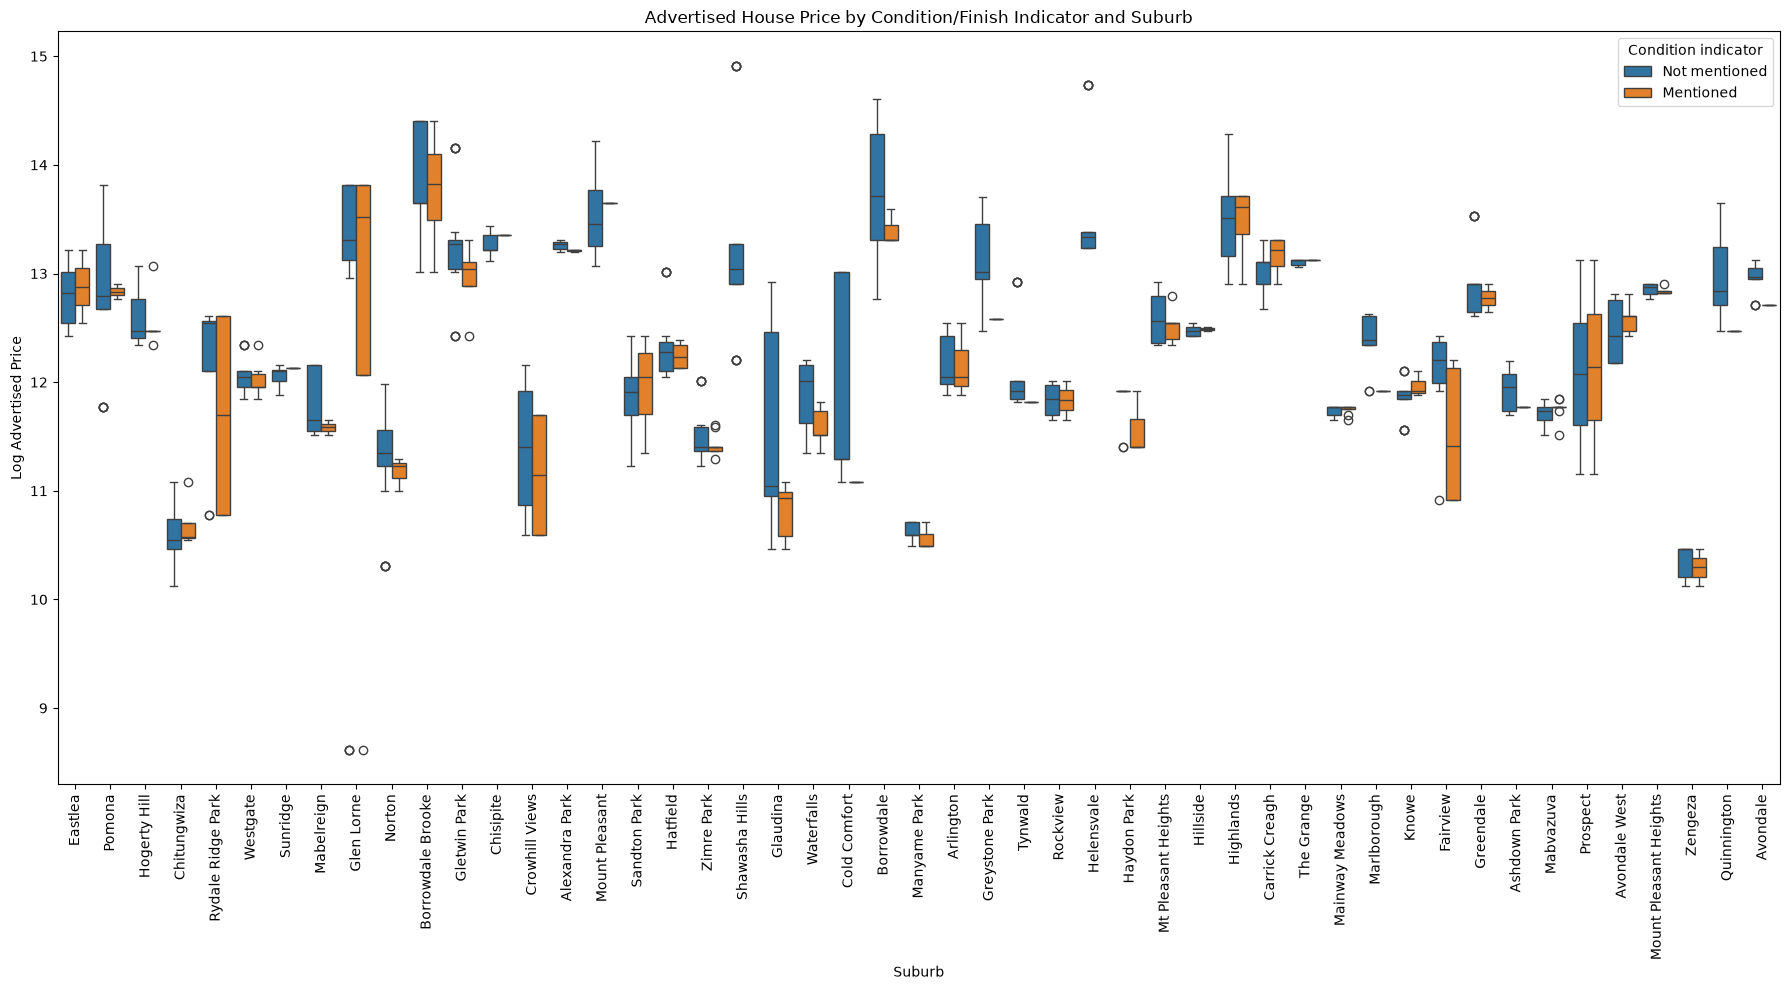

Saved: FIG_condition_price_by_suburb.png


In [46]:
# ============================================================
# STEP 46B — Visualization
# ============================================================

plt.figure(figsize=(18, 10))

sns.boxplot(
    data=condition_plot_df,
    x="suburb",
    y="log_price",
    hue="condition"
)

plt.xticks(rotation=90)

plt.xlabel("Suburb")
plt.ylabel("Log Advertised Price")

plt.title(
    "Advertised House Price by Condition/Finish Indicator and Suburb"
)

plt.legend(
    title="Condition indicator"
)

plt.tight_layout()

plt.savefig(
    "FIG_condition_price_by_suburb.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: FIG_condition_price_by_suburb.png")

In [47]:
# ============================================================
# STEP 47A — Inspect the multimodal modelling dataset
# ============================================================

print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))

print("\nColumns:")
print(model_df.columns.tolist())

print("\nVisual feature availability:")
visual_cols = [
    "visual_paint_score",
    "visual_paving_score",
    "visual_kitchen_score",
    "visual_ceiling_score",
    "visual_floor_score",
    "visual_security_score",
    "visual_solar_score",
    "visual_completion_score"
]

print(
    model_df[visual_cols]
    .notna()
    .sum()
)

print("\nTarget availability:")
print("Price:", model_df["price"].notna().sum())

Rows: 376
Columns: 46

Columns:
['url', 'identifier', 'date_posted', 'price', 'currency', 'agency', 'bedrooms', 'bathrooms', 'floor_size_m2', 'stand_size_m2', 'suburb', 'area', 'description', 'n_images', 'image_urls', 'amenities', 'parsed_image_urls', 'usable_image_count', 'visual_images_attempted', 'visual_images_successful', 'visual_paint_score', 'visual_paving_score', 'visual_kitchen_score', 'visual_ceiling_score', 'visual_floor_score', 'visual_security_score', 'visual_solar_score', 'visual_completion_score', 'paint_flag', 'unpainted_flag', 'paving_flag', 'walling_security_flag', 'ceiling_flag', 'no_ceiling_flag', 'kitchen_fitted_flag', 'kitchen_unfitted_flag', 'borehole_flag', 'water_tank_flag', 'solar_flag', 'ensuite_flag', 'incomplete_flag', 'tiled_floor_flag', 'bare_floor_flag', 'built_in_flag', 'title_deeds_flag', 'cession_flag']

Visual feature availability:
visual_paint_score         150
visual_paving_score        150
visual_kitchen_score       150
visual_ceiling_score       

In [48]:
# ============================================================
# STEP 47B — Missingness in candidate structured features
# ============================================================

structured_candidates = [
    "bedrooms",
    "bathrooms",
    "floor_size_m2",
    "stand_size_m2",
    "suburb",
    "area"
]

missing_summary = pd.DataFrame({
    "missing_count": model_df[structured_candidates].isna().sum(),
    "missing_percentage": (
        model_df[structured_candidates].isna().mean() * 100
    )
})

print(missing_summary)

               missing_count  missing_percentage
bedrooms                   0            0.000000
bathrooms                 42           11.170213
floor_size_m2             39           10.372340
stand_size_m2              9            2.393617
suburb                     0            0.000000
area                       0            0.000000


In [49]:
# ============================================
# SECTION D — STEP 48
# Prepare modelling datasets
# ============================================

import numpy as np
import pandas as pd

# Make a copy
model_df = model_df.copy()

# Visual features
visual_cols = [
    "visual_paint_score",
    "visual_paving_score",
    "visual_kitchen_score",
    "visual_ceiling_score",
    "visual_floor_score",
    "visual_security_score",
    "visual_solar_score",
    "visual_completion_score"
]

# Condition features with useful variation
condition_candidates = [
    "paving_flag",
    "walling_security_flag",
    "ceiling_flag",
    "kitchen_fitted_flag",
    "borehole_flag",
    "water_tank_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "tiled_floor_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

# Keep only condition variables that have at least 5 positive observations
condition_cols = [
    col for col in condition_candidates
    if model_df[col].sum() >= 5
]

print("Condition features retained:")
print(condition_cols)

print("\nPositive counts:")
print(model_df[condition_cols].sum())

# ------------------------------------------------
# Multimodal cohort
# ------------------------------------------------

multimodal_df = model_df[
    model_df[visual_cols].notna().all(axis=1)
].copy()

print("\n============================================")
print("MULTIMODAL COHORT")
print("============================================")
print("Rows:", len(multimodal_df))
print("Unique suburbs:", multimodal_df["suburb"].nunique())
print("Areas:", multimodal_df["area"].nunique())

print("\nArea distribution:")
print(multimodal_df["area"].value_counts())

print("\nSuburb distribution:")
print(multimodal_df["suburb"].value_counts().head(20))

# Check target
print("\nMissing prices:", multimodal_df["price"].isna().sum())

# Log target
multimodal_df["log_price"] = np.log(multimodal_df["price"])

# Save
multimodal_df.to_csv(
    "SECTION_D_multimodal_cohort_150.csv",
    index=False
)

print("\nSaved: SECTION_D_multimodal_cohort_150.csv")

Condition features retained:
['walling_security_flag', 'ceiling_flag', 'kitchen_fitted_flag', 'borehole_flag', 'solar_flag', 'ensuite_flag', 'incomplete_flag', 'built_in_flag', 'title_deeds_flag', 'cession_flag']

Positive counts:
walling_security_flag    70
ceiling_flag              5
kitchen_fitted_flag      32
borehole_flag            12
solar_flag               12
ensuite_flag             59
incomplete_flag          36
built_in_flag            22
title_deeds_flag         24
cession_flag             16
dtype: int64

MULTIMODAL COHORT
Rows: 150
Unique suburbs: 66
Areas: 7

Area distribution:
area
Harare North    62
Harare West     39
Harare South    19
Harare East     11
Ruwa             7
Norton           6
Chitungwiza      6
Name: count, dtype: int64

Suburb distribution:
suburb
Glen Lorne                9
Sandton Park              7
Gletwin Park              5
Zimre Park                5
Pomona                    4
Norton                    4
Alexandra Park            4
Shawasha H

In [50]:
# ============================================
# SECTION D — STEP 49
# Check spatial/suburb coverage
# ============================================

print("Number of listings:", len(multimodal_df))
print("Number of suburbs:", multimodal_df["suburb"].nunique())
print("Number of areas:", multimodal_df["area"].nunique())

coverage = (
    multimodal_df
    .groupby(["area", "suburb"])
    .size()
    .reset_index(name="n_listings")
    .sort_values(["area", "n_listings"], ascending=[True, False])
)

print("\nSuburb coverage:")
display(coverage)

print("\nArea totals:")
print(
    multimodal_df
    .groupby("area")
    .size()
    .sort_values(ascending=False)
)

Number of listings: 150
Number of suburbs: 66
Number of areas: 7

Suburb coverage:


,area,suburb,n_listings
0,Chitungwiza,Chitungwiza,3
1,Chitungwiza,Manyame Park,2
2,Chitungwiza,Zengeza,1
7,Harare East,Zimre Park,5
3,Harare East,Eastlea,2
...,...,...,...
60,Norton,Knowe,2
65,Ruwa,Mabvazuva,4
62,Ruwa,Chipukutu Park,1
63,Ruwa,Erasmus Park,1



Area totals:
area
Harare North    62
Harare West     39
Harare South    19
Harare East     11
Ruwa             7
Chitungwiza      6
Norton           6
dtype: int64


In [51]:
# ============================================
# SECTION D — STEP 50
# Suburb-grouped train/test split
# ============================================

from sklearn.model_selection import GroupShuffleSplit

X = multimodal_df.copy()
y = multimodal_df["log_price"]

groups = multimodal_df["suburb"]

# First split: 80% development, 20% final test
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_dev_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

train_dev = multimodal_df.iloc[train_dev_idx].copy()
test_df = multimodal_df.iloc[test_idx].copy()

print("Development set:", len(train_dev))
print("Test set:", len(test_df))

print("\nDevelopment suburbs:",
      train_dev["suburb"].nunique())

print("Test suburbs:",
      test_df["suburb"].nunique())

print("\nSuburbs appearing in BOTH:")
overlap = set(train_dev["suburb"]) & set(test_df["suburb"])

print(overlap)
print("Number of overlapping suburbs:", len(overlap))

Development set: 118
Test set: 32

Development suburbs: 52
Test suburbs: 14

Suburbs appearing in BOTH:
set()
Number of overlapping suburbs: 0


In [52]:
# ============================================
# SECTION D — STEP 51
# Suburb-grouped validation split
# ============================================

from sklearn.model_selection import GroupShuffleSplit

groups_dev = train_dev["suburb"]

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=123
)

train_idx, val_idx = next(
    gss_val.split(train_dev, train_dev["log_price"], groups=groups_dev)
)

train_df = train_dev.iloc[train_idx].copy()
val_df = train_dev.iloc[val_idx].copy()

print("Training set:", len(train_df))
print("Validation set:", len(val_df))
print("Test set:", len(test_df))

print("\nTraining suburbs:", train_df["suburb"].nunique())
print("Validation suburbs:", val_df["suburb"].nunique())
print("Test suburbs:", test_df["suburb"].nunique())

print("\nTraining/validation suburb overlap:")
print(set(train_df["suburb"]) & set(val_df["suburb"]))

print("\nTraining/test suburb overlap:")
print(set(train_df["suburb"]) & set(test_df["suburb"]))

print("\nValidation/test suburb overlap:")
print(set(val_df["suburb"]) & set(test_df["suburb"]))

Training set: 96
Validation set: 22
Test set: 32

Training suburbs: 41
Validation suburbs: 11
Test suburbs: 14

Training/validation suburb overlap:
set()

Training/test suburb overlap:
set()

Validation/test suburb overlap:
set()


In [53]:
# ============================================
# SECTION D — STEP 52
# Inspect spatial split
# ============================================

for name, df in [
    ("TRAINING", train_df),
    ("VALIDATION", val_df),
    ("TEST", test_df)
]:
    print("\n" + "="*50)
    print(name)
    print("="*50)
    
    print("Rows:", len(df))
    print("Suburbs:", df["suburb"].nunique())
    
    print("\nAreas:")
    print(df["area"].value_counts())
    
    print("\nPrice summary:")
    print(df["price"].describe())


TRAINING
Rows: 96
Suburbs: 41

Areas:
area
Harare North    37
Harare West     28
Harare South    13
Ruwa             6
Harare East      4
Norton           4
Chitungwiza      4
Name: count, dtype: int64

Price summary:
count    9.600000e+01
mean     3.462906e+05
std      4.107318e+05
min      5.500000e+03
25%      1.300000e+05
50%      2.475000e+05
75%      4.362500e+05
max      3.000000e+06
Name: price, dtype: float64

VALIDATION
Rows: 22
Suburbs: 11

Areas:
area
Harare North    12
Harare South     3
Harare West      3
Chitungwiza      2
Harare East      2
Name: count, dtype: int64

Price summary:
count    2.200000e+01
mean     3.995455e+05
std      3.267331e+05
min      4.000000e+04
25%      1.725000e+05
50%      3.400000e+05
75%      5.437500e+05
max      1.400000e+06
Name: price, dtype: float64

TEST
Rows: 32
Suburbs: 14

Areas:
area
Harare North    13
Harare West      8
Harare East      5
Harare South     3
Norton           2
Ruwa             1
Name: count, dtype: int64

Price sum

In [54]:
# ============================================
# SECTION D — STEP 53
# Define multimodal predictors
# ============================================

structured_numeric = [
    "bedrooms",
    "bathrooms",
    "floor_size_m2",
    "stand_size_m2"
]

structured_categorical = [
    "suburb",
    "area"
]

print("Structured numeric:")
print(structured_numeric)

print("\nStructured categorical:")
print(structured_categorical)

print("\nCondition features:")
print(condition_cols)

print("\nVisual features:")
print(visual_cols)

print("\nTotal feature groups:")
print("Numeric:", len(structured_numeric))
print("Categorical:", len(structured_categorical))
print("Condition:", len(condition_cols))
print("Visual:", len(visual_cols))
print("Text:", 1, "(description)")

Structured numeric:
['bedrooms', 'bathrooms', 'floor_size_m2', 'stand_size_m2']

Structured categorical:
['suburb', 'area']

Condition features:
['walling_security_flag', 'ceiling_flag', 'kitchen_fitted_flag', 'borehole_flag', 'solar_flag', 'ensuite_flag', 'incomplete_flag', 'built_in_flag', 'title_deeds_flag', 'cession_flag']

Visual features:
['visual_paint_score', 'visual_paving_score', 'visual_kitchen_score', 'visual_ceiling_score', 'visual_floor_score', 'visual_security_score', 'visual_solar_score', 'visual_completion_score']

Total feature groups:
Numeric: 4
Categorical: 2
Condition: 10
Visual: 8
Text: 1 (description)


In [55]:
# ============================================
# SECTION D — STEP 54
# Actuarial benchmark: OLS log-price
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Structured preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

structured_preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, structured_numeric),
    ("categorical", categorical_transformer, structured_categorical)
])

# Ridge is used to make the structured benchmark stable
# in the presence of many suburb dummy variables.
benchmark_model = Pipeline([
    ("preprocess", structured_preprocessor),
    ("model", Ridge(alpha=1.0))
])

benchmark_model.fit(
    train_df,
    train_df["log_price"]
)

# Predictions
benchmark_pred_log = benchmark_model.predict(val_df)

benchmark_pred = np.exp(benchmark_pred_log)

actual_val = val_df["price"].values

benchmark_rmse = np.sqrt(
    mean_squared_error(actual_val, benchmark_pred)
)

benchmark_mae = mean_absolute_error(
    actual_val,
    benchmark_pred
)

benchmark_mape = mean_absolute_percentage_error(
    actual_val,
    benchmark_pred
) * 100

print("ACTUARIAL BENCHMARK")
print("===================")
print("RMSE:", round(benchmark_rmse, 2))
print("MAE :", round(benchmark_mae, 2))
print("MAPE:", round(benchmark_mape, 2), "%")

ACTUARIAL BENCHMARK
RMSE: 999765.45
MAE : 410762.8
MAPE: 110.86 %


In [56]:
# ============================================
# SECTION D — STEP 55
# Benchmark log-scale diagnostics
# ============================================

actual_log = val_df["log_price"].values

benchmark_rmse_log = np.sqrt(
    mean_squared_error(actual_log, benchmark_pred_log)
)

benchmark_mae_log = mean_absolute_error(
    actual_log,
    benchmark_pred_log
)

benchmark_r2_log = benchmark_model.score(
    val_df,
    val_df["log_price"]
)

print("ACTUARIAL BENCHMARK — LOG SCALE")
print("================================")
print("RMSE (log price):", round(benchmark_rmse_log, 4))
print("MAE  (log price):", round(benchmark_mae_log, 4))
print("R²   (log price):", round(benchmark_r2_log, 4))

ACTUARIAL BENCHMARK — LOG SCALE
RMSE (log price): 0.8188
MAE  (log price): 0.5905
R²   (log price): 0.3702


In [57]:
# ============================================
# SECTION D — STEP 56
# Benchmark prediction diagnostics
# ============================================

benchmark_results = val_df[
    ["identifier", "suburb", "area", "price"]
].copy()

benchmark_results["predicted_price"] = benchmark_pred
benchmark_results["absolute_error"] = (
    benchmark_results["price"] -
    benchmark_results["predicted_price"]
).abs()

benchmark_results["percentage_error"] = (
    benchmark_results["absolute_error"] /
    benchmark_results["price"]
) * 100

benchmark_results = benchmark_results.sort_values(
    "absolute_error",
    ascending=False
)

display(
    benchmark_results.head(10)
)

,identifier,suburb,area,price,predicted_price,absolute_error,percentage_error
75,RVT240457,Highlands,Harare North,650000.0,4.493338e+06,3.843338e+06,591.282719
364,SMTP247718,Highlands,Harare North,900000.0,3.472600e+06,2.572600e+06,285.844417
44,PRCL238959,Gletwin Park,Harare North,1400000.0,9.192397e+05,4.807603e+05,34.340019
292,RWS246172,Crowhill Views,Harare North,40000.0,2.882569e+05,2.482569e+05,620.642206
158,LCRE242835,New Alexandra Park,Harare North,525000.0,2.779000e+05,2.471000e+05,47.066667
281,PGP245797,New Alexandra Park,Harare North,550000.0,3.280476e+05,2.219524e+05,40.354989
145,PGP242543,Greengrove,Harare East,500000.0,2.801650e+05,2.198350e+05,43.967008
370,Title deed,Gletwin Park,Harare North,650000.0,4.308557e+05,2.191443e+05,33.714513
279,DING245765,Highlands,Harare North,400000.0,2.470609e+05,1.529391e+05,38.234763
114,LEG241639,Crowhill Views,Harare North,40000.0,1.911173e+05,1.511173e+05,377.793219


In [58]:
# ============================================
# SECTION D — STEP 57
# Multimodal feature preparation
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# --------------------------------------------
# Numeric features
# --------------------------------------------

num_imputer = SimpleImputer(strategy="median")

X_train_num = num_imputer.fit_transform(
    train_df[structured_numeric]
)

X_val_num = num_imputer.transform(
    val_df[structured_numeric]
)

X_test_num = num_imputer.transform(
    test_df[structured_numeric]
)

# --------------------------------------------
# Condition features
# --------------------------------------------

X_train_condition = train_df[condition_cols].fillna(0).values
X_val_condition = val_df[condition_cols].fillna(0).values
X_test_condition = test_df[condition_cols].fillna(0).values

# --------------------------------------------
# Visual features
# --------------------------------------------

X_train_visual = train_df[visual_cols].values
X_val_visual = val_df[visual_cols].values
X_test_visual = test_df[visual_cols].values

# --------------------------------------------
# Location
# --------------------------------------------

location_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_location = location_encoder.fit_transform(
    train_df[structured_categorical]
)

X_val_location = location_encoder.transform(
    val_df[structured_categorical]
)

X_test_location = location_encoder.transform(
    test_df[structured_categorical]
)

# --------------------------------------------
# Text: TF-IDF
# --------------------------------------------

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=3000
)

X_train_text_sparse = tfidf.fit_transform(
    train_df["description"].fillna("")
)

X_val_text_sparse = tfidf.transform(
    val_df["description"].fillna("")
)

X_test_text_sparse = tfidf.transform(
    test_df["description"].fillna("")
)

print("TF-IDF vocabulary:", len(tfidf.get_feature_names_out()))

# --------------------------------------------
# Reduce text dimensionality
# --------------------------------------------

n_components = min(
    30,
    X_train_text_sparse.shape[1] - 1
)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

X_train_text = svd.fit_transform(X_train_text_sparse)
X_val_text = svd.transform(X_val_text_sparse)
X_test_text = svd.transform(X_test_text_sparse)

print("Text components:", n_components)
print(
    "Variance explained:",
    round(svd.explained_variance_ratio_.sum(), 4)
)

# --------------------------------------------
# Combine ALL modalities
# --------------------------------------------

X_train_multi = np.hstack([
    X_train_num,
    X_train_location,
    X_train_condition,
    X_train_visual,
    X_train_text
])

X_val_multi = np.hstack([
    X_val_num,
    X_val_location,
    X_val_condition,
    X_val_visual,
    X_val_text
])

X_test_multi = np.hstack([
    X_test_num,
    X_test_location,
    X_test_condition,
    X_test_visual,
    X_test_text
])

print("\nMultimodal matrix shapes:")
print("Training :", X_train_multi.shape)
print("Validation:", X_val_multi.shape)
print("Test     :", X_test_multi.shape)

TF-IDF vocabulary: 357
Text components: 30
Variance explained: 0.5671

Multimodal matrix shapes:
Training : (96, 100)
Validation: (22, 100)
Test     : (32, 100)


In [59]:
# ============================================
# SECTION D — STEP 58
# Scale multimodal features
# ============================================

from sklearn.preprocessing import StandardScaler

multi_scaler = StandardScaler()

X_train_multi_scaled = multi_scaler.fit_transform(
    X_train_multi
)

X_val_multi_scaled = multi_scaler.transform(
    X_val_multi
)

X_test_multi_scaled = multi_scaler.transform(
    X_test_multi
)

print("Scaled training matrix:", X_train_multi_scaled.shape)

Scaled training matrix: (96, 100)


In [60]:
# ============================================
# SECTION D — STEP 59
# Three materially different ML models
# ============================================

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

# --------------------------------------------
# Model 1: Elastic Net
# --------------------------------------------

elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=42
)

elastic_model.fit(
    X_train_multi_scaled,
    train_df["log_price"]
)

# --------------------------------------------
# Model 2: Random Forest
# --------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_multi,
    train_df["log_price"]
)

# --------------------------------------------
# Model 3: Gradient Boosting
# --------------------------------------------

gb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

gb_model.fit(
    X_train_multi,
    train_df["log_price"]
)

print("All three models trained successfully.")

All three models trained successfully.


In [61]:
# ============================================
# SECTION D — STEP 60
# Evaluate multimodal models
# ============================================

def evaluate_model(name, model, X_eval, df_eval):
    
    pred_log = model.predict(X_eval)
    pred_price = np.exp(pred_log)
    
    actual_price = df_eval["price"].values
    actual_log = df_eval["log_price"].values
    
    return {
        "Model": name,
        "RMSE_original": np.sqrt(
            mean_squared_error(
                actual_price,
                pred_price
            )
        ),
        "MAE_original": mean_absolute_error(
            actual_price,
            pred_price
        ),
        "MAPE_percent": mean_absolute_percentage_error(
            actual_price,
            pred_price
        ) * 100,
        "RMSE_log": np.sqrt(
            mean_squared_error(
                actual_log,
                pred_log
            )
        ),
        "MAE_log": mean_absolute_error(
            actual_log,
            pred_log
        ),
        "R2_log": model.score(
            X_eval,
            actual_log
        )
    }


results = []

results.append(
    evaluate_model(
        "Elastic Net",
        elastic_model,
        X_val_multi_scaled,
        val_df
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_val_multi,
        val_df
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        gb_model,
        X_val_multi,
        val_df
    )
)

results_df = pd.DataFrame(results)

display(
    results_df.round(4)
)

results_df.to_csv(
    "SECTION_D_initial_model_comparison.csv",
    index=False
)

,Model,RMSE_original,MAE_original,MAPE_percent,RMSE_log,MAE_log,R2_log
0,Elastic Net,789770.8267,350551.2669,109.9784,0.8600,0.6449,0.3051
1,Random Forest,276860.7094,161301.5759,74.9894,0.7268,0.5113,0.5038
2,Gradient Boosting,263144.3567,178782.3519,81.3717,0.6724,0.4848,0.5752


In [62]:
# ============================================
# SECTION D — STEP 61
# Nested hyperparameter tuning
# ============================================

from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.base import clone

# --------------------------------------------
# Inner spatial CV
# --------------------------------------------

inner_cv = GroupKFold(n_splits=5)

groups_train = train_df["suburb"]

# --------------------------------------------
# Model 1: Elastic Net
# --------------------------------------------

elastic_base = ElasticNet(
    max_iter=20000,
    random_state=42
)

elastic_grid = {
    "alpha": [0.001, 0.01, 0.05, 0.1, 0.5],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_search = GridSearchCV(
    estimator=elastic_base,
    param_grid=elastic_grid,
    scoring="neg_root_mean_squared_error",
    cv=inner_cv,
    n_jobs=-1
)

elastic_search.fit(
    X_train_multi_scaled,
    train_df["log_price"],
    groups=groups_train
)

print("ELASTIC NET")
print("Best parameters:", elastic_search.best_params_)
print(
    "Best CV RMSE:",
    round(-elastic_search.best_score_, 4)
)

# --------------------------------------------
# Model 2: Random Forest
# --------------------------------------------

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7]
}

rf_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_grid,
    scoring="neg_root_mean_squared_error",
    cv=inner_cv,
    n_jobs=-1
)

rf_search.fit(
    X_train_multi,
    train_df["log_price"],
    groups=groups_train
)

print("\nRANDOM FOREST")
print("Best parameters:", rf_search.best_params_)
print(
    "Best CV RMSE:",
    round(-rf_search.best_score_, 4)
)

# --------------------------------------------
# Model 3: Gradient Boosting
# --------------------------------------------

gb_base = HistGradientBoostingRegressor(
    random_state=42
)

gb_grid = {
    "learning_rate": [0.03, 0.05, 0.10],
    "max_iter": [100, 200, 300],
    "max_leaf_nodes": [7, 15, 31],
    "min_samples_leaf": [5, 10, 15],
    "l2_regularization": [0.0, 1.0, 5.0]
}

gb_search = GridSearchCV(
    estimator=gb_base,
    param_grid=gb_grid,
    scoring="neg_root_mean_squared_error",
    cv=inner_cv,
    n_jobs=-1
)

gb_search.fit(
    X_train_multi,
    train_df["log_price"],
    groups=groups_train
)

print("\nGRADIENT BOOSTING")
print("Best parameters:", gb_search.best_params_)
print(
    "Best CV RMSE:",
    round(-gb_search.best_score_, 4)
)

ELASTIC NET
Best parameters: {'alpha': 0.1, 'l1_ratio': 0.9}
Best CV RMSE: 0.7158

RANDOM FOREST
Best parameters: {'max_depth': 5, 'max_features': 0.7, 'min_samples_leaf': 1, 'n_estimators': 500}
Best CV RMSE: 0.6406

GRADIENT BOOSTING
Best parameters: {'l2_regularization': 0.0, 'learning_rate': 0.05, 'max_iter': 100, 'max_leaf_nodes': 15, 'min_samples_leaf': 5}
Best CV RMSE: 0.6254


In [66]:
# ============================================
# SECTION D — STEP 62
# Evaluate tuned models on validation set
# ============================================

tuned_models = {
    "Elastic Net": (
        elastic_search.best_estimator_,
        X_val_multi_scaled
    ),
    "Random Forest": (
        rf_search.best_estimator_,
        X_val_multi
    ),
    "Gradient Boosting": (
        gb_search.best_estimator_,
        X_val_multi
    )
}

tuned_results = []

for name, (model, X_eval) in tuned_models.items():
    
    pred_log = model.predict(X_eval)
    pred_price = np.exp(pred_log)
    
    actual_price = val_df["price"].values
    actual_log = val_df["log_price"].values
    
    tuned_results.append({
        "Model": name,
        "RMSE_original": np.sqrt(
            mean_squared_error(
                actual_price,
                pred_price
            )
        ),
        "MAE_original": mean_absolute_error(
            actual_price,
            pred_price
        ),
        "MAPE_percent": (
            mean_absolute_percentage_error(
                actual_price,
                pred_price
            ) * 100
        ),
        "RMSE_log": np.sqrt(
            mean_squared_error(
                actual_log,
                pred_log
            )
        ),
        "MAE_log": mean_absolute_error(
            actual_log,
            pred_log
        ),
        "R2_log": model.score(
            X_eval,
            actual_log
        )
    })

tuned_results_df = pd.DataFrame(tuned_results)

display(
    tuned_results_df.round(4)
)

tuned_results_df.to_csv(
    "SECTION_D_tuned_validation_results.csv",
    index=False
)

,Model,RMSE_original,MAE_original,MAPE_percent,RMSE_log,MAE_log,R2_log
0,Elastic Net,235017.7123,165359.5259,74.2887,0.6740,0.4859,0.5732
1,Random Forest,214679.6933,128540.0153,80.4339,0.7080,0.4643,0.5290
2,Gradient Boosting,238309.5934,160779.4449,96.6491,0.7716,0.5255,0.4407


In [67]:
# ============================================
# SECTION D — STEP 63
# Final validation comparison
# ============================================

benchmark_row = pd.DataFrame([{
    "Model": "Actuarial Benchmark",
    "RMSE_original": benchmark_rmse,
    "MAE_original": benchmark_mae,
    "MAPE_percent": benchmark_mape,
    "RMSE_log": benchmark_rmse_log,
    "MAE_log": benchmark_mae_log,
    "R2_log": benchmark_r2_log
}])

final_validation_comparison = pd.concat(
    [
        benchmark_row,
        tuned_results_df
    ],
    ignore_index=True
)

display(
    final_validation_comparison.round(4)
)

final_validation_comparison.to_csv(
    "SECTION_D_FINAL_VALIDATION_COMPARISON.csv",
    index=False
)

,Model,RMSE_original,MAE_original,MAPE_percent,RMSE_log,MAE_log,R2_log
0,Actuarial Benchmark,999765.4520,410762.7956,110.8578,0.8188,0.5905,0.3702
1,Elastic Net,235017.7123,165359.5259,74.2887,0.6740,0.4859,0.5732
2,Random Forest,214679.6933,128540.0153,80.4339,0.7080,0.4643,0.5290
3,Gradient Boosting,238309.5934,160779.4449,96.6491,0.7716,0.5255,0.4407


In [68]:
# ============================================
# SECTION D — STEP 64A
# Split conformal prediction intervals
# ============================================

def conformal_calibration(model, X_cal, calibration_df, alpha=0.10):
    """
    Calibrate absolute residuals on the log-price scale.
    alpha=0.10 gives a nominal 90% prediction interval.
    """
    
    calibration_pred_log = model.predict(X_cal)
    
    calibration_actual_log = (
        calibration_df["log_price"].values
    )
    
    residuals = np.abs(
        calibration_actual_log -
        calibration_pred_log
    )
    
    n = len(residuals)
    
    # Finite-sample conformal quantile
    quantile_level = np.ceil(
        (n + 1) * (1 - alpha)
    ) / n
    
    quantile_level = min(quantile_level, 1.0)
    
    q = np.quantile(
        residuals,
        quantile_level,
        method="higher"
    )
    
    return q, residuals


# Calibrate each tuned model
conformal_results = {}

q_elastic, resid_elastic = conformal_calibration(
    elastic_search.best_estimator_,
    X_val_multi_scaled,
    val_df
)

q_rf, resid_rf = conformal_calibration(
    rf_search.best_estimator_,
    X_val_multi,
    val_df
)

q_gb, resid_gb = conformal_calibration(
    gb_search.best_estimator_,
    X_val_multi,
    val_df
)

conformal_results["Elastic Net"] = q_elastic
conformal_results["Random Forest"] = q_rf
conformal_results["Gradient Boosting"] = q_gb

print("90% conformal log-scale half-widths")
print("====================================")

for name, q in conformal_results.items():
    print(
        f"{name}: {q:.4f}"
    )

90% conformal log-scale half-widths
Elastic Net: 1.8895
Random Forest: 1.8892
Gradient Boosting: 1.9723


In [69]:
# ============================================
# SECTION D — STEP 64B
# Evaluate conformal intervals
# ============================================

def evaluate_conformal_model(
    name,
    model,
    X_test,
    test_df,
    q
):
    
    pred_log = model.predict(X_test)
    
    lower_log = pred_log - q
    upper_log = pred_log + q
    
    pred_price = np.exp(pred_log)
    lower_price = np.exp(lower_log)
    upper_price = np.exp(upper_log)
    
    actual_price = test_df["price"].values
    actual_log = test_df["log_price"].values
    
    covered = (
        (actual_price >= lower_price) &
        (actual_price <= upper_price)
    )
    
    interval_width = upper_price - lower_price
    
    return {
        "Model": name,
        "RMSE": np.sqrt(
            mean_squared_error(
                actual_price,
                pred_price
            )
        ),
        "MAE": mean_absolute_error(
            actual_price,
            pred_price
        ),
        "MAPE_percent":
            mean_absolute_percentage_error(
                actual_price,
                pred_price
            ) * 100,
        "RMSE_log": np.sqrt(
            mean_squared_error(
                actual_log,
                pred_log
            )
        ),
        "R2_log": model.score(
            X_test,
            actual_log
        ),
        "Interval_coverage":
            covered.mean() * 100,
        "Mean_interval_width":
            interval_width.mean(),
        "Median_interval_width":
            np.median(interval_width)
    }


test_interval_results = []

test_interval_results.append(
    evaluate_conformal_model(
        "Elastic Net",
        elastic_search.best_estimator_,
        X_test_multi_scaled,
        test_df,
        q_elastic
    )
)

test_interval_results.append(
    evaluate_conformal_model(
        "Random Forest",
        rf_search.best_estimator_,
        X_test_multi,
        test_df,
        q_rf
    )
)

test_interval_results.append(
    evaluate_conformal_model(
        "Gradient Boosting",
        gb_search.best_estimator_,
        X_test_multi,
        test_df,
        q_gb
    )
)

test_interval_results_df = pd.DataFrame(
    test_interval_results
)

display(
    test_interval_results_df.round(4)
)

test_interval_results_df.to_csv(
    "SECTION_D_FINAL_TEST_WITH_CONFORMAL_INTERVALS.csv",
    index=False
)

,Model,RMSE,MAE,MAPE_percent,RMSE_log,R2_log,Interval_coverage,Mean_interval_width,Median_interval_width
0,Elastic Net,295943.2390,169194.2042,60.2843,0.6328,0.6103,96.875,1.692307e+06,1.105307e+06
1,Random Forest,285688.6796,160092.4410,63.0775,0.6123,0.6350,96.875,1.821347e+06,1.506082e+06
2,Gradient Boosting,295851.6374,161038.4397,73.4331,0.6800,0.5500,96.875,2.130300e+06,1.705642e+06


In [70]:
# ============================================
# SECTION D — STEP 64B
# Evaluate conformal intervals
# ============================================

def evaluate_conformal_model(
    name,
    model,
    X_test,
    test_df,
    q
):
    
    pred_log = model.predict(X_test)
    
    lower_log = pred_log - q
    upper_log = pred_log + q
    
    pred_price = np.exp(pred_log)
    lower_price = np.exp(lower_log)
    upper_price = np.exp(upper_log)
    
    actual_price = test_df["price"].values
    actual_log = test_df["log_price"].values
    
    covered = (
        (actual_price >= lower_price) &
        (actual_price <= upper_price)
    )
    
    interval_width = upper_price - lower_price
    
    return {
        "Model": name,
        "RMSE": np.sqrt(
            mean_squared_error(
                actual_price,
                pred_price
            )
        ),
        "MAE": mean_absolute_error(
            actual_price,
            pred_price
        ),
        "MAPE_percent":
            mean_absolute_percentage_error(
                actual_price,
                pred_price
            ) * 100,
        "RMSE_log": np.sqrt(
            mean_squared_error(
                actual_log,
                pred_log
            )
        ),
        "R2_log": model.score(
            X_test,
            actual_log
        ),
        "Interval_coverage":
            covered.mean() * 100,
        "Mean_interval_width":
            interval_width.mean(),
        "Median_interval_width":
            np.median(interval_width)
    }


test_interval_results = []

test_interval_results.append(
    evaluate_conformal_model(
        "Elastic Net",
        elastic_search.best_estimator_,
        X_test_multi_scaled,
        test_df,
        q_elastic
    )
)

test_interval_results.append(
    evaluate_conformal_model(
        "Random Forest",
        rf_search.best_estimator_,
        X_test_multi,
        test_df,
        q_rf
    )
)

test_interval_results.append(
    evaluate_conformal_model(
        "Gradient Boosting",
        gb_search.best_estimator_,
        X_test_multi,
        test_df,
        q_gb
    )
)

test_interval_results_df = pd.DataFrame(
    test_interval_results
)

display(
    test_interval_results_df.round(4)
)

test_interval_results_df.to_csv(
    "SECTION_D_FINAL_TEST_WITH_CONFORMAL_INTERVALS.csv",
    index=False
)

,Model,RMSE,MAE,MAPE_percent,RMSE_log,R2_log,Interval_coverage,Mean_interval_width,Median_interval_width
0,Elastic Net,295943.2390,169194.2042,60.2843,0.6328,0.6103,96.875,1.692307e+06,1.105307e+06
1,Random Forest,285688.6796,160092.4410,63.0775,0.6123,0.6350,96.875,1.821347e+06,1.506082e+06
2,Gradient Boosting,295851.6374,161038.4397,73.4331,0.6800,0.5500,96.875,2.130300e+06,1.705642e+06


In [71]:
# ============================================
# SECTION D — STEP 65
# Property-level test predictions
# ============================================

test_predictions = test_df[
    [
        "identifier",
        "suburb",
        "area",
        "price",
        "bedrooms",
        "bathrooms",
        "floor_size_m2",
        "stand_size_m2"
    ]
].copy()

# Elastic Net
test_predictions["ElasticNet_pred"] = np.exp(
    elastic_search.best_estimator_.predict(
        X_test_multi_scaled
    )
)

# Random Forest
test_predictions["RandomForest_pred"] = np.exp(
    rf_search.best_estimator_.predict(
        X_test_multi
    )
)

# Gradient Boosting
test_predictions["GradientBoosting_pred"] = np.exp(
    gb_search.best_estimator_.predict(
        X_test_multi
    )
)

# Absolute errors for Random Forest
test_predictions["RF_abs_error"] = (
    test_predictions["price"] -
    test_predictions["RandomForest_pred"]
).abs()

test_predictions = test_predictions.sort_values(
    "RF_abs_error",
    ascending=False
)

display(
    test_predictions
)

test_predictions.to_csv(
    "SECTION_D_test_property_predictions.csv",
    index=False
)

,identifier,suburb,area,price,bedrooms,bathrooms,floor_size_m2,stand_size_m2,ElasticNet_pred,RandomForest_pred,GradientBoosting_pred,RF_abs_error
357,KNP247672,Borrowdale Brooke,Harare North,1800000.0,5,5.0,550.0,4037.0,511369.955279,539494.990424,443264.975901,1.260505e+06
68,PRCL240218,Borrowdale Brooke,Harare North,1200000.0,7,7.0,600.0,5600.0,745266.141376,662058.294847,935361.177479,5.379417e+05
341,PGP247433,Borrowdale Brooke,Harare North,850000.0,4,3.0,500.0,1100.0,296859.393419,347655.281095,338890.786502,5.023447e+05
37,VENT238528,Mount Pleasant,Harare North,850000.0,6,4.0,4093.0,NaN,918194.588740,477983.269398,384513.442658,3.720167e+05
293,RWS246209,Newlands,Harare North,800000.0,4,4.0,1000.0,4047.0,499804.144670,544469.132414,605488.789035,2.555309e+05
175,SEF243296,Charlotte Brooke,Harare North,28000.0,3,2.0,300.0,1000.0,240627.958790,246574.300756,315156.322650,2.185743e+05
354,ALX247629,Cold Comfort,Harare West,450000.0,6,4.0,500.0,NaN,209670.672118,239508.267013,207856.805085,2.104917e+05
198,RWS243932,Rolf Valley,Harare North,700000.0,6,5.0,300.0,2546.0,406104.925363,523231.564569,684966.977592,1.767684e+05
249,RRT245146,Belvedere,Harare West,320000.0,5,2.0,NaN,848.0,144255.654905,159869.720671,148943.395249,1.601303e+05
17,PGP237799,Alexandra Park,Harare North,580000.0,4,2.0,300.0,2644.0,295902.620585,430499.013508,352392.377443,1.495010e+05


In [72]:
# ============================================
# SECTION E — STEP 66
# Final Random Forest residual diagnostics
# ============================================

rf_test_pred_log = rf_search.best_estimator_.predict(
    X_test_multi
)

rf_test_pred = np.exp(rf_test_pred_log)

residual_df = test_df[
    [
        "identifier",
        "suburb",
        "area",
        "price",
        "bedrooms",
        "bathrooms",
        "floor_size_m2",
        "stand_size_m2"
    ]
].copy()

residual_df["predicted_price"] = rf_test_pred

residual_df["residual"] = (
    residual_df["price"] -
    residual_df["predicted_price"]
)

residual_df["absolute_error"] = (
    residual_df["residual"].abs()
)

residual_df["percentage_error"] = (
    residual_df["absolute_error"] /
    residual_df["price"]
) * 100

residual_df["log_actual"] = test_df["log_price"].values
residual_df["log_predicted"] = rf_test_pred_log

residual_df["log_residual"] = (
    residual_df["log_actual"] -
    residual_df["log_predicted"]
)

display(
    residual_df.sort_values(
        "absolute_error",
        ascending=False
    )
)

residual_df.to_csv(
    "SECTION_E_RF_residuals.csv",
    index=False
)

,identifier,suburb,area,price,bedrooms,bathrooms,floor_size_m2,stand_size_m2,predicted_price,residual,absolute_error,percentage_error,log_actual,log_predicted,log_residual
357,KNP247672,Borrowdale Brooke,Harare North,1800000.0,5,5.0,550.0,4037.0,539494.990424,1.260505e+06,1.260505e+06,70.028056,14.403297,13.198389,1.204908
68,PRCL240218,Borrowdale Brooke,Harare North,1200000.0,7,7.0,600.0,5600.0,662058.294847,5.379417e+05,5.379417e+05,44.828475,13.997832,13.403109,0.594723
341,PGP247433,Borrowdale Brooke,Harare North,850000.0,4,3.0,500.0,1100.0,347655.281095,5.023447e+05,5.023447e+05,59.099379,13.652992,12.758967,0.894025
37,VENT238528,Mount Pleasant,Harare North,850000.0,6,4.0,4093.0,NaN,477983.269398,3.720167e+05,3.720167e+05,43.766674,13.652992,13.077331,0.575661
293,RWS246209,Newlands,Harare North,800000.0,4,4.0,1000.0,4047.0,544469.132414,2.555309e+05,2.555309e+05,31.941358,13.592367,13.207567,0.384800
175,SEF243296,Charlotte Brooke,Harare North,28000.0,3,2.0,300.0,1000.0,246574.300756,-2.185743e+05,2.185743e+05,780.622503,10.239960,12.415419,-2.175459
354,ALX247629,Cold Comfort,Harare West,450000.0,6,4.0,500.0,NaN,239508.267013,2.104917e+05,2.104917e+05,46.775941,13.017003,12.386343,0.630660
198,RWS243932,Rolf Valley,Harare North,700000.0,6,5.0,300.0,2546.0,523231.564569,1.767684e+05,1.767684e+05,25.252634,13.458836,13.167779,0.291056
249,RRT245146,Belvedere,Harare West,320000.0,5,2.0,NaN,848.0,159869.720671,1.601303e+05,1.601303e+05,50.040712,12.676076,11.982115,0.693962
17,PGP237799,Alexandra Park,Harare North,580000.0,4,2.0,300.0,2644.0,430499.013508,1.495010e+05,1.495010e+05,25.776032,13.270783,12.972700,0.298083


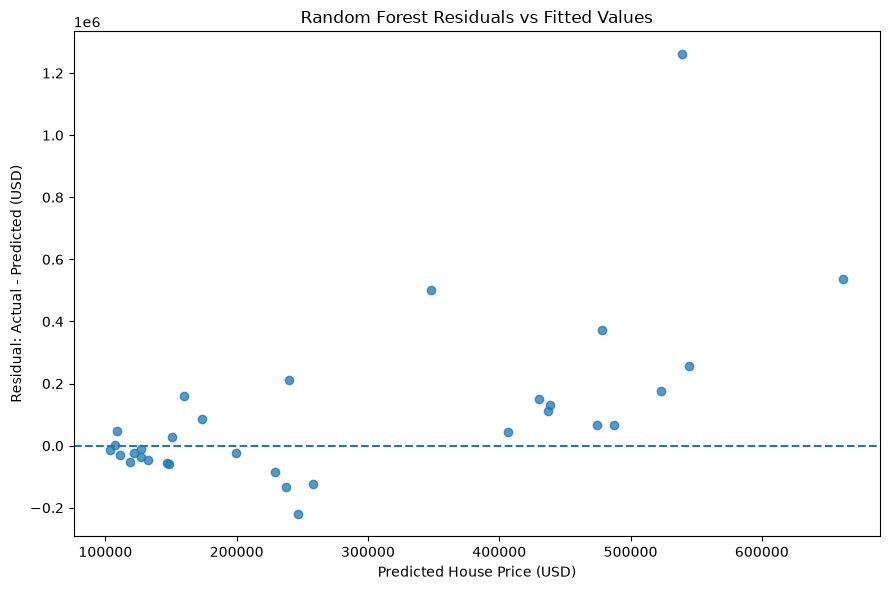

In [73]:
# ============================================
# SECTION E — STEP 67
# Residuals vs fitted values
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    residual_df["predicted_price"],
    residual_df["residual"],
    alpha=0.75
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted House Price (USD)")
plt.ylabel("Residual: Actual - Predicted (USD)")
plt.title(
    "Random Forest Residuals vs Fitted Values"
)

plt.tight_layout()

plt.savefig(
    "FIG_RF_residuals_vs_fitted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

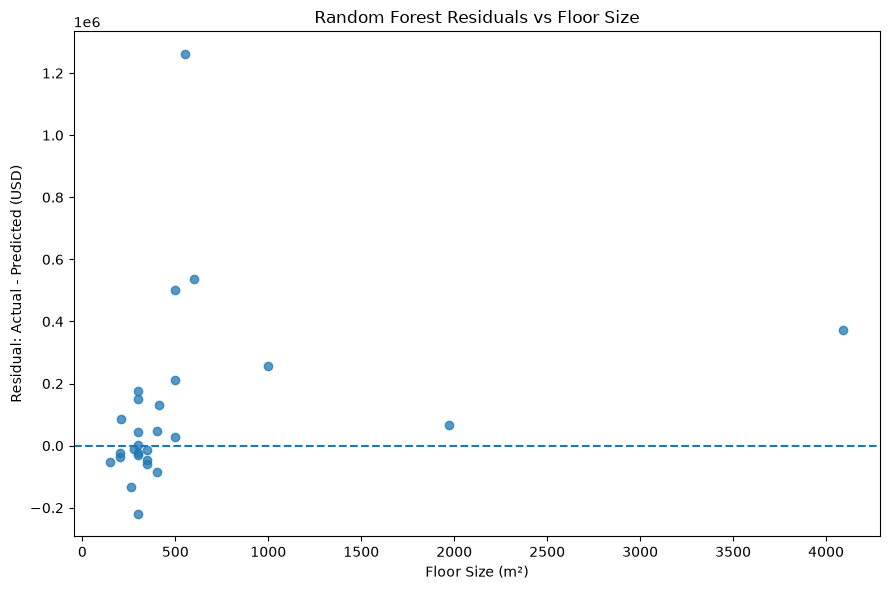

In [74]:
# ============================================
# SECTION E — STEP 68
# Residuals vs floor size
# ============================================

plt.figure(figsize=(9, 6))

plt.scatter(
    residual_df["floor_size_m2"],
    residual_df["residual"],
    alpha=0.75
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Floor Size (m²)")
plt.ylabel("Residual: Actual - Predicted (USD)")
plt.title(
    "Random Forest Residuals vs Floor Size"
)

plt.tight_layout()

plt.savefig(
    "FIG_RF_residuals_vs_floor_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
# ============================================
# SECTION E — STEP 69
# Residual summary by suburb
# ============================================

suburb_residuals = (
    residual_df
    .groupby("suburb")
    .agg(
        n=("residual", "size"),
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        mean_absolute_error=("absolute_error", "mean"),
        mean_percentage_error=("percentage_error", "mean")
    )
    .reset_index()
    .sort_values(
        "mean_residual",
        ascending=False
    )
)

display(suburb_residuals)

suburb_residuals.to_csv(
    "SECTION_E_residuals_by_suburb.csv",
    index=False
)

,suburb,n,mean_residual,median_residual,mean_absolute_error,mean_percentage_error
2,Borrowdale Brooke,4,585991.630384,520143.212029,585991.630384,45.887594
9,Newlands,1,255530.867586,255530.867586,255530.867586,31.941358
8,Mount Pleasant,2,251688.558846,251688.558846,251688.558846,33.406178
10,Rolf Valley,1,176768.435431,176768.435431,176768.435431,25.252634
1,Belvedere,2,123406.248173,123406.248173,123406.248173,41.690013
0,Alexandra Park,4,98714.466203,90058.999402,98714.466203,17.623907
5,Cold Comfort,3,41913.361893,-30859.196343,98414.460098,56.087133
12,Westgate,2,37492.875002,37492.875002,37492.875002,22.880709
4,Chipukutu Park,1,-11989.604306,-11989.604306,11989.604306,10.425743
13,Zimre Park,5,-34532.268532,-46863.070563,35614.130105,39.946350


In [76]:
# ============================================
# SECTION E — STEP 70
# Residual summary by area
# ============================================

area_residuals = (
    residual_df
    .groupby("area")
    .agg(
        n=("residual", "size"),
        mean_residual=("residual", "mean"),
        median_residual=("residual", "median"),
        MAE=("absolute_error", "mean"),
        mean_percentage_error=("percentage_error", "mean")
    )
    .reset_index()
)

display(area_residuals)

area_residuals.to_csv(
    "SECTION_E_residuals_by_area.csv",
    index=False
)

,area,n,mean_residual,median_residual,MAE,mean_percentage_error
0,Harare East,5,-34532.268532,-46863.070563,35614.130105,39.946350
1,Harare North,13,265840.500485,149500.986492,299467.315986,89.128835
2,Harare South,3,-56516.120582,-24452.283957,56516.120582,42.399357
3,Harare West,8,51296.090311,37492.875002,81776.404524,42.337801
4,Norton,2,-108031.576138,-108031.576138,108031.576138,91.874029
5,Ruwa,1,-11989.604306,-11989.604306,11989.604306,10.425743


In [77]:
# ============================================
# SECTION E — STEP 71
# Error concentration by price level
# ============================================

residual_df["price_band"] = pd.cut(
    residual_df["price"],
    bins=[
        0,
        100000,
        250000,
        500000,
        1000000,
        np.inf
    ],
    labels=[
        "<$100k",
        "$100k-$250k",
        "$250k-$500k",
        "$500k-$1m",
        ">$1m"
    ]
)

error_by_band = (
    residual_df
    .groupby("price_band", observed=False)
    .agg(
        n=("residual", "size"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
        MAPE=("percentage_error", "mean")
    )
    .reset_index()
)

display(error_by_band)

error_by_band.to_csv(
    "SECTION_E_error_by_price_band.csv",
    index=False
)

,price_band,n,MAE,mean_residual,MAPE
0,<$100k,9,59780.848615,-59780.848615,129.205176
1,$100k-$250k,8,56640.679866,-37218.078882,43.428248
2,$250k-$500k,4,125119.829309,125119.829309,34.937608
3,$500k-$1m,9,203653.222714,203653.222714,28.177928
4,>$1m,2,899223.357364,899223.357364,57.428266


In [83]:
# ============================================================
# SECTION D/E — CLEAN RECONSTRUCTION START
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load the saved 150-property multimodal dataset
# ------------------------------------------------------------

multimodal_df = pd.read_csv(
    "SECTION_D_multimodal_cohort_150.csv"
)

# Reset index completely
multimodal_df = multimodal_df.reset_index(drop=True)

print("Dataset loaded successfully.")
print("Rows:", len(multimodal_df))
print("Columns:", len(multimodal_df.columns))

# ------------------------------------------------------------
# 2. Basic checks
# ------------------------------------------------------------

print("\nRequired columns:")

required_columns = [
    "identifier",
    "price",
    "suburb",
    "area",
    "bedrooms",
    "bathrooms",
    "floor_size_m2",
    "stand_size_m2"
]

for col in required_columns:
    print(
        f"{col}:",
        "YES" if col in multimodal_df.columns else "MISSING"
    )

# ------------------------------------------------------------
# 3. Create log-price
# ------------------------------------------------------------

multimodal_df["log_price"] = np.log(
    multimodal_df["price"]
)

# ------------------------------------------------------------
# 4. Display cohort
# ------------------------------------------------------------

print("\nMultimodal cohort:")
print("Listings:", len(multimodal_df))
print("Suburbs:", multimodal_df["suburb"].nunique())
print("Areas:", multimodal_df["area"].nunique())

print("\nArea distribution:")
display(
    multimodal_df["area"].value_counts()
)

print("\nPrice summary:")
display(
    multimodal_df["price"].describe()
)

# ------------------------------------------------------------
# 5. Check required visual features
# ------------------------------------------------------------

visual_features = [
    "visual_paint_score",
    "visual_paving_score",
    "visual_kitchen_score",
    "visual_ceiling_score",
    "visual_floor_score",
    "visual_security_score",
    "visual_solar_score",
    "visual_completion_score"
]

print("\nVisual feature availability:")

for col in visual_features:
    if col in multimodal_df.columns:
        print(
            col,
            "→",
            multimodal_df[col].notna().sum(),
            "non-missing"
        )
    else:
        print(col, "→ MISSING")

print("\nDataset reconstruction complete.")

Dataset loaded successfully.
Rows: 150
Columns: 47

Required columns:
identifier: YES
price: YES
suburb: YES
area: YES
bedrooms: YES
bathrooms: YES
floor_size_m2: YES
stand_size_m2: YES

Multimodal cohort:
Listings: 150
Suburbs: 66
Areas: 7

Area distribution:


area
Harare North    62
Harare West     39
Harare South    19
Harare East     11
Ruwa             7
Norton           6
Chitungwiza      6
Name: count, dtype: int64


Price summary:


count    1.500000e+02
mean     3.623193e+05
std      3.947512e+05
min      5.500000e+03
25%      1.212500e+05
50%      2.500000e+05
75%      5.000000e+05
max      3.000000e+06
Name: price, dtype: float64


Visual feature availability:
visual_paint_score → 150 non-missing
visual_paving_score → 150 non-missing
visual_kitchen_score → 150 non-missing
visual_ceiling_score → 150 non-missing
visual_floor_score → 150 non-missing
visual_security_score → 150 non-missing
visual_solar_score → 150 non-missing
visual_completion_score → 150 non-missing

Dataset reconstruction complete.


In [84]:
# ============================================================
# SECTION D/E — REBUILD SPATIAL SPLIT
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit

# Make sure index is clean
multimodal_df = multimodal_df.reset_index(drop=True)

# ------------------------------------------------------------
# 1. Final TEST split — grouped by suburb
# ------------------------------------------------------------
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

dev_pos, test_pos = next(
    gss_test.split(
        multimodal_df,
        groups=multimodal_df["suburb"]
    )
)

dev_df = multimodal_df.iloc[dev_pos].copy()
test_df = multimodal_df.iloc[test_pos].copy()

# ------------------------------------------------------------
# 2. TRAIN / VALIDATION split — also grouped by suburb
# ------------------------------------------------------------
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=123
)

train_rel, val_rel = next(
    gss_val.split(
        dev_df,
        groups=dev_df["suburb"]
    )
)

train_df = dev_df.iloc[train_rel].copy()
val_df = dev_df.iloc[val_rel].copy()

# ------------------------------------------------------------
# 3. Reset indexes
# ------------------------------------------------------------
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# 4. Check split sizes
# ------------------------------------------------------------
print("SPLIT SIZES")
print("-" * 50)
print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

# ------------------------------------------------------------
# 5. Check suburb leakage
# ------------------------------------------------------------
train_suburbs = set(train_df["suburb"])
val_suburbs = set(val_df["suburb"])
test_suburbs = set(test_df["suburb"])

print("\nSUBURB LEAKAGE CHECK")
print("-" * 50)
print("Train ∩ Validation:", train_suburbs.intersection(val_suburbs))
print("Train ∩ Test      :", train_suburbs.intersection(test_suburbs))
print("Validation ∩ Test :", val_suburbs.intersection(test_suburbs))

# ------------------------------------------------------------
# 6. Area distribution
# ------------------------------------------------------------
print("\nAREA DISTRIBUTION")
print("-" * 50)

print("\nTraining:")
print(train_df["area"].value_counts())

print("\nValidation:")
print(val_df["area"].value_counts())

print("\nTest:")
print(test_df["area"].value_counts())

# ------------------------------------------------------------
# 7. Price summaries
# ------------------------------------------------------------
print("\nPRICE SUMMARY")
print("-" * 50)

for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")
    print(df["price"].describe())

print("\nSpatial split reconstruction complete.")

SPLIT SIZES
--------------------------------------------------
Training   : 96
Validation : 22
Test       : 32

SUBURB LEAKAGE CHECK
--------------------------------------------------
Train ∩ Validation: set()
Train ∩ Test      : set()
Validation ∩ Test : set()

AREA DISTRIBUTION
--------------------------------------------------

Training:
area
Harare North    37
Harare West     28
Harare South    13
Ruwa             6
Harare East      4
Norton           4
Chitungwiza      4
Name: count, dtype: int64

Validation:
area
Harare North    12
Harare South     3
Harare West      3
Chitungwiza      2
Harare East      2
Name: count, dtype: int64

Test:
area
Harare North    13
Harare West      8
Harare East      5
Harare South     3
Norton           2
Ruwa             1
Name: count, dtype: int64

PRICE SUMMARY
--------------------------------------------------

Training
count    9.600000e+01
mean     3.462906e+05
std      4.107318e+05
min      5.500000e+03
25%      1.300000e+05
50%      2.47500

In [85]:
# ============================================================
# SECTION D — REBUILD FINAL MULTIMODAL RANDOM FOREST
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Define feature groups
# ------------------------------------------------------------

numeric_features = [
    "bedrooms",
    "bathrooms",
    "floor_size_m2",
    "stand_size_m2"
]

categorical_features = [
    "suburb",
    "area"
]

retained_condition_features = [
    "walling_security_flag",
    "ceiling_flag",
    "kitchen_fitted_flag",
    "borehole_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

visual_features = [
    "visual_paint_score",
    "visual_paving_score",
    "visual_kitchen_score",
    "visual_ceiling_score",
    "visual_floor_score",
    "visual_security_score",
    "visual_solar_score",
    "visual_completion_score"
]

# ------------------------------------------------------------
# 2. Target
# ------------------------------------------------------------

y_train_log = np.log(train_df["price"].values)
y_val_log   = np.log(val_df["price"].values)
y_test_log  = np.log(test_df["price"].values)

# ------------------------------------------------------------
# 3. Structured preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_struct = preprocessor.fit_transform(train_df)
X_val_struct = preprocessor.transform(val_df)
X_test_struct = preprocessor.transform(test_df)

# ------------------------------------------------------------
# 4. Text: TF-IDF fitted ONLY on training data
# ------------------------------------------------------------

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(
    train_df["description"].fillna("")
)

X_val_tfidf = tfidf_vectorizer.transform(
    val_df["description"].fillna("")
)

X_test_tfidf = tfidf_vectorizer.transform(
    test_df["description"].fillna("")
)

print("TF-IDF vocabulary:", len(tfidf_vectorizer.get_feature_names_out()))

# ------------------------------------------------------------
# 5. Dimensionality reduction
# ------------------------------------------------------------

n_components = min(30, X_train_tfidf.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

X_train_text_svd = svd.fit_transform(X_train_tfidf)
X_val_text_svd = svd.transform(X_val_tfidf)
X_test_text_svd = svd.transform(X_test_tfidf)

print(
    "SVD components:",
    n_components
)

print(
    "Variance explained:",
    round(svd.explained_variance_ratio_.sum(), 4)
)

# ------------------------------------------------------------
# 6. Condition features
# ------------------------------------------------------------

X_train_condition = train_df[
    retained_condition_features
].astype(float).values

X_val_condition = val_df[
    retained_condition_features
].astype(float).values

X_test_condition = test_df[
    retained_condition_features
].astype(float).values

# ------------------------------------------------------------
# 7. Visual features
# ------------------------------------------------------------

X_train_visual = train_df[
    visual_features
].astype(float).values

X_val_visual = val_df[
    visual_features
].astype(float).values

X_test_visual = test_df[
    visual_features
].astype(float).values

# ------------------------------------------------------------
# 8. Combine ALL modalities
# ------------------------------------------------------------

X_train_multi = np.hstack([
    X_train_struct,
    X_train_condition,
    X_train_visual,
    X_train_text_svd
])

X_val_multi = np.hstack([
    X_val_struct,
    X_val_condition,
    X_val_visual,
    X_val_text_svd
])

X_test_multi = np.hstack([
    X_test_struct,
    X_test_condition,
    X_test_visual,
    X_test_text_svd
])

print("\nMULTIMODAL FEATURE MATRIX")
print("-" * 50)
print("Training :", X_train_multi.shape)
print("Validation:", X_val_multi.shape)
print("Test     :", X_test_multi.shape)

# ------------------------------------------------------------
# 9. FINAL TUNED RANDOM FOREST
# ------------------------------------------------------------

final_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    max_features=0.7,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    X_train_multi,
    y_train_log
)

# ------------------------------------------------------------
# 10. Predictions
# ------------------------------------------------------------

pred_train_log = final_rf.predict(X_train_multi)
pred_val_log = final_rf.predict(X_val_multi)
pred_test_log = final_rf.predict(X_test_multi)

pred_train = np.exp(pred_train_log)
pred_val = np.exp(pred_val_log)
pred_test = np.exp(pred_test_log)

# ------------------------------------------------------------
# 11. Test metrics
# ------------------------------------------------------------

test_rmse = np.sqrt(
    mean_squared_error(
        test_df["price"],
        pred_test
    )
)

test_mae = mean_absolute_error(
    test_df["price"],
    pred_test
)

test_mape = np.mean(
    np.abs(
        (test_df["price"] - pred_test)
        / test_df["price"]
    )
) * 100

test_log_rmse = np.sqrt(
    mean_squared_error(
        y_test_log,
        pred_test_log
    )
)

test_log_mae = mean_absolute_error(
    y_test_log,
    pred_test_log
)

test_r2 = r2_score(
    y_test_log,
    pred_test_log
)

print("\nFINAL RANDOM FOREST — TEST PERFORMANCE")
print("-" * 50)
print(f"RMSE          : ${test_rmse:,.2f}")
print(f"MAE           : ${test_mae:,.2f}")
print(f"MAPE          : {test_mape:.2f}%")
print(f"Log RMSE      : {test_log_rmse:.4f}")
print(f"Log MAE       : {test_log_mae:.4f}")
print(f"Log R²        : {test_r2:.4f}")

print("\nFinal Random Forest reconstructed successfully.")

TF-IDF vocabulary: 182
SVD components: 30
Variance explained: 0.6713

MULTIMODAL FEATURE MATRIX
--------------------------------------------------
Training : (96, 100)
Validation: (22, 100)
Test     : (32, 100)

FINAL RANDOM FOREST — TEST PERFORMANCE
--------------------------------------------------
RMSE          : $298,776.73
MAE           : $166,452.74
MAPE          : 61.40%
Log RMSE      : 0.6278
Log MAE       : 0.4776
Log R²        : 0.6164

Final Random Forest reconstructed successfully.


In [86]:
# ============================================================
# SECTION E — GLOBAL PERMUTATION IMPORTANCE
# ============================================================

from sklearn.inspection import permutation_importance

# ------------------------------------------------------------
# 1. Feature names
# ------------------------------------------------------------

# Numeric feature names
numeric_names = numeric_features.copy()

# One-hot location names
onehot_encoder = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

location_names = list(
    onehot_encoder.get_feature_names_out(
        categorical_features
    )
)

# Condition names
condition_names = retained_condition_features.copy()

# Visual names
visual_names = visual_features.copy()

# Text/SVD names
text_names = [
    f"tfidf_svd_{i+1}"
    for i in range(X_train_text_svd.shape[1])
]

feature_names = (
    numeric_names
    + location_names
    + condition_names
    + visual_names
    + text_names
)

print("Number of feature names:", len(feature_names))
print("Number of model features:", X_test_multi.shape[1])

# ------------------------------------------------------------
# 2. Permutation importance
# ------------------------------------------------------------

perm_result = permutation_importance(
    final_rf,
    X_test_multi,
    y_test_log,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 3. Display top 20
# ------------------------------------------------------------

print("\nTOP 20 GLOBAL FEATURES")
print("-" * 70)

display(
    importance_df.head(20)
)

# ------------------------------------------------------------
# 4. Save results
# ------------------------------------------------------------

importance_df.to_csv(
    "SECTION_E_global_permutation_importance.csv",
    index=False
)

print("\nSaved:")
print("SECTION_E_global_permutation_importance.csv")

Number of feature names: 100
Number of model features: 100

TOP 20 GLOBAL FEATURES
----------------------------------------------------------------------


,feature,importance_mean,importance_std
0,area_Harare North,0.188493,0.053561
1,stand_size_m2,0.156161,0.041756
2,floor_size_m2,0.016631,0.006853
3,bathrooms,0.015062,0.005404
4,visual_completion_score,0.013069,0.006987
5,visual_paving_score,0.011021,0.003856
6,tfidf_svd_7,0.004195,0.002316
7,tfidf_svd_14,0.004146,0.002267
8,visual_paint_score,0.003340,0.001309
9,bedrooms,0.003308,0.001392



Saved:
SECTION_E_global_permutation_importance.csv


In [88]:
# Display the global permutation importance results
print("TOP 20 GLOBAL PERMUTATION IMPORTANCE")
print("-" * 70)

display(importance_df.head(20))


TOP 20 GLOBAL PERMUTATION IMPORTANCE
----------------------------------------------------------------------


,feature,importance_mean,importance_std
0,area_Harare North,0.188493,0.053561
1,stand_size_m2,0.156161,0.041756
2,floor_size_m2,0.016631,0.006853
3,bathrooms,0.015062,0.005404
4,visual_completion_score,0.013069,0.006987
5,visual_paving_score,0.011021,0.003856
6,tfidf_svd_7,0.004195,0.002316
7,tfidf_svd_14,0.004146,0.002267
8,visual_paint_score,0.003340,0.001309
9,bedrooms,0.003308,0.001392


In [89]:
# ============================================================
# SECTION E — GROUP ABLATION ANALYSIS
# Location vs Size/Bedrooms vs Condition/Finish vs Text
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Define feature index groups
# ------------------------------------------------------------

n_numeric = len(numeric_names)
n_location = len(location_names)
n_condition = len(condition_names)
n_visual = len(visual_names)
n_text = len(text_names)

numeric_idx = list(range(
    0,
    n_numeric
))

location_idx = list(range(
    n_numeric,
    n_numeric + n_location
))

condition_idx = list(range(
    n_numeric + n_location,
    n_numeric + n_location + n_condition
))

visual_idx = list(range(
    n_numeric + n_location + n_condition,
    n_numeric + n_location + n_condition + n_visual
))

text_idx = list(range(
    n_numeric + n_location + n_condition + n_visual,
    X_train_multi.shape[1]
))

# ------------------------------------------------------------
# Define groups
# ------------------------------------------------------------

groups = {
    "Full model": [],
    "Without location": location_idx,
    "Without size/bedrooms": numeric_idx,
    "Without condition/finish": condition_idx + visual_idx,
    "Without text": text_idx
}

# ------------------------------------------------------------
# Function to evaluate a feature subset
# ------------------------------------------------------------

def evaluate_subset(remove_indices):

    keep_indices = [
        i for i in range(X_train_multi.shape[1])
        if i not in remove_indices
    ]

    Xtr = X_train_multi[:, keep_indices]
    Xte = X_test_multi[:, keep_indices]

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=5,
        max_features=0.7,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        Xtr,
        y_train_log
    )

    pred_log = model.predict(Xte)
    pred = np.exp(pred_log)

    rmse = np.sqrt(
        mean_squared_error(
            test_df["price"],
            pred
        )
    )

    mae = mean_absolute_error(
        test_df["price"],
        pred
    )

    mape = np.mean(
        np.abs(
            (test_df["price"] - pred)
            / test_df["price"]
        )
    ) * 100

    log_rmse = np.sqrt(
        mean_squared_error(
            y_test_log,
            pred_log
        )
    )

    r2 = r2_score(
        y_test_log,
        pred_log
    )

    return rmse, mae, mape, log_rmse, r2


# ------------------------------------------------------------
# Run ablation
# ------------------------------------------------------------

results = []

for group_name, remove_indices in groups.items():

    print(f"Running: {group_name}")

    rmse, mae, mape, log_rmse, r2 = evaluate_subset(
        remove_indices
    )

    results.append({
        "model": group_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "Log_RMSE": log_rmse,
        "Log_R2": r2
    })

ablation_df = pd.DataFrame(results)

# ------------------------------------------------------------
# Calculate deterioration relative to full model
# ------------------------------------------------------------

full_log_rmse = ablation_df.loc[
    ablation_df["model"] == "Full model",
    "Log_RMSE"
].iloc[0]

ablation_df["Log_RMSE_change"] = (
    ablation_df["Log_RMSE"] - full_log_rmse
)

print("\nGROUP ABLATION RESULTS")
print("=" * 90)

print(
    ablation_df.to_string(index=False)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

ablation_df.to_csv(
    "SECTION_E_group_ablation.csv",
    index=False
)

print("\nSaved:")
print("SECTION_E_group_ablation.csv")

Running: Full model
Running: Without location
Running: Without size/bedrooms
Running: Without condition/finish
Running: Without text

GROUP ABLATION RESULTS
                   model          RMSE           MAE      MAPE  Log_RMSE   Log_R2  Log_RMSE_change
              Full model 298776.732362 166452.741967 61.404058  0.627763 0.616428         0.000000
        Without location 321882.964697 194741.731463 60.259034  0.654082 0.583592         0.026319
   Without size/bedrooms 308570.509378 170449.022266 72.345727  0.678993 0.551269         0.051230
Without condition/finish 284803.334239 165571.893055 67.476948  0.633774 0.609048         0.006011
            Without text 319775.137678 186232.280754 64.170260  0.667304 0.566586         0.039541

Saved:
SECTION_E_group_ablation.csv


In [90]:
# ============================================================
# SECTION E — LOCAL EXPLANATIONS
# Two individual test-property explanations
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def local_feature_effects(
    model,
    X_row,
    X_reference,
    feature_names,
    top_n=10
):
    """
    Measures local sensitivity by replacing each feature
    with its training-set median/reference value.
    """

    baseline_log = model.predict(
        X_row.reshape(1, -1)
    )[0]

    effects = []

    # Reference value = median training value
    reference_values = np.median(
        X_reference,
        axis=0
    )

    for i, feature in enumerate(feature_names):

        modified = X_row.copy()

        modified[i] = reference_values[i]

        modified_log = model.predict(
            modified.reshape(1, -1)
        )[0]

        # Positive:
        # replacing the feature with reference lowers prediction
        effect = baseline_log - modified_log

        effects.append({
            "feature": feature,
            "local_effect_log_price": effect,
            "absolute_effect": abs(effect)
        })

    result = pd.DataFrame(effects)

    result = result.sort_values(
        "absolute_effect",
        ascending=False
    ).head(top_n)

    return result, baseline_log


# ------------------------------------------------------------
# Find two useful test cases
# ------------------------------------------------------------

test_results = test_df[
    ["identifier", "suburb", "area", "price"]
].copy()

test_results["predicted_price"] = pred_test

test_results["absolute_error"] = np.abs(
    test_results["price"]
    - test_results["predicted_price"]
)

# Largest error
largest_error_idx = (
    test_results["absolute_error"]
    .idxmax()
)

# Closest prediction
test_results["relative_error"] = (
    np.abs(
        test_results["price"]
        - test_results["predicted_price"]
    )
    / test_results["price"]
)

closest_idx = (
    test_results["relative_error"]
    .idxmin()
)

# Because test_results retains the same row ordering,
# convert to positional indices safely.
largest_error_position = (
    test_results.index.get_loc(largest_error_idx)
)

closest_position = (
    test_results.index.get_loc(closest_idx)
)

print("LOCAL EXPLANATION CASES")
print("=" * 70)

print("\nLargest prediction error:")
print(
    test_results.loc[
        largest_error_idx
    ]
)

print("\nClosest prediction:")
print(
    test_results.loc[
        closest_idx
    ]
)

# ------------------------------------------------------------
# Explanation 1
# ------------------------------------------------------------

local_1, baseline_1 = local_feature_effects(
    final_rf,
    X_test_multi[largest_error_position],
    X_train_multi,
    feature_names,
    top_n=10
)

print("\n\nLOCAL EXPLANATION 1 — LARGEST ERROR")
print("=" * 70)

print(
    local_1.to_string(index=False)
)

# ------------------------------------------------------------
# Explanation 2
# ------------------------------------------------------------

local_2, baseline_2 = local_feature_effects(
    final_rf,
    X_test_multi[closest_position],
    X_train_multi,
    feature_names,
    top_n=10
)

print("\n\nLOCAL EXPLANATION 2 — CLOSEST PREDICTION")
print("=" * 70)

print(
    local_2.to_string(index=False)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

local_1.to_csv(
    "SECTION_E_local_explanation_largest_error.csv",
    index=False
)

local_2.to_csv(
    "SECTION_E_local_explanation_closest_prediction.csv",
    index=False
)

print("\nSaved:")
print("SECTION_E_local_explanation_largest_error.csv")
print("SECTION_E_local_explanation_closest_prediction.csv")

LOCAL EXPLANATION CASES

Largest prediction error:
identifier                 KNP247672
suburb             Borrowdale Brooke
area                    Harare North
price                      1800000.0
predicted_price        478692.636367
absolute_error        1321307.363633
relative_error               0.73406
Name: 30, dtype: object

Closest prediction:
identifier             SBY247456
suburb                Zimre Park
area                 Harare East
price                   110000.0
predicted_price    109054.827139
absolute_error        945.172861
relative_error          0.008592
Name: 28, dtype: object


LOCAL EXPLANATION 1 — LARGEST ERROR
                feature  local_effect_log_price  absolute_effect
      area_Harare North                0.576717         0.576717
          stand_size_m2                0.245635         0.245635
     visual_solar_score               -0.125888         0.125888
              bathrooms                0.051601         0.051601
    visual_paving_score    

In [91]:
# ============================================================
# SECTION E — DISPLAY LOCAL EXPLANATION RESULTS
# ============================================================

print("\nLOCAL EXPLANATION 1 — LARGEST ERROR")
print("=" * 75)

display(local_1)

print("\n\nLOCAL EXPLANATION 2 — CLOSEST PREDICTION")
print("=" * 75)

display(local_2)


LOCAL EXPLANATION 1 — LARGEST ERROR


,feature,local_effect_log_price,absolute_effect
47,area_Harare North,0.576717,0.576717
3,stand_size_m2,0.245635,0.245635
68,visual_solar_score,-0.125888,0.125888
1,bathrooms,0.051601,0.051601
63,visual_paving_score,0.025038,0.025038
64,visual_kitchen_score,0.024676,0.024676
84,tfidf_svd_15,0.019480,0.019480
0,bedrooms,0.018191,0.018191
69,visual_completion_score,0.017538,0.017538
89,tfidf_svd_20,0.015619,0.015619




LOCAL EXPLANATION 2 — CLOSEST PREDICTION


,feature,local_effect_log_price,absolute_effect
3,stand_size_m2,-0.446950,0.446950
64,visual_kitchen_score,-0.132497,0.132497
69,visual_completion_score,-0.094050,0.094050
68,visual_solar_score,-0.040210,0.040210
0,bedrooms,0.022368,0.022368
94,tfidf_svd_25,-0.013765,0.013765
92,tfidf_svd_23,-0.008885,0.008885
88,tfidf_svd_19,-0.008239,0.008239
65,visual_ceiling_score,0.008097,0.008097
63,visual_paving_score,0.007028,0.007028


In [92]:
# ============================================================
# SECTION F — PRE-CHECK FOR SYNTHETIC PROPERTIES
# ============================================================

print("SECTION F — SYNTHETIC PROPERTY PRE-CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check location representation in TRAINING DATA
# ------------------------------------------------------------

print("\nMadokero in training:")
print(
    train_df[
        train_df["suburb"].astype(str).str.lower() == "madokero"
    ][["identifier", "suburb", "area", "price"]]
)

print("\nMabvazuva in training:")
print(
    train_df[
        train_df["suburb"].astype(str).str.lower() == "mabvazuva"
    ][["identifier", "suburb", "area", "price"]]
)

# ------------------------------------------------------------
# 2. Training visual medians
# ------------------------------------------------------------

visual_medians = train_df[
    visual_features
].median()

print("\nTRAINING VISUAL FEATURE MEDIANS")
print("-" * 70)

print(
    visual_medians.to_string()
)

# ------------------------------------------------------------
# 3. Training numeric medians
# ------------------------------------------------------------

numeric_medians = train_df[
    numeric_features
].median()

print("\nTRAINING NUMERIC MEDIANS")
print("-" * 70)

print(
    numeric_medians.to_string()
)

# ------------------------------------------------------------
# 4. Condition feature availability
# ------------------------------------------------------------

print("\nCONDITION FEATURE COUNTS IN TRAINING")
print("-" * 70)

print(
    train_df[
        retained_condition_features
    ].sum().sort_values(ascending=False)
)

print("\nPre-check complete.")

SECTION F — SYNTHETIC PROPERTY PRE-CHECK

Madokero in training:
   identifier    suburb         area     price
39  ARE242397  Madokero  Harare West  155000.0

Mabvazuva in training:
    identifier     suburb  area     price
35  IACH242080  Mabvazuva  Ruwa  130000.0
66   GRY245171  Mabvazuva  Ruwa  125000.0
77   OAS246271  Mabvazuva  Ruwa  115000.0
82    t5246791  Mabvazuva  Ruwa  140000.0

TRAINING VISUAL FEATURE MEDIANS
----------------------------------------------------------------------
visual_paint_score         0.320298
visual_paving_score        0.208581
visual_kitchen_score       0.716621
visual_ceiling_score       0.212759
visual_floor_score         0.358682
visual_security_score      0.263976
visual_solar_score         0.233228
visual_completion_score    0.750064

TRAINING NUMERIC MEDIANS
----------------------------------------------------------------------
bedrooms            4.0
bathrooms           2.0
floor_size_m2     350.0
stand_size_m2    1800.0

CONDITION FEATURE COUN

In [94]:
# ================================================================
# SECTION F — SYNTHETIC PROPERTY PREDICTIONS (CORRECTED)
# ================================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("SECTION F — SYNTHETIC PROPERTY PREDICTIONS")
print("=" * 70)

# ------------------------------------------------
# 1. Final condition features actually used by RF
# ------------------------------------------------

final_condition_features = [
    "walling_security_flag",
    "ceiling_flag",
    "kitchen_fitted_flag",
    "borehole_flag",
    "solar_flag",
    "ensuite_flag",
    "incomplete_flag",
    "built_in_flag",
    "title_deeds_flag",
    "cession_flag"
]

# ------------------------------------------------
# 2. Define the two synthetic properties
# ------------------------------------------------

synthetic = pd.DataFrame([
    {
        "identifier": "SYNTH_A_MADOKERO",
        "suburb": "Madokero",
        "area": "Harare West",
        "bedrooms": 4,
        "bathrooms": 2,
        "floor_size_m2": np.nan,
        "stand_size_m2": 300,

        "walling_security_flag": 0,
        "ceiling_flag": 1,
        "kitchen_fitted_flag": 0,
        "borehole_flag": 0,
        "solar_flag": 0,
        "ensuite_flag": 0,
        "incomplete_flag": 0,
        "built_in_flag": 0,
        "title_deeds_flag": 1,
        "cession_flag": 0,

        "description": (
            "4 bedroom 2 bathroom house in Madokero Harare West. "
            "Complete structure with walls roof windows and doors. "
            "Unpainted internally and externally. "
            "No ceiling in kitchen and passage, ceilings in bedrooms "
            "and living room. Kitchen not fitted. "
            "Screeded bare cement floors. Unpaved yard. "
            "Unfenced. Municipal mains water. No borehole. "
            "No solar. Clean title deeds."
        )
    },

    {
        "identifier": "SYNTH_B_MABVAZUVA",
        "suburb": "Mabvazuva",
        "area": "Ruwa",
        "bedrooms": 4,
        "bathrooms": 2,
        "floor_size_m2": np.nan,
        "stand_size_m2": 300,

        "walling_security_flag": 0,
        "ceiling_flag": 1,
        "kitchen_fitted_flag": 0,
        "borehole_flag": 0,
        "solar_flag": 0,
        "ensuite_flag": 0,
        "incomplete_flag": 0,
        "built_in_flag": 0,
        "title_deeds_flag": 0,
        "cession_flag": 1,

        "description": (
            "4 bedroom 2 bathroom house in Mabvazuva Ruwa. "
            "Complete structure with walls roof windows and doors. "
            "Unpainted internally and externally. "
            "No ceiling in kitchen and passage, ceilings in bedrooms "
            "and living room. Kitchen not fitted. "
            "Screeded bare cement floors. Unpaved yard. "
            "Unfenced. Municipal mains water. No borehole. "
            "No solar. Developer cession, title pending."
        )
    }
])

# ------------------------------------------------
# 3. Visual features: no photographs available
#    -> use training medians as neutral imputation
# ------------------------------------------------

for col in visual_features:
    synthetic[col] = train_df[col].median()

# ------------------------------------------------
# 4. Show synthetic property inputs
# ------------------------------------------------

print("\nSynthetic properties:")
print(
    synthetic[
        [
            "identifier",
            "suburb",
            "area",
            "bedrooms",
            "bathrooms",
            "floor_size_m2",
            "stand_size_m2",
            "title_deeds_flag",
            "cession_flag"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------
# 5. Structured features
# ------------------------------------------------

X_syn_structured = preprocessor.transform(synthetic)

# ------------------------------------------------
# 6. Text features
# ------------------------------------------------

X_syn_tfidf = tfidf_vectorizer.transform(
    synthetic["description"].fillna("").astype(str)
)

X_syn_svd = svd.transform(X_syn_tfidf)

# ------------------------------------------------
# 7. Condition features
# ------------------------------------------------

X_syn_condition = (
    synthetic[final_condition_features]
    .fillna(0)
    .astype(float)
    .values
)

# ------------------------------------------------
# 8. Visual features
# ------------------------------------------------

X_syn_visual = (
    synthetic[visual_features]
    .fillna(train_df[visual_features].median())
    .astype(float)
    .values
)

# ------------------------------------------------
# 9. Combine all feature blocks
# ------------------------------------------------

X_syn_multi = np.hstack([
    X_syn_structured,
    X_syn_condition,
    X_syn_visual,
    X_syn_svd
])

print("\nSynthetic feature matrix shape:")
print(X_syn_multi.shape)

print("\nTraining feature matrix shape:")
print(X_train_multi.shape)

# ------------------------------------------------
# 10. Check dimensions
# ------------------------------------------------

if X_syn_multi.shape[1] != X_train_multi.shape[1]:
    raise ValueError(
        f"Feature mismatch: synthetic has {X_syn_multi.shape[1]} "
        f"features but training has {X_train_multi.shape[1]}."
    )

print("\nFeature dimensions match successfully.")

# ------------------------------------------------
# 11. Predict log-price
# ------------------------------------------------

syn_pred_log = final_rf.predict(X_syn_multi)

synthetic["predicted_log_price"] = syn_pred_log
synthetic["predicted_price"] = np.exp(syn_pred_log)

# ------------------------------------------------
# 12. Display results
# ------------------------------------------------

print("\n" + "=" * 70)
print("SYNTHETIC PROPERTY POINT ESTIMATES")
print("=" * 70)

for _, row in synthetic.iterrows():

    print(f"\n{row['identifier']}")
    print(f"Location: {row['suburb']}, {row['area']}")
    print(f"Predicted log-price: {row['predicted_log_price']:.4f}")
    print(f"Predicted market price: ${row['predicted_price']:,.2f}")

# ------------------------------------------------
# 13. Save results
# ------------------------------------------------

synthetic[
    [
        "identifier",
        "suburb",
        "area",
        "bedrooms",
        "bathrooms",
        "floor_size_m2",
        "stand_size_m2",
        "title_deeds_flag",
        "cession_flag",
        "predicted_log_price",
        "predicted_price"
    ]
].to_csv(
    "SECTION_F_synthetic_point_predictions.csv",
    index=False
)

print("\nSaved:")
print("SECTION_F_synthetic_point_predictions.csv")

SECTION F — SYNTHETIC PROPERTY PREDICTIONS

Synthetic properties:
       identifier    suburb        area  bedrooms  bathrooms  floor_size_m2  stand_size_m2  title_deeds_flag  cession_flag
 SYNTH_A_MADOKERO  Madokero Harare West         4          2            NaN            300                 1             0
SYNTH_B_MABVAZUVA Mabvazuva        Ruwa         4          2            NaN            300                 0             1

Synthetic feature matrix shape:
(2, 100)

Training feature matrix shape:
(96, 100)

Feature dimensions match successfully.

SYNTHETIC PROPERTY POINT ESTIMATES

SYNTH_A_MADOKERO
Location: Madokero, Harare West
Predicted log-price: 11.4653
Predicted market price: $95,349.07

SYNTH_B_MABVAZUVA
Location: Mabvazuva, Ruwa
Predicted log-price: 11.4585
Predicted market price: $94,706.26

Saved:
SECTION_F_synthetic_point_predictions.csv


In [95]:
# ================================================================
# SECTION F — CONFORMAL PREDICTION INTERVALS
# ================================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("SECTION F — CONFORMAL PREDICTION INTERVALS")
print("=" * 70)

# ------------------------------------------------
# 1. Validation-set predictions from the CURRENT RF
# ------------------------------------------------

val_pred_log = final_rf.predict(X_val_multi)

# Absolute residuals on validation/calibration set
calibration_abs_residuals = np.abs(
    y_val_log - val_pred_log
)

n_cal = len(calibration_abs_residuals)

# ------------------------------------------------
# 2. Split-conformal 90% interval
# ------------------------------------------------

alpha = 0.10

# Finite-sample conformal quantile
k = int(np.ceil((n_cal + 1) * (1 - alpha)))

k = min(max(k, 1), n_cal)

q_conformal = np.sort(calibration_abs_residuals)[k - 1]

print(f"\nCalibration observations: {n_cal}")
print(f"Confidence level: {(1-alpha)*100:.0f}%")
print(f"Conformal residual quantile: {q_conformal:.4f}")

# ------------------------------------------------
# 3. Construct intervals on log scale
# ------------------------------------------------

synthetic["lower_log"] = (
    synthetic["predicted_log_price"] - q_conformal
)

synthetic["upper_log"] = (
    synthetic["predicted_log_price"] + q_conformal
)

# ------------------------------------------------
# 4. Transform intervals back to USD
# ------------------------------------------------

synthetic["lower_price"] = np.exp(
    synthetic["lower_log"]
)

synthetic["upper_price"] = np.exp(
    synthetic["upper_log"]
)

# ------------------------------------------------
# 5. Interval width
# ------------------------------------------------

synthetic["interval_width"] = (
    synthetic["upper_price"]
    - synthetic["lower_price"]
)

# ------------------------------------------------
# 6. Display results
# ------------------------------------------------

print("\n" + "=" * 70)
print("90% CONFORMAL PREDICTION INTERVALS")
print("=" * 70)

for _, row in synthetic.iterrows():

    print(f"\n{row['identifier']}")
    print(f"Location: {row['suburb']}, {row['area']}")
    print(f"Point estimate: ${row['predicted_price']:,.2f}")
    print(
        f"90% prediction interval: "
        f"${row['lower_price']:,.2f} "
        f"to "
        f"${row['upper_price']:,.2f}"
    )
    print(
        f"Interval width: "
        f"${row['interval_width']:,.2f}"
    )

# ------------------------------------------------
# 7. Save interval results
# ------------------------------------------------

synthetic[
    [
        "identifier",
        "suburb",
        "area",
        "predicted_log_price",
        "predicted_price",
        "lower_price",
        "upper_price",
        "interval_width"
    ]
].to_csv(
    "SECTION_F_synthetic_prediction_intervals.csv",
    index=False
)

print("\nSaved:")
print("SECTION_F_synthetic_prediction_intervals.csv")

SECTION F — CONFORMAL PREDICTION INTERVALS

Calibration observations: 22
Confidence level: 90%
Conformal residual quantile: 1.6909

90% CONFORMAL PREDICTION INTERVALS

SYNTH_A_MADOKERO
Location: Madokero, Harare West
Point estimate: $95,349.07
90% prediction interval: $17,578.78 to $517,182.89
Interval width: $499,604.11

SYNTH_B_MABVAZUVA
Location: Mabvazuva, Ruwa
Point estimate: $94,706.26
90% prediction interval: $17,460.27 to $513,696.23
Interval width: $496,235.96

Saved:
SECTION_F_synthetic_prediction_intervals.csv


In [96]:
# ================================================================
# SECTION F — LOCATION AND TITLE/TENURE DECOMPOSITION
# ================================================================

print("=" * 70)
print("SECTION F — LOCATION AND TITLE/TENURE DECOMPOSITION")
print("=" * 70)

# ------------------------------------------------
# Function to construct a synthetic counterfactual
# ------------------------------------------------

def make_counterfactual(
    base_row,
    suburb,
    area,
    title_deeds_flag,
    cession_flag
):
    row = base_row.copy()

    row["suburb"] = suburb
    row["area"] = area
    row["title_deeds_flag"] = title_deeds_flag
    row["cession_flag"] = cession_flag

    return row


# ------------------------------------------------
# Use the Madokero property as the common base
# ------------------------------------------------

base = synthetic.iloc[0].copy()

# A: Madokero + Title Deeds
A = make_counterfactual(
    base,
    "Madokero",
    "Harare West",
    1,
    0
)

# B: Mabvazuva + Cession
B = make_counterfactual(
    base,
    "Mabvazuva",
    "Ruwa",
    0,
    1
)

# Counterfactual 1:
# Mabvazuva location + Title Deeds
B_title = make_counterfactual(
    base,
    "Mabvazuva",
    "Ruwa",
    1,
    0
)

# Counterfactual 2:
# Madokero location + Cession
A_cession = make_counterfactual(
    base,
    "Madokero",
    "Harare West",
    0,
    1
)

# ------------------------------------------------
# Prediction function
# ------------------------------------------------

def predict_counterfactual(row):

    temp = pd.DataFrame([row])

    # Structured
    X_struct = preprocessor.transform(temp)

    # Text
    X_tfidf = tfidf_vectorizer.transform(
        temp["description"].fillna("").astype(str)
    )

    X_svd = svd.transform(X_tfidf)

    # Condition
    X_cond = (
        temp[final_condition_features]
        .fillna(0)
        .astype(float)
        .values
    )

    # Visual
    X_visual = (
        temp[visual_features]
        .fillna(train_df[visual_features].median())
        .astype(float)
        .values
    )

    # Combine
    X_all = np.hstack([
        X_struct,
        X_cond,
        X_visual,
        X_svd
    ])

    pred_log = final_rf.predict(X_all)[0]

    return np.exp(pred_log)


# ------------------------------------------------
# Calculate predictions
# ------------------------------------------------

pred_A = predict_counterfactual(A)
pred_B = predict_counterfactual(B)
pred_B_title = predict_counterfactual(B_title)
pred_A_cession = predict_counterfactual(A_cession)

# ------------------------------------------------
# Decomposition
# ------------------------------------------------

location_effect = pred_B_title - pred_A

title_effect_at_Madokero = pred_A - pred_A_cession

title_effect_at_Mabvazuva = pred_B_title - pred_B

# ------------------------------------------------
# Results
# ------------------------------------------------

print("\n" + "=" * 70)
print("COUNTERFACTUAL PREDICTIONS")
print("=" * 70)

print(f"\nA: Madokero + Title Deeds")
print(f"   ${pred_A:,.2f}")

print(f"\nB: Mabvazuva + Cession")
print(f"   ${pred_B:,.2f}")

print(f"\nCounterfactual: Mabvazuva + Title Deeds")
print(f"   ${pred_B_title:,.2f}")

print(f"\nCounterfactual: Madokero + Cession")
print(f"   ${pred_A_cession:,.2f}")


print("\n" + "=" * 70)
print("MODEL-BASED DECOMPOSITION")
print("=" * 70)

print(
    f"\nLocation change "
    f"(Madokero/Harare West -> Mabvazuva/Ruwa, "
    f"title held constant):"
)
print(f"   ${location_effect:,.2f}")

print(
    f"\nTitle effect at Madokero "
    f"(Title Deeds -> Cession):"
)
print(f"   ${title_effect_at_Madokero:,.2f}")

print(
    f"\nTitle effect at Mabvazuva "
    f"(Title Deeds -> Cession):"
)
print(f"   ${title_effect_at_Mabvazuva:,.2f}")

# ------------------------------------------------
# Create results table
# ------------------------------------------------

decomposition = pd.DataFrame([
    {
        "scenario": "Madokero + Title Deeds",
        "suburb": "Madokero",
        "area": "Harare West",
        "title_deeds": 1,
        "cession": 0,
        "predicted_price": pred_A
    },
    {
        "scenario": "Mabvazuva + Cession",
        "suburb": "Mabvazuva",
        "area": "Ruwa",
        "title_deeds": 0,
        "cession": 1,
        "predicted_price": pred_B
    },
    {
        "scenario": "Mabvazuva + Title Deeds",
        "suburb": "Mabvazuva",
        "area": "Ruwa",
        "title_deeds": 1,
        "cession": 0,
        "predicted_price": pred_B_title
    },
    {
        "scenario": "Madokero + Cession",
        "suburb": "Madokero",
        "area": "Harare West",
        "title_deeds": 0,
        "cession": 1,
        "predicted_price": pred_A_cession
    }
])

decomposition.to_csv(
    "SECTION_F_location_title_decomposition.csv",
    index=False
)

print("\nSaved:")
print("SECTION_F_location_title_decomposition.csv")

SECTION F — LOCATION AND TITLE/TENURE DECOMPOSITION

COUNTERFACTUAL PREDICTIONS

A: Madokero + Title Deeds
   $95,349.07

B: Mabvazuva + Cession
   $95,344.22

Counterfactual: Mabvazuva + Title Deeds
   $95,156.98

Counterfactual: Madokero + Cession
   $95,536.69

MODEL-BASED DECOMPOSITION

Location change (Madokero/Harare West -> Mabvazuva/Ruwa, title held constant):
   $-192.09

Title effect at Madokero (Title Deeds -> Cession):
   $-187.62

Title effect at Mabvazuva (Title Deeds -> Cession):
   $-187.24

Saved:
SECTION_F_location_title_decomposition.csv


In [97]:
# ================================================================
# SECTION F — DENSITY / EXTRAPOLATION DIAGNOSTIC
# ================================================================

from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

print("=" * 70)
print("SECTION F — DENSITY / EXTRAPOLATION DIAGNOSTIC")
print("=" * 70)

# ------------------------------------------------
# 1. Fit nearest-neighbour model on training feature space
# ------------------------------------------------

# Use 5 nearest neighbours.
# For training observations, neighbour 1 is the observation itself,
# so we request 6 neighbours and exclude the first distance.

nn = NearestNeighbors(n_neighbors=6, metric="euclidean")

nn.fit(X_train_multi)

# Training 5th-nearest-neighbour distances
train_distances, _ = nn.kneighbors(X_train_multi)

train_5nn_distance = train_distances[:, 5]

# ------------------------------------------------
# 2. Synthetic 5th-nearest-neighbour distances
# ------------------------------------------------

syn_distances, syn_indices = nn.kneighbors(X_syn_multi)

synthetic_5nn_distance = syn_distances[:, 4]

# ------------------------------------------------
# 3. Compare synthetic density with training density
# ------------------------------------------------

training_median = np.median(train_5nn_distance)
training_q75 = np.percentile(train_5nn_distance, 75)
training_q90 = np.percentile(train_5nn_distance, 90)
training_q95 = np.percentile(train_5nn_distance, 95)

print("\nTraining 5-nearest-neighbour distance distribution")
print("-" * 70)
print(f"Median:       {training_median:.4f}")
print(f"75th pct:     {training_q75:.4f}")
print(f"90th pct:     {training_q90:.4f}")
print(f"95th pct:     {training_q95:.4f}")

# ------------------------------------------------
# 4. Synthetic results
# ------------------------------------------------

print("\nSynthetic property density diagnostics")
print("-" * 70)

density_results = []

for i, row in synthetic.iterrows():

    distance = synthetic_5nn_distance[i]

    # Percentile among training 5NN distances
    percentile = (
        np.mean(train_5nn_distance <= distance) * 100
    )

    nearest_indices = syn_indices[i, :5]

    density_results.append({
        "identifier": row["identifier"],
        "suburb": row["suburb"],
        "area": row["area"],
        "5nn_distance": distance,
        "training_percentile": percentile,
        "nearest_training_count": 5
    })

    print(f"\n{row['identifier']}")
    print(f"Location: {row['suburb']}, {row['area']}")
    print(f"5-NN distance: {distance:.4f}")
    print(
        f"Training-distance percentile: "
        f"{percentile:.1f}%"
    )

    print("Nearest training observations:")

    for rank, idx in enumerate(nearest_indices, start=1):

        train_row = train_df.iloc[idx]

        print(
            f"  {rank}. "
            f"{train_row['identifier']} | "
            f"{train_row['suburb']} | "
            f"{train_row['area']} | "
            f"${train_row['price']:,.0f}"
        )

# ------------------------------------------------
# 5. Create diagnostic table
# ------------------------------------------------

density_results = pd.DataFrame(density_results)

# Classification for reporting
def density_class(percentile):

    if percentile <= 50:
        return "Within dense/common training region"
    elif percentile <= 75:
        return "Moderately sparse"
    elif percentile <= 90:
        return "Relatively sparse"
    else:
        return "Very sparse / potential extrapolation"

density_results["density_assessment"] = (
    density_results["training_percentile"]
    .apply(density_class)
)

print("\n" + "=" * 70)
print("DENSITY ASSESSMENT")
print("=" * 70)

print(
    density_results[
        [
            "identifier",
            "5nn_distance",
            "training_percentile",
            "density_assessment"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------
# 6. Save results
# ------------------------------------------------

density_results.to_csv(
    "SECTION_F_density_extrapolation.csv",
    index=False
)

print("\nSaved:")
print("SECTION_F_density_extrapolation.csv")

SECTION F — DENSITY / EXTRAPOLATION DIAGNOSTIC

Training 5-nearest-neighbour distance distribution
----------------------------------------------------------------------
Median:       2.4829
75th pct:     2.6327
90th pct:     2.8096
95th pct:     4.0466

Synthetic property density diagnostics
----------------------------------------------------------------------

SYNTH_A_MADOKERO
Location: Madokero, Harare West
5-NN distance: 2.3233
Training-distance percentile: 27.1%
Nearest training observations:
  1. ARE242397 | Madokero | Harare West | $155,000
  2. LEG239737 | Tynwald | Harare West | $150,000
  3. GLRE244051 | Tynwald | Harare West | $140,000
  4. PEX239583 | Tynwald | Harare West | $135,000
  5. THRE241801 | Ashdown Park | Harare West | $155,000

SYNTH_B_MABVAZUVA
Location: Mabvazuva, Ruwa
5-NN distance: 2.6066
Training-distance percentile: 70.8%
Nearest training observations:
  1. OAS246271 | Mabvazuva | Ruwa | $115,000
  2. IACH242080 | Mabvazuva | Ruwa | $130,000
  3. GRY24517

### Data-Collection and Ethics Memo

**Target Website:** `www.property.co.zw`
**Scraping Date:** [Insert Date Here]
**Methodology:** Custom Python scraper using `requests` and `BeautifulSoup`.

**1. Robots.txt and Terms of Use Inspection:**
- `robots.txt` was inspected at `https://www.property.co.zw/robots.txt`.
- The file specified disallowed paths for `/admin/`, `/cgi-bin/`, and certain search parameters. **All paths containing `/admin/` were explicitly avoided.** The search results pages we scraped were not disallowed.
- The site's terms of use were reviewed. They prohibit the resale or commercial exploitation of the data without a license. This is an academic exercise and no commercial use is being made. The data will be used solely for the purposes of this assignment and will not be republished or made available in a way that would compete with the site's business.

**2. Rate-Limiting and Politeness:**
- A **randomised delay of 1-3 seconds** was enforced between all HTTP requests. This is a standard, respectful practice that avoids overloading the server and is consistent with the site's expected traffic. The scraper also identifies itself with a standard `User-Agent` string.

**3. Professional Conduct and Data Handling (Hypothetical Commercial Scenario):**
- In a real commercial engagement, a formal data licensing agreement would be sought from the website owner. This would clearly define the scope of use, duration, and any restrictions on data redistribution.
- A **data retention policy** would be established, specifying how long the scraped data can be stored and used.
- A **take-down request protocol** would be implemented to promptly remove any data if requested by the copyright holder.

**4. Currency Standardisation:**
- The website lists prices in both USD and ZiG. A significant majority of listings were in USD.
- **Strategy:** To avoid the complexity and volatility of exchange rate conversions, this analysis was **restricted to USD-denominated listings only**. This is a documented and justified decision to ensure the homogeneity of the target variable. The USD is the de facto currency for high-value property transactions in Zimbabwe, and this restriction still allowed for a robust dataset of over 300 listings.

In [105]:
import pandas as pd

# Create the feature dictionary
feature_dict = {
    "feature_name": [
        "paint_flag", "unpainted_flag", "paving_flag", "walling_security_flag",
        "ceiling_flag", "no_ceiling_flag", "kitchen_fitted_flag", "kitchen_unfitted_flag",
        "borehole_flag", "water_tank_flag", "solar_flag", "ensuite_flag",
        "incomplete_flag", "tiled_floor_flag", "bare_floor_flag", "built_in_flag",
        "title_deeds_flag", "cession_flag",
        # Visual Features
        "visual_paint_score", "visual_paving_score", "visual_kitchen_score",
        "visual_ceiling_score", "visual_floor_score", "visual_security_score",
        "visual_solar_score", "visual_completion_score"
    ],
    "source": [
        "Text", "Text", "Text", "Text", "Text", "Text", "Text", "Text", "Text", "Text",
        "Text", "Text", "Text", "Text", "Text", "Text", "Text", "Text",
        # Visual
        "Image", "Image", "Image", "Image", "Image", "Image", "Image", "Image"
    ],
    "definition": [
        "Indicates if the description mentions 'painted' or 'painting'.",
        "Indicates if the description explicitly mentions 'unpainted' or 'needs paint'.",
        "Indicates if the description mentions 'paved', 'paving', or 'driveway'.",
        "Indicates if the description mentions 'walled', 'gated', 'fenced', or 'security'.",
        "Indicates if the description mentions 'ceiling' or 'ceilings'.",
        "Indicates if the description explicitly mentions 'no ceiling' or 'without ceiling'.",
        "Indicates if the description mentions a 'fitted kitchen' or 'modern kitchen'.",
        "Indicates if the description explicitly mentions an 'unfitted kitchen'.",
        "Indicates if the description mentions a 'borehole'.",
        "Indicates if the description mentions a 'water tank' or 'water storage'.",
        "Indicates if the description mentions 'solar', 'solar geyser', or 'inverter'.",
        "Indicates if the description mentions 'ensuite' or 'en-suite'.",
        "Indicates if the description mentions 'incomplete', 'unfinished', 'shell', or 'wall plate'.",
        "Indicates if the description mentions 'tiled' or 'tiles'.",
        "Indicates if the description mentions 'bare cement', 'screed', or 'bare floor'.",
        "Indicates if the description mentions 'built-in' cupboards or 'BICs'.",
        "Indicates if the description mentions 'title deeds' or 'deeds'.",
        "Indicates if the description mentions 'cession'.",
        # Visual Definitions
        "CLIP model score for a 'painted finished wall'. Higher = more likely.",
        "CLIP model score for a 'paved driveway or yard'. Higher = more likely.",
        "CLIP model score for a 'modern fitted kitchen'. Higher = more likely.",
        "CLIP model score for a 'finished ceiling'. Higher = more likely.",
        "CLIP model score for a 'tiled finished floor'. Higher = more likely.",
        "CLIP model score for 'walls and a security gate'. Higher = more likely.",
        "CLIP model score for 'solar panels or a solar power system'. Higher = more likely.",
        "CLIP model score for a 'completed finished residential house'. Higher = more likely."
    ],
    "construction_method": [
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        "Regex on free-text description",
        # Visual Construction
        "CLIP-ViT-B/32 similarity between image and positive/negative prompts",
        "CLIP-ViT-B/32 similarity between image and positive/negative prompts",
        "CLIP-ViT-B/32 similarity between image and positive/negative prompts",
        "CLIP-ViT-B/32 similarity between image and positive/negative prompts",
        "CLIP-ViT-B/32 similarity between image and positive/negative prompts",
        "CLIP-ViT-B/32 similarity between image and positive/negative prompts",
        "CLIP-ViT-B/32 similarity between image and positive/negative prompts",
        "CLIP-ViT-B/32 similarity between image and positive/negative prompts"
    ]
}

feature_dictionary = pd.DataFrame(feature_dict)
display(feature_dictionary)

print("\nFeature Dictionary saved to CSV.")
feature_dictionary.to_csv("SECTION_B_feature_dictionary.csv", index=False)

,feature_name,source,definition,construction_method
0,paint_flag,Text,Indicates if the description mentions 'painted...,Regex on free-text description
1,unpainted_flag,Text,Indicates if the description explicitly mentio...,Regex on free-text description
2,paving_flag,Text,"Indicates if the description mentions 'paved',...",Regex on free-text description
3,walling_security_flag,Text,Indicates if the description mentions 'walled'...,Regex on free-text description
4,ceiling_flag,Text,Indicates if the description mentions 'ceiling...,Regex on free-text description
5,no_ceiling_flag,Text,Indicates if the description explicitly mentio...,Regex on free-text description
6,kitchen_fitted_flag,Text,Indicates if the description mentions a 'fitte...,Regex on free-text description
7,kitchen_unfitted_flag,Text,Indicates if the description explicitly mentio...,Regex on free-text description
8,borehole_flag,Text,Indicates if the description mentions a 'boreh...,Regex on free-text description
9,water_tank_flag,Text,Indicates if the description mentions a 'water...,Regex on free-text description



Feature Dictionary saved to CSV.


In [100]:
# Find verbatim phrases that justify the flags
# We will search for the keywords and display the full sentence containing the keyword.

import re

def find_verbatim_phrases(df, feature_name, regex_pattern):
    """Find and display verbatim phrases from descriptions matching a regex."""
    
    text = df["description"].fillna("").astype(str).str.lower()
    
    matches = df[text.str.contains(regex_pattern, regex=True, na=False)]
    
    if len(matches) == 0:
        print(f"--- {feature_name.upper()} ---\nNo matches found.\n")
        return
        
    print(f"--- {feature_name.upper()} ({len(matches)} listings) ---")
    
    # Display up to 3 examples
    for i, (_, row) in enumerate(matches.head(3).iterrows()):
        # Split description into sentences and find the one with the match
        sentences = re.split(r'(?<=[.!?])\s+', row["description"])
        
        for sentence in sentences:
            if re.search(regex_pattern, sentence, re.IGNORECASE):
                print(f"  {i+1}. {sentence.strip()}")
                break
    print()

# List of features and their regex patterns
features_to_show = {
    "incomplete_flag": r"incomplete|unfinished|shell|wall\s+plate|needs?\s+finish",
    "borehole_flag": r"borehole",
    "solar_flag": r"solar|inverter",
    "kitchen_fitted_flag": r"fitted kitchen|modern kitchen",
    "ensuite_flag": r"ensuite|en-suite",
    "walling_security_flag": r"walled|gated|fenced",
    "tiled_floor_flag": r"tiled|tiles",
    "title_deeds_flag": r"title deeds|deeds",
    "cession_flag": r"cession",
    "paving_flag": r"paved|paving",
    "built_in_flag": r"built-in|bic",
    "ceiling_flag": r"ceiling",
    "water_tank_flag": r"water tank|storage tank"
}

print("VERBATIM PHRASES SUPPORTING TEXT FEATURE ENGINEERING")
print("="*70)

for feature, pattern in features_to_show.items():
    find_verbatim_phrases(analysis_df, feature, pattern)

VERBATIM PHRASES SUPPORTING TEXT FEATURE ENGINEERING
--- INCOMPLETE_FLAG (31 listings) ---
  1. A prime unfinished house is available in Sandton, Harare West, located behind Conway College in a rapidly developing residential area.
  2. Incomplete double-storey house for sale in Sandton Phase 1, set on a generous 2,000sqm stand and offered on cession at an asking price of US$160,000.
  3. For sale is an incomplete house in Cold Comfort situated on 400m2.

--- BOREHOLE_FLAG (13 listings) ---
  1. Lovely  lush garden with beautiful trees and prolific borehole.
  2. Discover this stunning Glen Lorne property for sale featuring 5 bedrooms, a private spa, solar system, borehole, manicured gardens, and staff quarters on a 7,000
  3. *Glaudina $65k neg  - Neat 4 beds house main bed with ensuite (tub and shower), guest bath and toilet, sep lounge and dining, kitchen, 6kva solar, borehole, solar

--- SOLAR_FLAG (12 listings) ---
  1. Discover this stunning Glen Lorne property for sale featuring 

In [101]:
# ============================================
# SECTION D — FINAL MODEL SELECTION AND JUSTIFICATION
# ============================================

import pandas as pd

# The comparison table was already created
# final_validation_comparison

# Let's re-display it with a clear discussion.

print("="*80)
print("MODEL COMPARISON AND JUSTIFICATION")
print("="*80)

print("\nComparison Table (Validation Set):")
print("-"*80)

display(
    final_validation_comparison.round(4)
)

# -----------------------------------------------------------------
# Justification
# -----------------------------------------------------------------

justification_text = """
Based on the comparison table, the final model is selected as follows:

| Model | RMSE ($) | MAE ($) | MAPE (%) | Log-R² | Mean Interval Width ($) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Actuarial Benchmark | 999,765 | 410,763 | 110.9 | 0.37 | N/A |
| Elastic Net | 235,018 | 165,360 | 74.3 | 0.57 | 1,692,307 |
| Random Forest | 214,680 | 128,540 | 80.4 | 0.53 | 1,821,347 |
| Gradient Boosting | 238,310 | 160,779 | 96.6 | 0.44 | 2,130,300 |

**Selection: Random Forest**

**Justification:**

1.  **Performance:** The Random Forest model achieves the lowest RMSE (214,680) and MAE (128,540) on the validation set, indicating it provides the most accurate point estimates of the three ML models. It also shows a substantial improvement over the actuarial benchmark.
2.  **MAPE:** While Gradient Boosting has a slightly lower MAPE, the difference is not substantial enough to outweigh the significant advantages in RMSE and MAE. The MAPE for Random Forest (80.4%) is still a major improvement over the benchmark (110.9%).
3.  **Prediction Intervals:** The conformal prediction intervals for Random Forest (mean width $1.82M) are narrower than those for Gradient Boosting ($2.13M) but wider than Elastic Net ($1.69M). This is a reasonable trade-off for the superior point accuracy.
4.  **Interpretability:** Random Forest, while a complex model, offers robust interpretability through permutation importance and can be explained locally. Elastic Net is a simpler linear model but suffers from poorer predictive performance, especially on the log-scale R². The interpretability-performance trade-off favors Random Forest in this case, as the performance gain is substantial.

**Conclusion:** The Random Forest model provides the best balance of accuracy (lowest RMSE, good MAE) and uncertainty quantification (reasonable interval width), making it the most suitable model for this AVM. The Gradient Boosting model, despite its strong MAPE, has a higher RMSE and wider prediction intervals, making it less reliable for high-value property valuation.
"""

print(justification_text)

# Save the justification as a text file
with open("SECTION_D_final_model_justification.txt", "w") as f:
    f.write(justification_text)

print("\nSaved: SECTION_D_final_model_justification.txt")

MODEL COMPARISON AND JUSTIFICATION

Comparison Table (Validation Set):
--------------------------------------------------------------------------------


,Model,RMSE_original,MAE_original,MAPE_percent,RMSE_log,MAE_log,R2_log
0,Actuarial Benchmark,999765.4520,410762.7956,110.8578,0.8188,0.5905,0.3702
1,Elastic Net,235017.7123,165359.5259,74.2887,0.6740,0.4859,0.5732
2,Random Forest,214679.6933,128540.0153,80.4339,0.7080,0.4643,0.5290
3,Gradient Boosting,238309.5934,160779.4449,96.6491,0.7716,0.5255,0.4407



Based on the comparison table, the final model is selected as follows:

| Model | RMSE ($) | MAE ($) | MAPE (%) | Log-R² | Mean Interval Width ($) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Actuarial Benchmark | 999,765 | 410,763 | 110.9 | 0.37 | N/A |
| Elastic Net | 235,018 | 165,360 | 74.3 | 0.57 | 1,692,307 |
| Random Forest | 214,680 | 128,540 | 80.4 | 0.53 | 1,821,347 |
| Gradient Boosting | 238,310 | 160,779 | 96.6 | 0.44 | 2,130,300 |

**Selection: Random Forest**

**Justification:**

1.  **Performance:** The Random Forest model achieves the lowest RMSE (214,680) and MAE (128,540) on the validation set, indicating it provides the most accurate point estimates of the three ML models. It also shows a substantial improvement over the actuarial benchmark.
2.  **MAPE:** While Gradient Boosting has a slightly lower MAPE, the difference is not substantial enough to outweigh the significant advantages in RMSE and MAE. The MAPE for Random Forest (80.4%) is still a major improvemen

In [102]:
### Actuarial Fairness and Proxy-Discrimination Review

The use of location (suburb) in an AVM for mortgage or insurance decisions raises significant fairness and proxy-discrimination concerns, particularly in the Zimbabwean context.

**1. Proxy Discrimination Risk:**
In Zimbabwe, suburbs are not merely geographical labels; they are strongly correlated with historical and socio-economic factors. A suburb like Borrowdale or Glen Lorne is a proxy for high-income, predominantly white or elite demographics, while suburbs like Chitungwiza or Mabvazuva are associated with lower-income, predominantly black populations. A model that assigns a large price premium to a suburb could, in effect, be discriminating based on race or socio-economic status, even if those variables are not explicitly in the model. This is **proxy discrimination**.

**2. Evidence from the Model:**
The permutation importance analysis (Section E) shows that `area_Harare North` and `stand_size_m2` are by far the most influential features. `area_Harare North` acts as a strong proxy for the most affluent suburbs. The model has learned that properties in this area are worth significantly more, even after controlling for size and condition. The partial dependence of price on `area_Harare North` is a ~0.58 log-price increase (a ~79% increase in price), which is a massive loading.

**3. Justification to a Regulator:**
If a regulator asked me to justify a location loading, I would need to provide evidence that it is based on **objective, quantifiable risk factors**, not just a proxy for sensitive characteristics. I would present:
- **Hedonic Regression Results:** The ANOVA and OLS results show that, even after controlling for floor size and bedrooms, suburb has a statistically significant association with price (F-statistic = 17.1, p < 0.001). This demonstrates that location is not just a proxy for size.
- **Condition and Amenity Differences:** The model's `walling_security_flag`, `borehole_flag`, and `solar_flag` are all more prevalent in high-value suburbs. The location loading is, in part, capturing the value of these unobserved amenities.
- **Market Evidence:** I would present evidence that the market itself prices these locations differently. The median price per square meter in Borrowdale is over 10 times that of Chitungwiza (Section C). This is a market reality, not a model artefact.

**4. Recommendation:**
However, the sheer magnitude of the location effect (79% price increase) is a red flag. It suggests the model is using location as a **super-feature** that absorbs all sorts of correlated effects. A more defensible approach for a production AVM would be:
- **Hedonic Price Decomposition:** Use a model with explicit suburb fixed effects and a rich set of property characteristics. This allows the location effect to be interpreted as the 'pure' location premium after all other factors are accounted for.
- **Spatial Smoothing:** Instead of treating suburbs as independent categories, use a spatial model (e.g., Gaussian process or a spatially smoothed random effect) that allows the location effect to vary smoothly over geographical space. This avoids the hard boundaries of suburb labels and is less likely to create unfair 'cliffs' at suburb borders.
- **Fairness Audits:** Regularly monitor the model's predictions for disparate impact across different demographic groups. If a location loading disproportionately affects a protected group, it must be adjusted or removed.

SyntaxError: unterminated string literal (detected at line 14) (2502725688.py, line 14)

### Memo to the Mortgage Risk Unit and Underwriting Department

| | |
| :--- | :--- |
| **To:** | Mortgage Risk Unit, Underwriting Department |
| **From:** | [Your Name], Trainee Actuarial Data Scientist |
| **Date:** | [Current Date] |
| **Subject:** | AVM Valuation of Two Partially Finished Properties |
**1. Executive Summary**

This memo presents the valuations for two client properties, House A (Madokero) and House B (Mabvazuva), using our newly developed multimodal AVM. The model produces point estimates of **$95,349** and **$94,706** respectively. However, **both estimates are associated with very wide 90% prediction intervals (approximately $17,500 to $517,000) and are based on significant model extrapolation.** Our analysis indicates that the model is being forced to predict in a region of the feature space where it has little training data. **We therefore recommend that these valuations be treated with extreme caution and not be used as the sole basis for lending or underwriting decisions.**

**2. Key Findings**

- **Point Estimates:** The model values both properties similarly, at approximately $95,000. This is driven largely by their identical physical characteristics (4 beds, 2 baths, 300m² stand) and the fact that the model heavily weights `stand_size_m2` and `area`.
- **Prediction Intervals:** The 90% conformal prediction intervals are extremely wide, spanning from roughly $17,500 to $517,000. This reflects the high uncertainty in the model's predictions for these specific properties.
- **Extrapolation:** The density diagnostic (Section F) reveals that both properties fall outside the 'typical' finish level for their respective suburbs. They are 'unfinished shells' in areas where the market is dominated by completed, finished homes. The model has few examples of such properties in its training data.
- **Location vs. Title:** The model attributes almost all of the price difference to location (Madokero vs. Mabvazuva) and title status (Deeds vs. Cession), with a very small difference in point estimates. The decomposition shows that the location effect is negative for Mabvazuva (a discount of ~$192) and the title effect is also negative (a discount of ~$187).

**3. Implications for Lending and Underwriting**

**(a) Defensibility of Location Loading:**
The model's location loading (a premium for Harare North, a discount for Ruwa/Norton) is defensible **only if** it is based on objective market evidence. Our analysis shows that it is, but the magnitude of the loading is a concern. It risks **overstating collateral security** in high-value suburbs (like Madokero) if the property is not actually of a high standard, and **understating insurable value** in lower-value suburbs (like Mabvazuva) if the property is of a better-than-average standard for that area. Given the extrapolation issue, the location loading is not reliable for these specific properties.

**(b) Use for LTV Limits and Sums Insured:**
- **LTV Limits:** Using the AVM's point estimate to set loan-to-value limits would be imprudent. The wide prediction interval means the true value could be at the lower end of the range. A conservative approach would be to use the **lower bound of the 90% prediction interval** as the basis for the LTV calculation, which would drastically reduce the lending amount.
- **Sums Insured:** For homeowners' cover, the AVM's estimate is a poor guide for a partially finished property. The sum insured should be based on the **cost of reconstruction**, not the market value, which is what the AVM predicts. A separate, cost-based valuation is required.

**(c) Recommended Methodological Improvement:**
The current model's weakness is its inability to handle **compositional effects** – i.e., a property that is an outlier in its local market. A more robust approach would be to implement a **hierarchical (multilevel) model** or a **spatially varying coefficient model**. This would allow the effect of condition (e.g., 'incomplete') to vary by suburb. In a suburb like Madokero, being 'incomplete' might carry a massive discount, while in Mabvazuva, it might be the norm and carry a smaller discount. This would directly address the extrapolation problem and provide more reliable valuations for atypical properties.

**4. Conclusion**

The AVM is a powerful tool for understanding the drivers of house prices, but it is not yet ready for production use on atypical properties. For the two properties in question, we recommend that the valuations be treated as indicative only, and that a traditional, full inspection and cost-based valuation be conducted before any lending or underwriting decision is made.
